In [1]:
import numpy as np
import numba as nb
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import re

from tqdm import tqdm

# ----------------------------
# Settings
# ----------------------------

dt = 1.0  # one calendar-day step (used for OLS calibration only)
seed = 123

forward_csv_path = "../data/forward_prices.csv"

# ----------------------------
# Load spot data and lift it onto a full calendar-day grid
# ----------------------------
with open("../data/THE_gas.txt", "r", encoding="utf-8") as f:
    txt = " ".join(f.readlines())

dates_str = re.search(r"labels:\s*\[(.*?)\]", txt).group(1)
dates = [d.replace("'", "").strip() for d in dates_str.split(",")]

prices_str = re.search(r"data:\s*\[(.*?)\]", txt).group(1)
prices = [p.strip() for p in prices_str.split(",")]
prices = [np.nan if p == "" else float(p) for p in prices]

data = pd.DataFrame({
    "date":       pd.to_datetime(dates, format="%d.%m.%Y"),
    "spot_price": prices,
})

spot_obs = (
    data
    .dropna(subset=["spot_price"])
    .loc[(data["date"] >= "2024-01-02") & (data["date"] <= "2025-12-31")]
    .sort_values("date")
    .drop_duplicates(subset=["date"])
    .reset_index(drop=True)
)

# ----------------------------
# Load forward curve
# ----------------------------
forward_curve = pd.read_csv(forward_csv_path)
forward_curve["date"] = pd.to_datetime(forward_curve["date"]).dt.normalize()

# ----------------------------
# Build a daily calendar grid shared by spot and forwards
# ----------------------------
calendar_dates = pd.date_range(
    start=max(spot_obs["date"].min(), forward_curve["date"].min()),
    end=min(spot_obs["date"].max(), forward_curve["date"].max()),
    freq="D",
)

data = pd.DataFrame({"date": calendar_dates})
data = data.merge(spot_obs, on="date", how="left")
data["spot_price"] = data["spot_price"].ffill()
data = data.merge(forward_curve, on="date", how="left")

if data[["spot_price", "forward_price"]].isna().any().any():
    raise ValueError("Calendar-day grid contains missing spot or forward prices.")

# ----------------------------
# Joint estimation of seasonality + AR(1)  [calendar days]
# ----------------------------
data["t"]     = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["X"]     = np.log(data["spot_price"].astype(float))
data["X_lag"] = data["X"].shift(1)

reg_df = data.dropna(subset=["X", "X_lag"]).copy()
t_reg  = reg_df["t"].to_numpy()

sin1 = np.sin(2.0 * np.pi * t_reg / 365.0)
cos1 = np.cos(2.0 * np.pi * t_reg / 365.0)

Xreg      = sm.add_constant(np.column_stack([reg_df["X_lag"].to_numpy(), sin1, cos1]))
fit_joint = sm.OLS(reg_df["X"].to_numpy(), Xreg).fit()

const_hat     = float(fit_joint.params[0])
b_hat         = float(fit_joint.params[1])
c1_hat        = float(fit_joint.params[2])
c2_hat        = float(fit_joint.params[3])
sigma_eta_hat = float(np.std(fit_joint.resid, ddof=1))

kappa_hat = -np.log(b_hat) / dt
sigma_hat = np.sqrt(
    (sigma_eta_hat**2) * 2.0 * kappa_hat / (1.0 - np.exp(-2.0 * kappa_hat * dt))
)

# ----------------------------
# Build price-process arrays on the calendar-day grid
# ----------------------------
data  = data.sort_values("date").reset_index(drop=True)
data["t"]   = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["F0t"] = data["forward_price"].astype(float)

Tn    = len(data)
t_arr = data["t"].to_numpy()

var_X  = (sigma_hat**2 / (2.0 * kappa_hat)) * (1.0 - np.exp(-2.0 * kappa_hat * t_arr))
m      = np.log(data["F0t"].to_numpy()) - 0.5 * var_X
m_col  = m[:, None]

# ----------------------------
# Simulate paths (antithetic normals)
# Transition from step i-1 to i spans h = t_arr[i] - t_arr[i-1] calendar days.
# On the daily calendar grid used here, h = 1 for ordinary steps, but the
# per-step formula is kept so the notebook remains robust to non-daily gaps.
# ----------------------------
# rng    = np.random.default_rng(seed)
# n_half = int(np.ceil(n_paths_max / 2))
# Z_half = rng.standard_normal(size=(Tn - 1, n_half))
# Z      = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths_max]

def simulate_from_Z(Z, *, n_paths, Tn, t_arr, kappa_hat, sigma_hat, m_col):
    Z_use = Z[:, :n_paths]
    Y = np.zeros((Tn, n_paths), dtype=np.float64)
    for i in range(1, Tn):
        h     = t_arr[i] - t_arr[i - 1]
        phi_h = np.exp(-kappa_hat * h)
        sd_h  = np.sqrt(sigma_hat**2 / (2.0 * kappa_hat) * (1.0 - np.exp(-2.0 * kappa_hat * h)))
        Y[i]  = phi_h * Y[i - 1] + sd_h * Z_use[i - 1]
    return np.exp(Y + m_col)

# ============================================================
# MODEL PARAMETERS — defined before any arrays that depend on them
# ============================================================
alpha_c          = 10000.0
refine_factor    = 20
alpha_f          = alpha_c / refine_factor   # 2 500

r_annual         = 0.1
basis_degree     = 3
basis_family     = "monomial"
terminal_penalty = -np.inf

# Step-varying discount on the calendar-day grid.
disc_arr = np.exp(-r_annual * np.diff(t_arr) / 365.0)   # shape (T,), disc_arr[t] for step t->t+1

# Basis scaling constants shared by in-sample and out-of-sample evaluation.
# These should be tied to spot-price levels, since the regression basis is evaluated on simulated spot paths S_t rather than forward prices F0t.
basis_spot_ref = data["spot_price"].to_numpy(dtype=np.float64)
basis_laguerre_scale = max(float(np.mean(basis_spot_ref)), 1e-12)
basis_legendre_center = 0.5 * (
    float(np.min(basis_spot_ref)) + float(np.max(basis_spot_ref))
)
basis_legendre_half_range = max(
    0.5 * (float(np.max(basis_spot_ref)) - float(np.min(basis_spot_ref))),
    1e-12,
)

# ============================================================
# Constraint helpers
# ============================================================

# ---------- vmax: constant ----------
VMAX_CONST = 250_000.0

# ---------- Rate caps ----------
INJECTMAX_BASE = 2_500.0
WDRMAX_BASE    = 7_500.0

# ---------- vmin: constant ----------
VMIN_CONST = 0.0

def inj_cap(fill_frac: float) -> float:
    return INJECTMAX_BASE

def wdr_cap(fill_frac: float) -> float:
    return WDRMAX_BASE

# ============================================================
# Per-date constraint arrays
# ============================================================
dates_pd = pd.DatetimeIndex(data["date"].to_numpy())

vmax_arr = np.full(len(dates_pd), VMAX_CONST, dtype=np.float64)
vmin_arr = np.full(len(dates_pd), VMIN_CONST, dtype=np.float64)

# v0 and vT_target
v0        = round(100_000.0 / alpha_f) * alpha_f
vT_target = round(100_000.0 / alpha_f) * alpha_f

print(f"v0        = {v0:>12,.0f}")
print(f"vT_target = {vT_target:>12,.0f}")
print(f"vmax: {VMAX_CONST:,.0f}")
print(f"vmin: {VMIN_CONST:,.0f}")

# ============================================================
# Volume grid
# ============================================================
VMIN_GLOBAL = 0.0
VMAX_GLOBAL = float(np.max(vmax_arr))

Nc = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
Nf = (Nc - 1) * refine_factor + 1

v_coarse        = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
v_fine          = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
assert coarse_fine_idx[-1] == Nf - 1, "Grid alignment check failed"

def fine_index_of(v: float) -> int:
    return int(round((v - VMIN_GLOBAL) / alpha_f))

n0_f  = fine_index_of(v0)
nT_f  = fine_index_of(vT_target)

print(f"\nGrid: Nc={Nc}, Nf={Nf}, n0_f={n0_f}, nT_f={nT_f}")

# ============================================================
# Terminal value: hard target at nT_f.
# ============================================================
def terminal_value(v_arr: np.ndarray) -> np.ndarray:
    tv = np.full_like(v_arr, terminal_penalty, dtype=np.float64)
    tv[nT_f] = 0.0
    return tv

# ============================================================
# Feasible action sets — one per timestep
# ============================================================
def build_feasible_actions_at_t(t_idx: int):
    """
    Transition t → t+1.
    Origin:      vmin(t)   <= v  <= vmax(t)
    Destination: vmin(t+1) <= v' <= vmax(t+1)
    Rate caps are scaled by the number of calendar days in the step so that
    weekend/holiday gaps (e.g. Fri→Mon = 3 days) correctly allow 3× the
    daily injection/withdrawal capacity.
    """
    vm_t    = vmax_arr[t_idx]
    vn_t    = vmin_arr[t_idx]
    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    vm_next = vmax_arr[t_next]
    vn_next = vmin_arr[t_next]

    days = float(t_arr[t_next] - t_arr[t_idx]) if t_next != t_idx else 1.0
    days = max(days, 1.0)

    # First pass: determine K_max
    K_max_t = 0
    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        K_max_t = max(K_max_t, max(0, k_hi - k_lo + 1))

    K_max_t = max(K_max_t, 1)

    next_idx = np.full((Nf, K_max_t), -1, dtype=np.int32)
    dv_mat   = np.zeros((Nf, K_max_t), dtype=np.float64)
    K_len    = np.zeros(Nf, dtype=np.int32)

    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        if k_hi < k_lo:
            continue
        idxs = n_f + np.arange(k_lo, k_hi + 1, dtype=np.int32)
        idxs = idxs[(idxs >= 0) & (idxs < Nf)]
        k    = idxs.size
        K_len[n_f] = k
        if k:
            next_idx[n_f, :k] = idxs
            dv_mat[n_f,   :k] = v_fine[idxs] - v

    return next_idx, dv_mat, K_len


print("Pre-computing feasible action sets …")
all_next_idx = []
all_dv_mat   = []
all_K_len    = []
all_dest_ok  = []

for t_idx in range(Tn):
    ni, dv, kl = build_feasible_actions_at_t(t_idx)
    all_next_idx.append(ni)
    all_dv_mat.append(dv)
    all_K_len.append(kl)

    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    all_dest_ok.append(
        (v_fine >= vmin_arr[t_next] - 1e-6) &
        (v_fine <= vmax_arr[t_next] + 1e-6)
    )

T = Tn - 1
all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
all_can_reach[T][nT_f] = True
for t_idx in range(T - 1, -1, -1):
    can_reach_next = all_can_reach[t_idx + 1]
    can_reach_now  = all_can_reach[t_idx]
    ni_t = all_next_idx[t_idx]
    kl_t = all_K_len[t_idx]
    for n_f in range(Nf):
        klen = kl_t[n_f]
        if klen == 0:
            continue
        can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])

print("Done.")

# ============================================================
# Numba kernels
# ============================================================

@nb.njit(parallel=True, fastmath=True)
def interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                coarse_fine_idx, refine_factor):
    M, Nc = C_hat_coarse.shape
    for i in nb.prange(M):
        for k in range(Nc):
            C_hat_fine_buf[i, coarse_fine_idx[k]] = C_hat_coarse[i, k]
    if refine_factor == 1:
        return
    for i in nb.prange(M):
        for k in range(Nc - 1):
            lf    = coarse_fine_idx[k]
            left  = C_hat_coarse[i, k]
            right = C_hat_coarse[i, k + 1]
            for j in range(1, refine_factor):
                w = j / refine_factor
                C_hat_fine_buf[i, lf + j] = (1.0 - w) * left + w * right


@nb.njit(parallel=True, fastmath=True)
def clamp_infeasible(C_hat_fine_buf, dest_ok, terminal_penalty):
    M  = C_hat_fine_buf.shape[0]
    Nf = C_hat_fine_buf.shape[1]
    for i in nb.prange(M):
        for n in range(Nf):
            if not dest_ok[n]:
                C_hat_fine_buf[i, n] = terminal_penalty


@nb.njit(parallel=True, fastmath=True)
def bellman_update_numba(Y_current, Y_next, pi_next_idx_t, n_curr, S_t, C_hat_fine,
                         next_idx_mat, dv_mat, K_len, disc_t, terminal_penalty):
    M  = S_t.shape[0]
    Nf = next_idx_mat.shape[0]
    for i in nb.prange(M):
        s          = S_t[i]
        n_realized = n_curr[i]
        pi_next_idx_t[i] = -1
        for n_f in range(Nf):
            klen = K_len[n_f]
            if klen == 0:
                Y_current[i, n_f] = terminal_penalty
                continue
            best_val  = terminal_penalty
            best_next = -1
            best_dv   = 0.0
            for k in range(klen):
                nxt = next_idx_mat[n_f, k]
                dv  = dv_mat[n_f, k]
                cand = (-s * dv) + C_hat_fine[i, nxt]
                if cand > best_val:
                    best_val  = cand
                    best_next = nxt
                    best_dv   = dv
            Y_current[i, n_f] = (-s * best_dv) + disc_t * Y_next[i, best_next]
            if n_f == n_realized:
                pi_next_idx_t[i] = best_next
                

def get_basis_family_code(basis_family: str) -> int:
    basis_family = basis_family.lower()
    mapping = {
        "monomial": 0,
        "laguerre": 1,
        "legendre": 2,
        "weighted_laguerre": 3,
        "hermite_laguerre": 4,
    }
    if basis_family not in mapping:
        raise ValueError(f"Unsupported basis family: {basis_family}")
    return mapping[basis_family]


def resolve_basis_spec(basis_degree_override=None, basis_family_override=None):
    degree_use = basis_degree if basis_degree_override is None else basis_degree_override
    family_use = basis_family if basis_family_override is None else basis_family_override.lower()
    return degree_use, family_use, get_basis_family_code(family_use)


def build_basis_matrix(S_t: np.ndarray, basis_degree: int, basis_family: str) -> np.ndarray:
    p_dim = basis_degree + 1

    if basis_family == "monomial":
        return np.vander(S_t, N=p_dim, increasing=True)

    if basis_family == "laguerre":
        x = S_t / basis_laguerre_scale
        return np.polynomial.laguerre.lagvander(x, deg=basis_degree)

    if basis_family == "weighted_laguerre":
        x = S_t / basis_laguerre_scale
        return np.exp(-0.5 * x)[:, None] * np.polynomial.laguerre.lagvander(x, deg=basis_degree)

    if basis_family == "legendre":
        x = (S_t - basis_legendre_center) / basis_legendre_half_range
        return np.polynomial.legendre.legvander(x, deg=basis_degree)

    if basis_family == "hermite_laguerre":
        x_h = (S_t - basis_legendre_center) / basis_legendre_half_range
        x_l = S_t / basis_laguerre_scale
        H = np.polynomial.hermite_e.hermevander(x_h, deg=basis_degree)
        L = np.polynomial.laguerre.lagvander(x_l, deg=basis_degree)
        return H * L

    raise ValueError(f"Unsupported basis family: {basis_family}")


@nb.njit(fastmath=True)
def fill_basis_values_numba(s, basis_vals, basis_family_code,
                            laguerre_scale, hermite_center, hermite_scale):
    p_dim = basis_vals.shape[0]

    if basis_family_code == 0:
        basis_vals[0] = 1.0
        for n in range(1, p_dim):
            basis_vals[n] = basis_vals[n - 1] * s
        return

    if basis_family_code == 1 or basis_family_code == 3:
        x = s / laguerre_scale
        basis_vals[0] = 1.0
        if p_dim > 1:
            basis_vals[1] = 1.0 - x
        for n in range(2, p_dim):
            nf = float(n)
            basis_vals[n] = ((2.0 * nf - 1.0 - x) * basis_vals[n - 1] - (nf - 1.0) * basis_vals[n - 2]) / nf
        if basis_family_code == 3:
            weight = np.exp(-0.5 * x)
            for n in range(p_dim):
                basis_vals[n] *= weight
        return

    if basis_family_code == 2:
        x = (s - hermite_center) / hermite_scale
        basis_vals[0] = 1.0
        if p_dim > 1:
            basis_vals[1] = x
        for n in range(2, p_dim):
            nf = float(n)
            basis_vals[n] = ((2.0 * nf - 1.0) * x * basis_vals[n - 1] - (nf - 1.0) * basis_vals[n - 2]) / nf
        return

    x_h = (s - hermite_center) / hermite_scale
    x_l = s / laguerre_scale
    herm_vals = np.empty(p_dim, dtype=np.float64)
    lag_vals = np.empty(p_dim, dtype=np.float64)

    herm_vals[0] = 1.0
    lag_vals[0] = 1.0
    if p_dim > 1:
        herm_vals[1] = x_h
        lag_vals[1] = 1.0 - x_l
    for n in range(2, p_dim):
        nf = float(n)
        herm_vals[n] = x_h * herm_vals[n - 1] - (nf - 1.0) * herm_vals[n - 2]
        lag_vals[n] = ((2.0 * nf - 1.0 - x_l) * lag_vals[n - 1] - (nf - 1.0) * lag_vals[n - 2]) / nf
    for n in range(p_dim):
        basis_vals[n] = herm_vals[n] * lag_vals[n]


@nb.njit(parallel=True, fastmath=True)
def forward_simulate_paths(n_path_idx, S, B_store, coarse_fine_idx,
                            refine_factor, next_idx_mat_list, dv_mat_list,
                            K_len_list, dest_ok_list, n0_f,
                            C_hat_fine_buf, terminal_penalty,
                            basis_family_code, laguerre_scale,
                            hermite_center, hermite_scale):
    Tloc   = B_store.shape[0]
    Mloc   = S.shape[1]
    Pdim   = B_store.shape[1]
    Nc_loc = B_store.shape[2]
    Nf_loc = C_hat_fine_buf.shape[1]

    for i in nb.prange(Mloc):
        n_path_idx[0, i] = n0_f

    for t in range(Tloc):
        for i in nb.prange(Mloc):
            basis_vals = np.empty(Pdim, dtype=np.float64)
            fill_basis_values_numba(
                S[t, i], basis_vals, basis_family_code,
                laguerre_scale, hermite_center, hermite_scale,
            )
            for k in range(Nc_loc):
                value = 0.0
                for p in range(Pdim):
                    value += basis_vals[p] * B_store[t, p, k]
                C_hat_fine_buf[i, coarse_fine_idx[k]] = value

        if refine_factor != 1:
            for i in nb.prange(Mloc):
                for k in range(Nc_loc - 1):
                    lf    = coarse_fine_idx[k]
                    left  = C_hat_fine_buf[i, lf]
                    right = C_hat_fine_buf[i, coarse_fine_idx[k + 1]]
                    for j in range(1, refine_factor):
                        w = j / refine_factor
                        C_hat_fine_buf[i, lf + j] = (1.0 - w) * left + w * right

        dok = dest_ok_list[t]
        for i in nb.prange(Mloc):
            for n in range(Nf_loc):
                if not dok[n]:
                    C_hat_fine_buf[i, n] = terminal_penalty

        ni_t = next_idx_mat_list[t]
        dv_t = dv_mat_list[t]
        kl_t = K_len_list[t]

        for i in nb.prange(Mloc):
            n    = n_path_idx[t, i]
            klen = kl_t[n]
            s    = S[t, i]
            best_val  = terminal_penalty
            best_next = -1
            for kk in range(klen):
                nxt = ni_t[n, kk]
                dv  = dv_t[n, kk]
                cand = (-s * dv) + C_hat_fine_buf[i, nxt]
                if cand > best_val:
                    best_val  = cand
                    best_next = nxt
            n_path_idx[t + 1, i] = best_next if best_next != -1 else n

# ============================================================
# LSMC functions
# ============================================================
def run_lsmc_backward(S: np.ndarray, basis_degree_override=None,
                      basis_family_override=None, show_progress=False):
    T = S.shape[0] - 1
    M = S.shape[1]
    degree_use, family_use, family_code = resolve_basis_spec(
        basis_degree_override=basis_degree_override,
        basis_family_override=basis_family_override,
    )
    p_dim = degree_use + 1

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    tv        = terminal_value(v_fine)
    Y_next    = np.tile(tv, (M, 1))
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current   = np.empty((M, Nf), dtype=np.float64)
    pi_dtype    = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T, M), dtype=pi_dtype)
    n_curr      = np.full(M, nT_f, dtype=np.int32)
    B_store     = np.empty((T, p_dim, Nc), dtype=np.float64)

    iterator = range(T - 1, -1, -1)
    if show_progress:
        iterator = tqdm(iterator, desc="Backward pass")

    for t in iterator:
        S_t = S[t].astype(np.float64, copy=False)
        X = build_basis_matrix(S_t, degree_use, family_use)

        reach_next = all_can_reach[t + 1]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]
        B = np.zeros((p_dim, Nc), dtype=np.float64)
        for j in range(Nc):
            if not reach_next[coarse_fine_idx[j]]:
                continue
            col  = Y_disc[:, j]
            mask = np.isfinite(col)
            if mask.sum() >= p_dim:
                Xm      = X[mask]
                XtX     = Xm.T @ Xm
                XtY     = Xm.T @ col[mask]
                B[:, j] = np.linalg.solve(XtX, XtY)
        B_store[t] = B

        C_hat_coarse = X @ B
        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        bellman_update_numba(
            Y_current, Y_next, pi_next_idx[t], n_curr, S_t,
            C_hat_fine_buf, all_next_idx[t], all_dv_mat[t], all_K_len[t],
            disc_arr[t], terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    V0_hat = float(np.mean(Y_next[:, n0_f]))
    return V0_hat, B_store, degree_use, family_use, family_code


def lsmc_value_and_paths_given_S(S: np.ndarray):
    T = S.shape[0] - 1
    M = S.shape[1]
    V0_hat, B_store, degree_use, family_use, family_code = run_lsmc_backward(
        S, show_progress=True
    )

    ni_list       = nb.typed.List()
    dv_list       = nb.typed.List()
    kl_list       = nb.typed.List()
    reach_ok_list = nb.typed.List()
    for t in range(T):
        ni_list.append(all_next_idx[t])
        dv_list.append(all_dv_mat[t])
        kl_list.append(all_K_len[t])
        reach_ok_list.append(all_can_reach[t + 1])

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    forward_simulate_paths(
        n_path_idx, S, B_store, coarse_fine_idx, refine_factor,
        ni_list, dv_list, kl_list, reach_ok_list,
        n0_f, C_hat_fine_buf, terminal_penalty,
        family_code, basis_laguerre_scale,
        basis_legendre_center, basis_legendre_half_range,
    )

    v_path = v_fine[n_path_idx]
    return V0_hat, v_path, data["date"].to_numpy()


def lsmc_value_given_S(S: np.ndarray):
    V0_hat, _, _, _, _ = run_lsmc_backward(S)
    return V0_hat


def lsmc_value_given_S_and_basis_degree(S: np.ndarray, basis_degree: int,
                                        basis_family: str = "monomial"):
    V0_hat, _, _, _, _ = run_lsmc_backward(
        S,
        basis_degree_override=basis_degree,
        basis_family_override=basis_family,
    )
    return V0_hat


def lsmc_value_and_B_store_given_S(S: np.ndarray, basis_degree_override=None,
                                   basis_family_override=None):
    V0_hat, B_store, degree_use, family_use, _ = run_lsmc_backward(
        S,
        basis_degree_override=basis_degree_override,
        basis_family_override=basis_family_override,
    )
    return V0_hat, B_store, degree_use, family_use


def oos_value_from_B_store(S_test: np.ndarray, B_store: np.ndarray,
                           basis_degree_override=None,
                           basis_family_override=None) -> float:
    T = S_test.shape[0] - 1
    M = S_test.shape[1]
    _, family_use, family_code = resolve_basis_spec(
        basis_degree_override=basis_degree_override,
        basis_family_override=basis_family_override,
    )

    ni_list       = nb.typed.List()
    dv_list       = nb.typed.List()
    kl_list       = nb.typed.List()
    reach_ok_list = nb.typed.List()
    for t in range(T):
        ni_list.append(all_next_idx[t])
        dv_list.append(all_dv_mat[t])
        kl_list.append(all_K_len[t])
        reach_ok_list.append(all_can_reach[t + 1])

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    forward_simulate_paths(
        n_path_idx, S_test, B_store, coarse_fine_idx, refine_factor,
        ni_list, dv_list, kl_list, reach_ok_list,
        n0_f, C_hat_fine_buf, terminal_penalty,
        family_code, basis_laguerre_scale,
        basis_legendre_center, basis_legendre_half_range,
    )

    dv_paths = v_fine[n_path_idx[1:]] - v_fine[n_path_idx[:-1]]   # (T, M)
    cf       = -S_test[:T] * dv_paths                              # (T, M)

    cum_disc     = np.ones(T, dtype=np.float64)
    cum_disc[1:] = np.cumprod(disc_arr[:-1])

    pv = np.sum(cf * cum_disc[:, None], axis=0)   # (M,)

    at_target = (n_path_idx[T] == nT_f)
    n_failed  = int(np.sum(~at_target))
    if n_failed > 0:
        print(f"  OOS: {n_failed}/{M} paths did not reach terminal target.")
    pv[~at_target] = np.nan

    return float(np.nanmean(pv))


# ============================================================
# Run once: simulate S, value, then plot inventory band
# seed = 123

n_paths = 10_000

rng = np.random.default_rng(seed)
n_half = int(np.ceil(n_paths / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths]

S_sim = simulate_from_Z(Z, n_paths=n_paths, Tn=Tn, t_arr=t_arr,
                        kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

V0_hat, v_path, date_path = lsmc_value_and_paths_given_S(S_sim)
print(f"Estimated value at t=0: {V0_hat:,.2f}")
# =============================================================

v0        =      100,000
vT_target =      100,000
vmax: 250,000
vmin: 0

Grid: Nc=26, Nf=501, n0_f=200, nT_f=200
Pre-computing feasible action sets …
Done.


Backward pass: 100%|██████████| 729/729 [00:13<00:00, 53.68it/s]


Estimated value at t=0: 3,321,481.85


In [6]:
# ============================================================
# Out-of-sample valuation using stored OLS coefficients
# ============================================================
import time
from tqdm import tqdm

# -------------------------------------------------
# Convergence analysis: observations (in-sample vs out-of-sample)
# -------------------------------------------------

n_observations = 10000
seed = 123

seed_train = int(seed)
seed_test = int(seed + 10_000)

rng_train = np.random.default_rng(seed_train)
n_half_train = int(np.ceil(n_observations / 2))
Z_half_train = rng_train.standard_normal(size=(Tn - 1, n_half_train))
Z_train = np.concatenate([Z_half_train, -Z_half_train], axis=1)[:, :n_observations]

rng_test = np.random.default_rng(seed_test)
n_half_test = int(np.ceil(n_observations / 2))
Z_half_test = rng_test.standard_normal(size=(Tn - 1, n_half_test))
Z_test = np.concatenate([Z_half_test, -Z_half_test], axis=1)[:, :n_observations]

S_train = simulate_from_Z(
    Z_train,
    n_paths=n_observations,
    Tn=Tn,
    t_arr=t_arr,
    kappa_hat=kappa_hat,
    sigma_hat=sigma_hat,
    m_col=m_col,
)

V0_hat_is, B_store, _, _ = lsmc_value_and_B_store_given_S(S_train)

S_test = simulate_from_Z(
    Z_test,
    n_paths=n_observations,
    Tn=Tn,
    t_arr=t_arr,
    kappa_hat=kappa_hat,
    sigma_hat=sigma_hat,
    m_col=m_col,
)

V0_hat_oos = oos_value_from_B_store(S_test, B_store)
print(f"\nIn-sample V0_hat = {V0_hat_is:,.2f}")
print(f"V0_hat (out-of-sample) = {V0_hat_oos:,.2f}")



In-sample V0_hat = 3,172,934.54
V0_hat (out-of-sample) = 3,168,478.77


Backward pass: 100%|██████████| 729/729 [00:06<00:00, 108.18it/s]
/var/folders/5j/jwmnpjk12gd85jt5f8996m740000gn/T/ipykernel_88479/1535632232.py:45: RuntimeWarning: invalid value encountered in divide
  return np.where(cg > 0, sg / cg, np.nan)


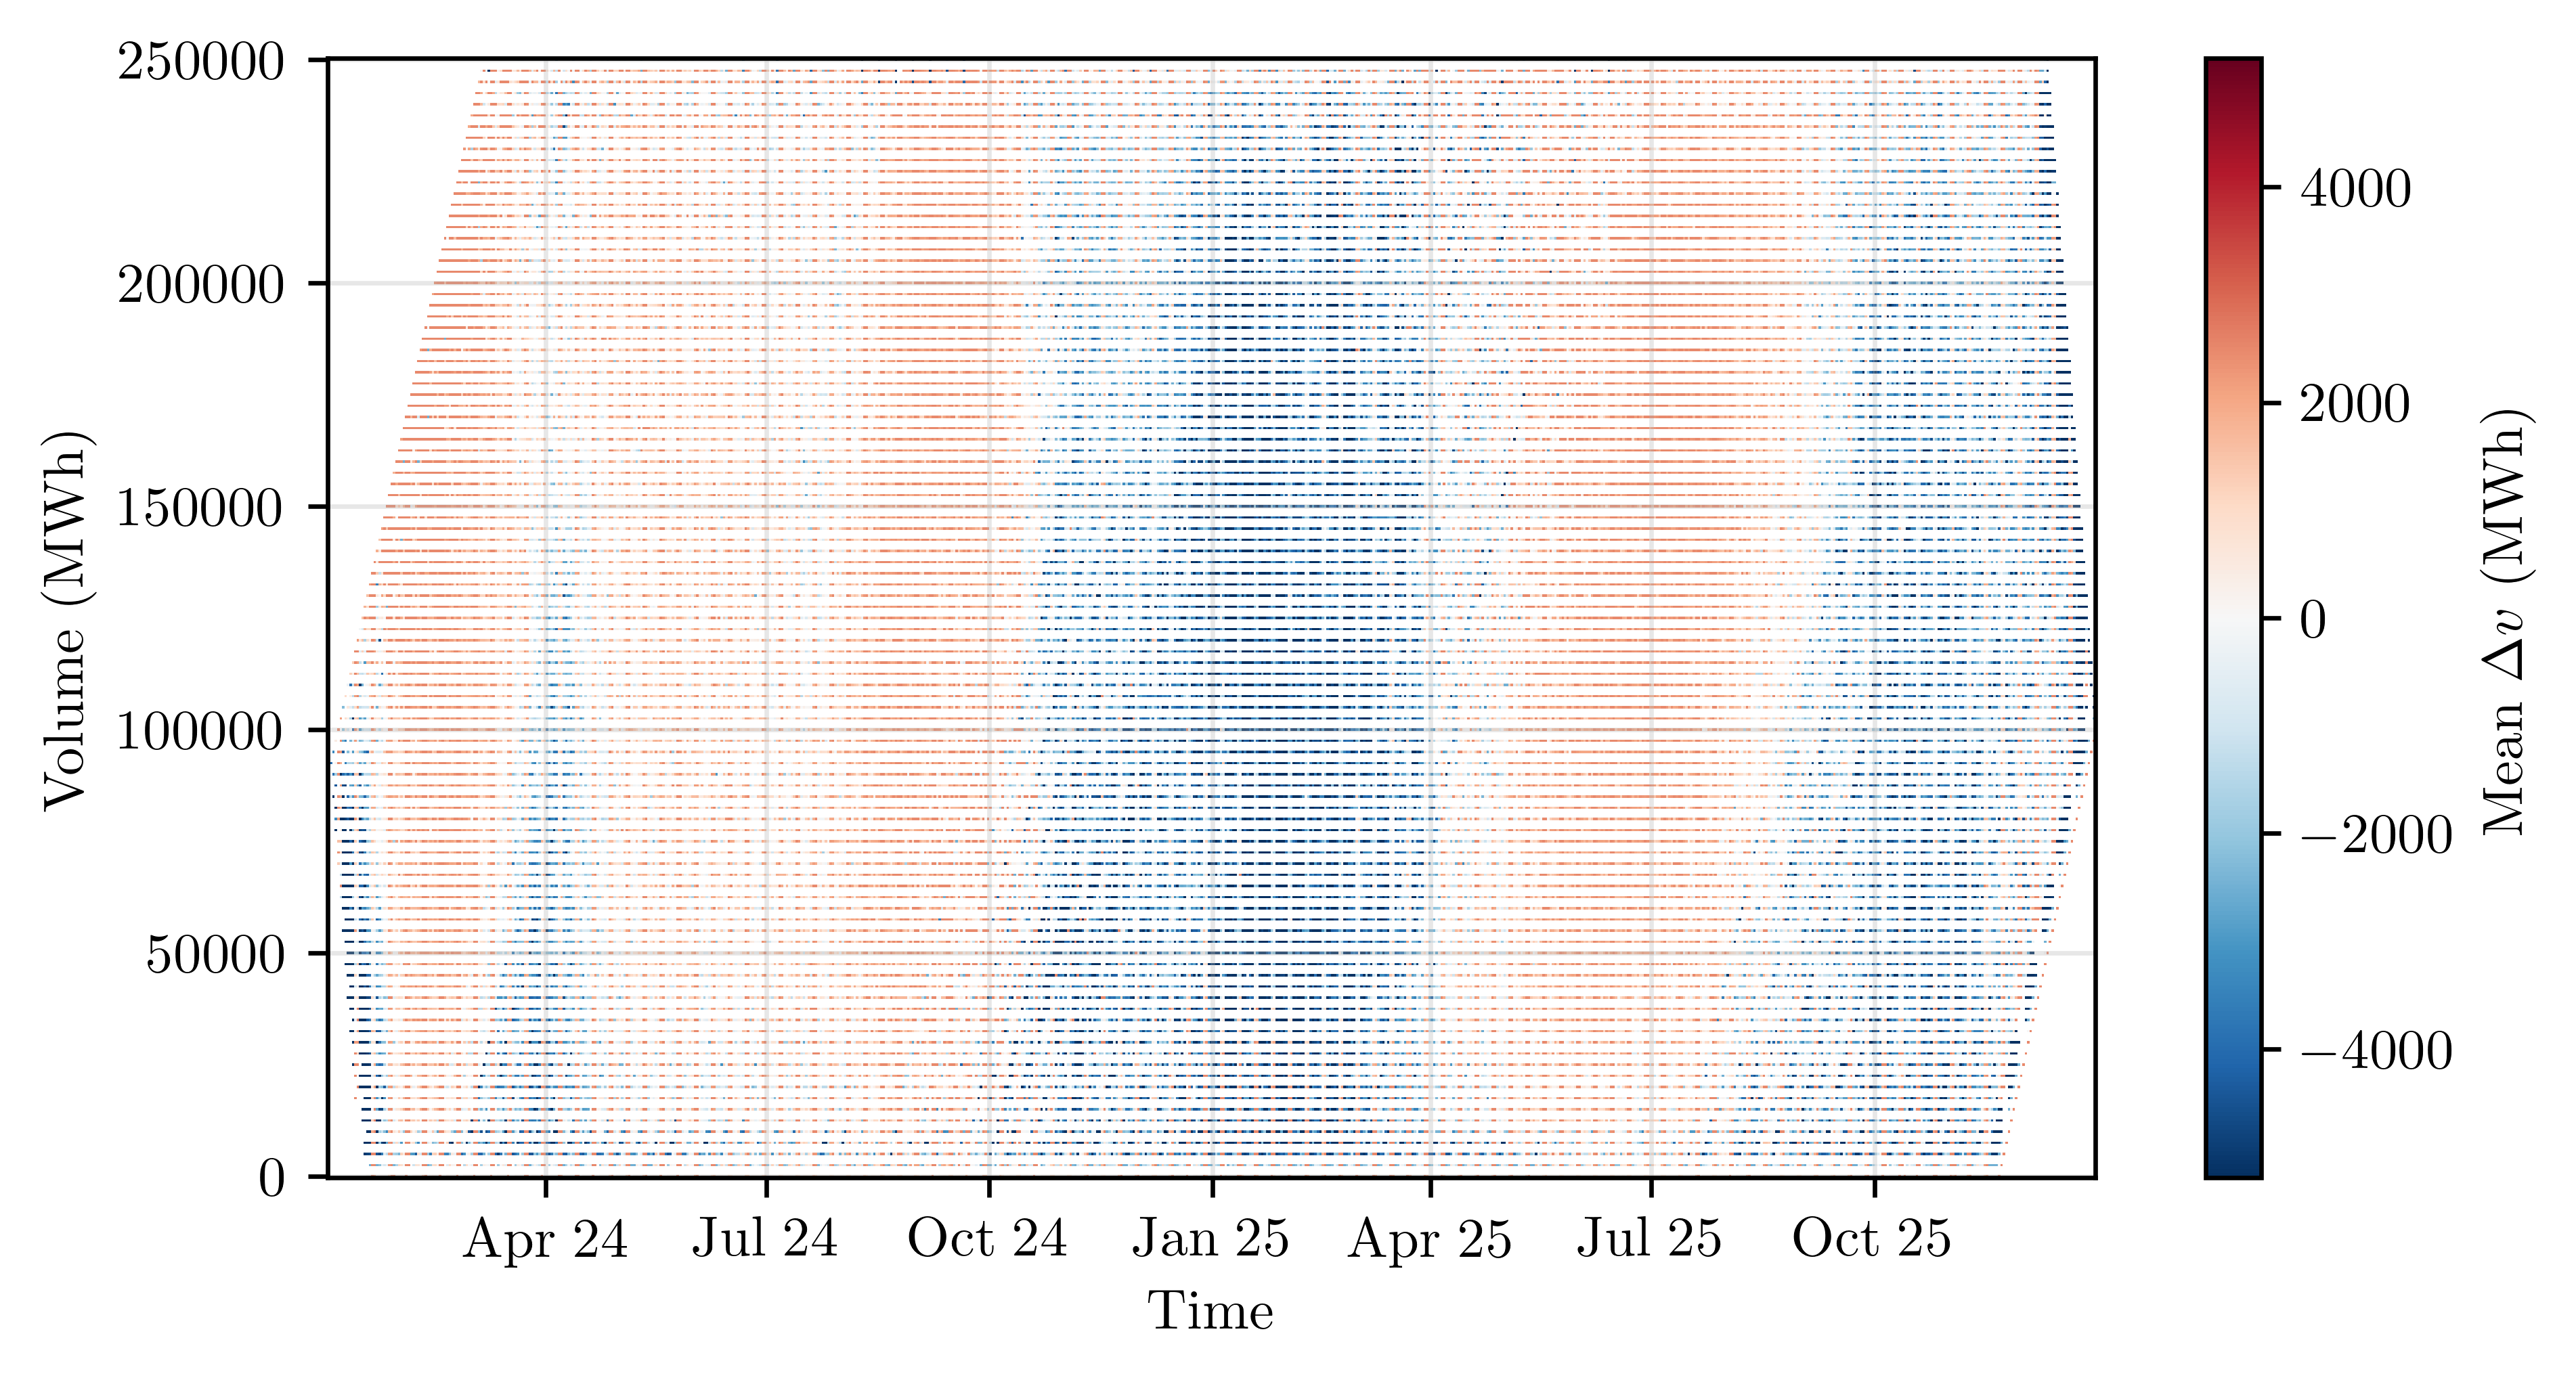

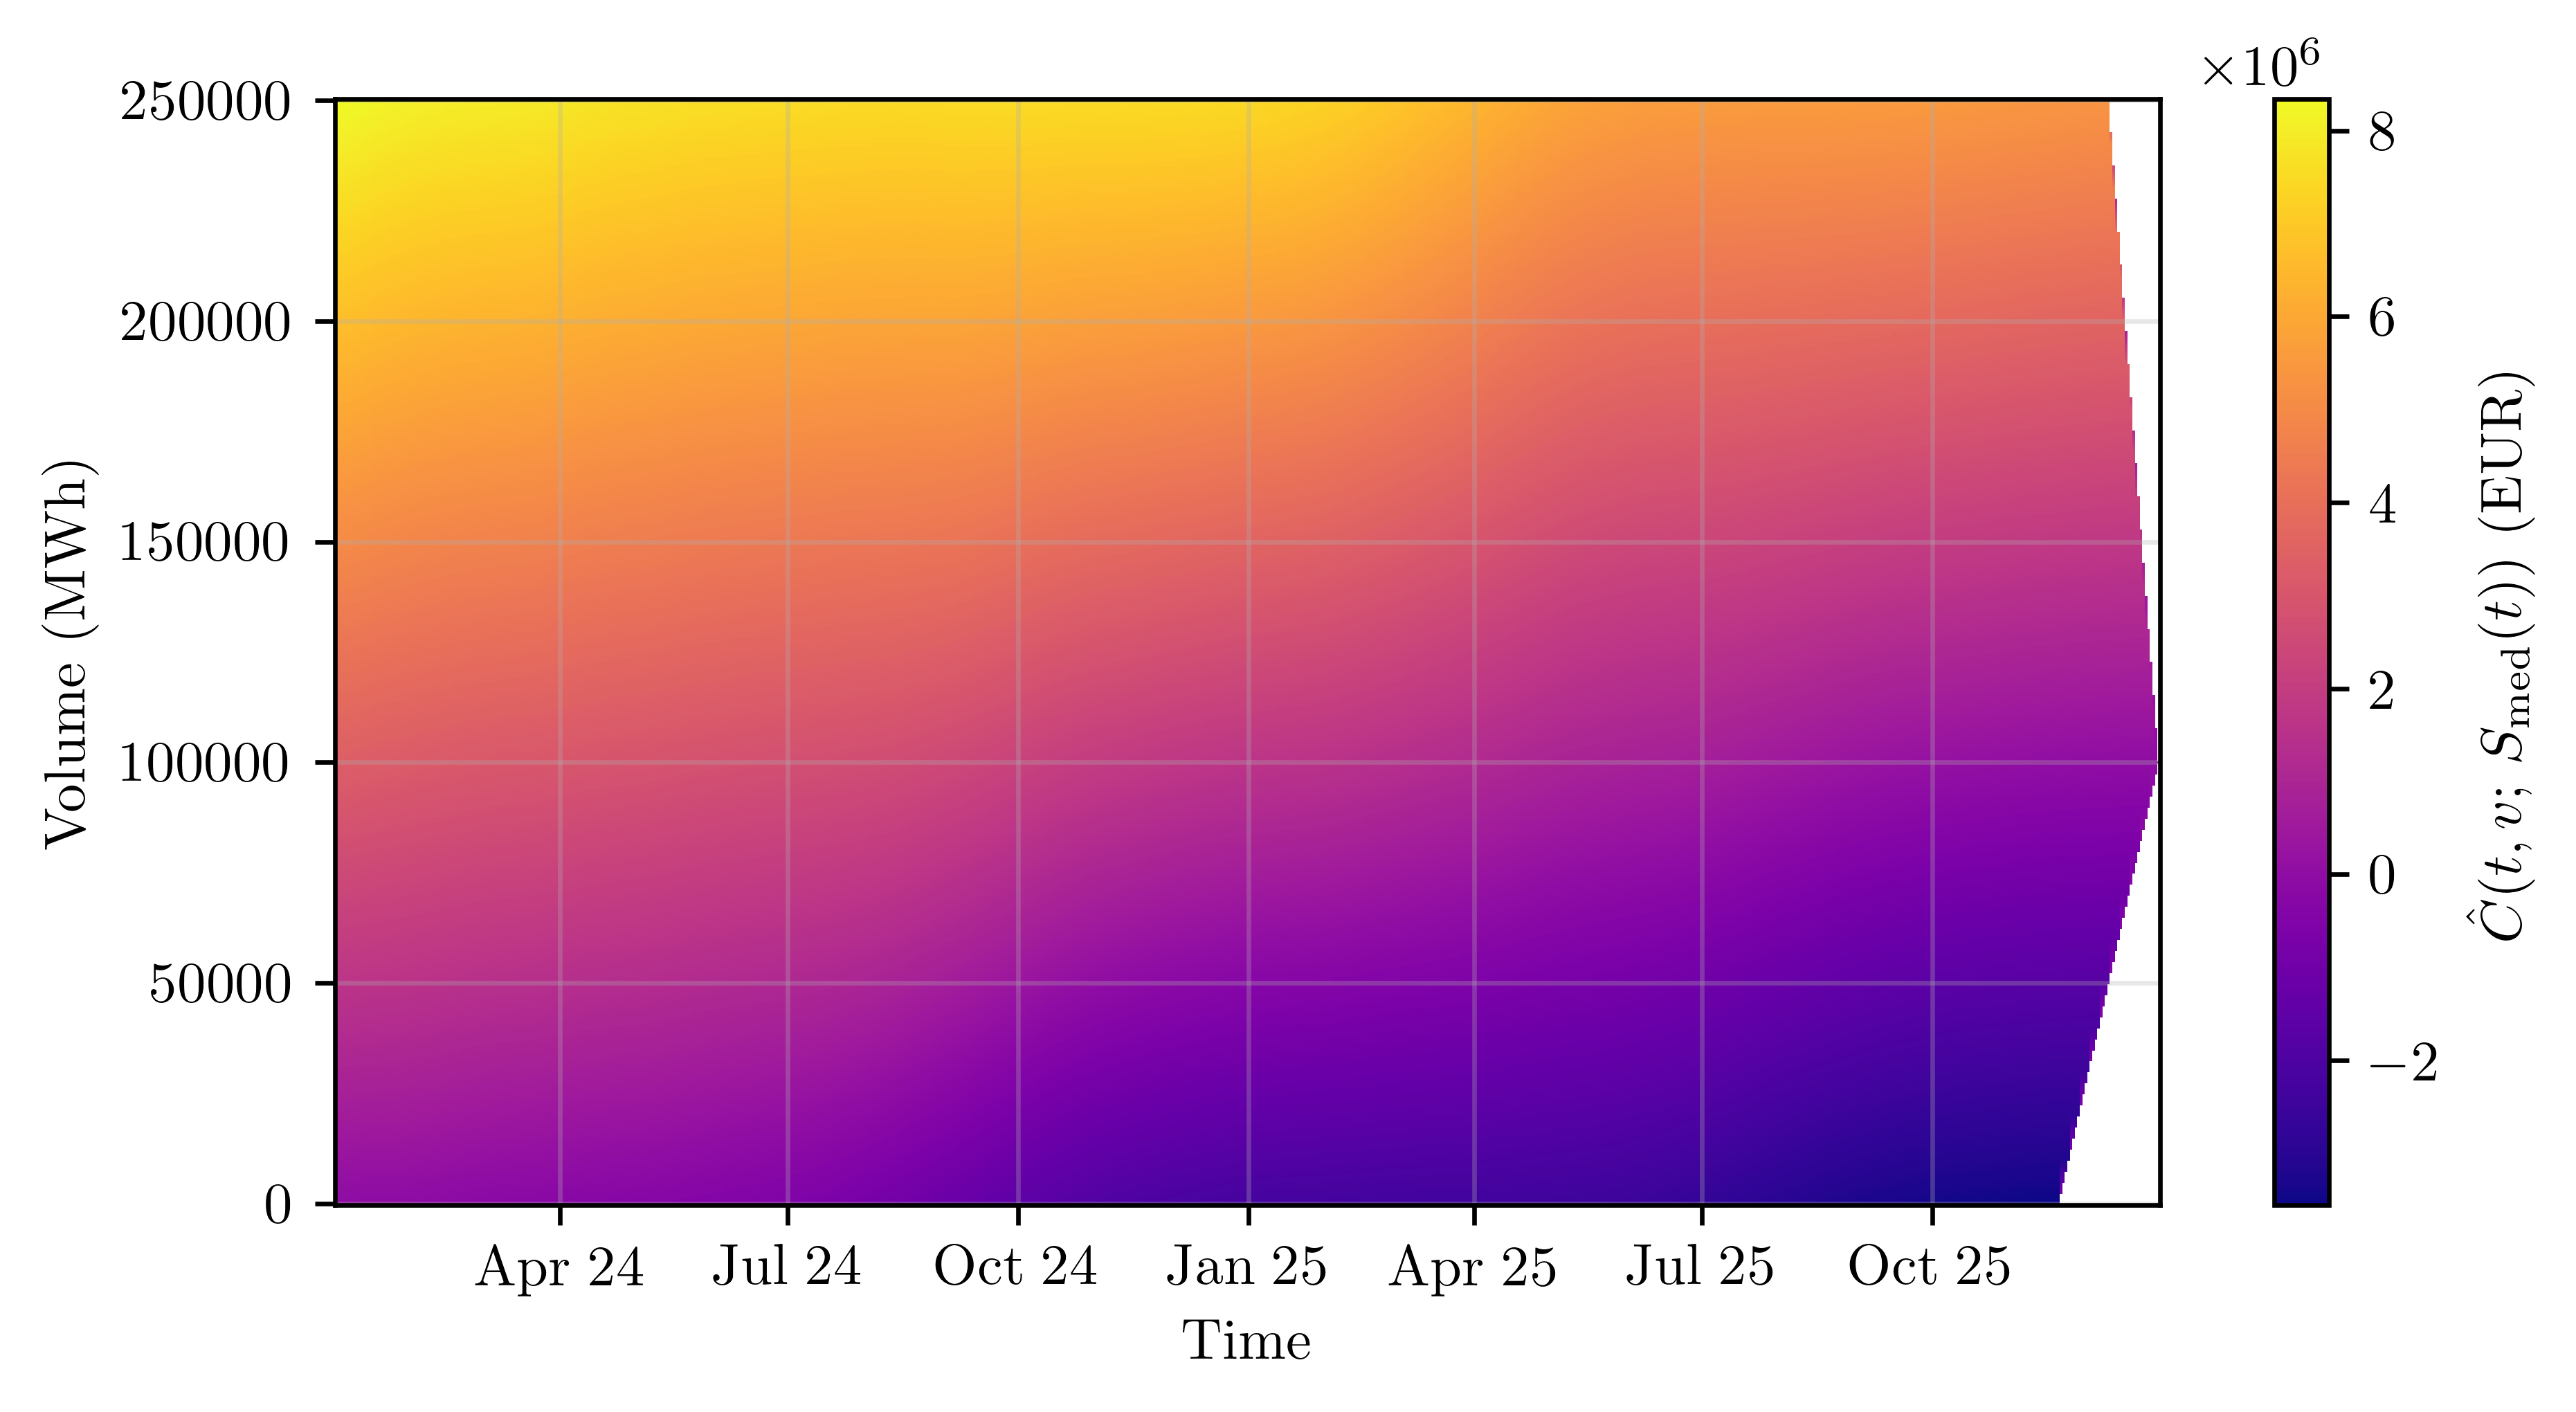

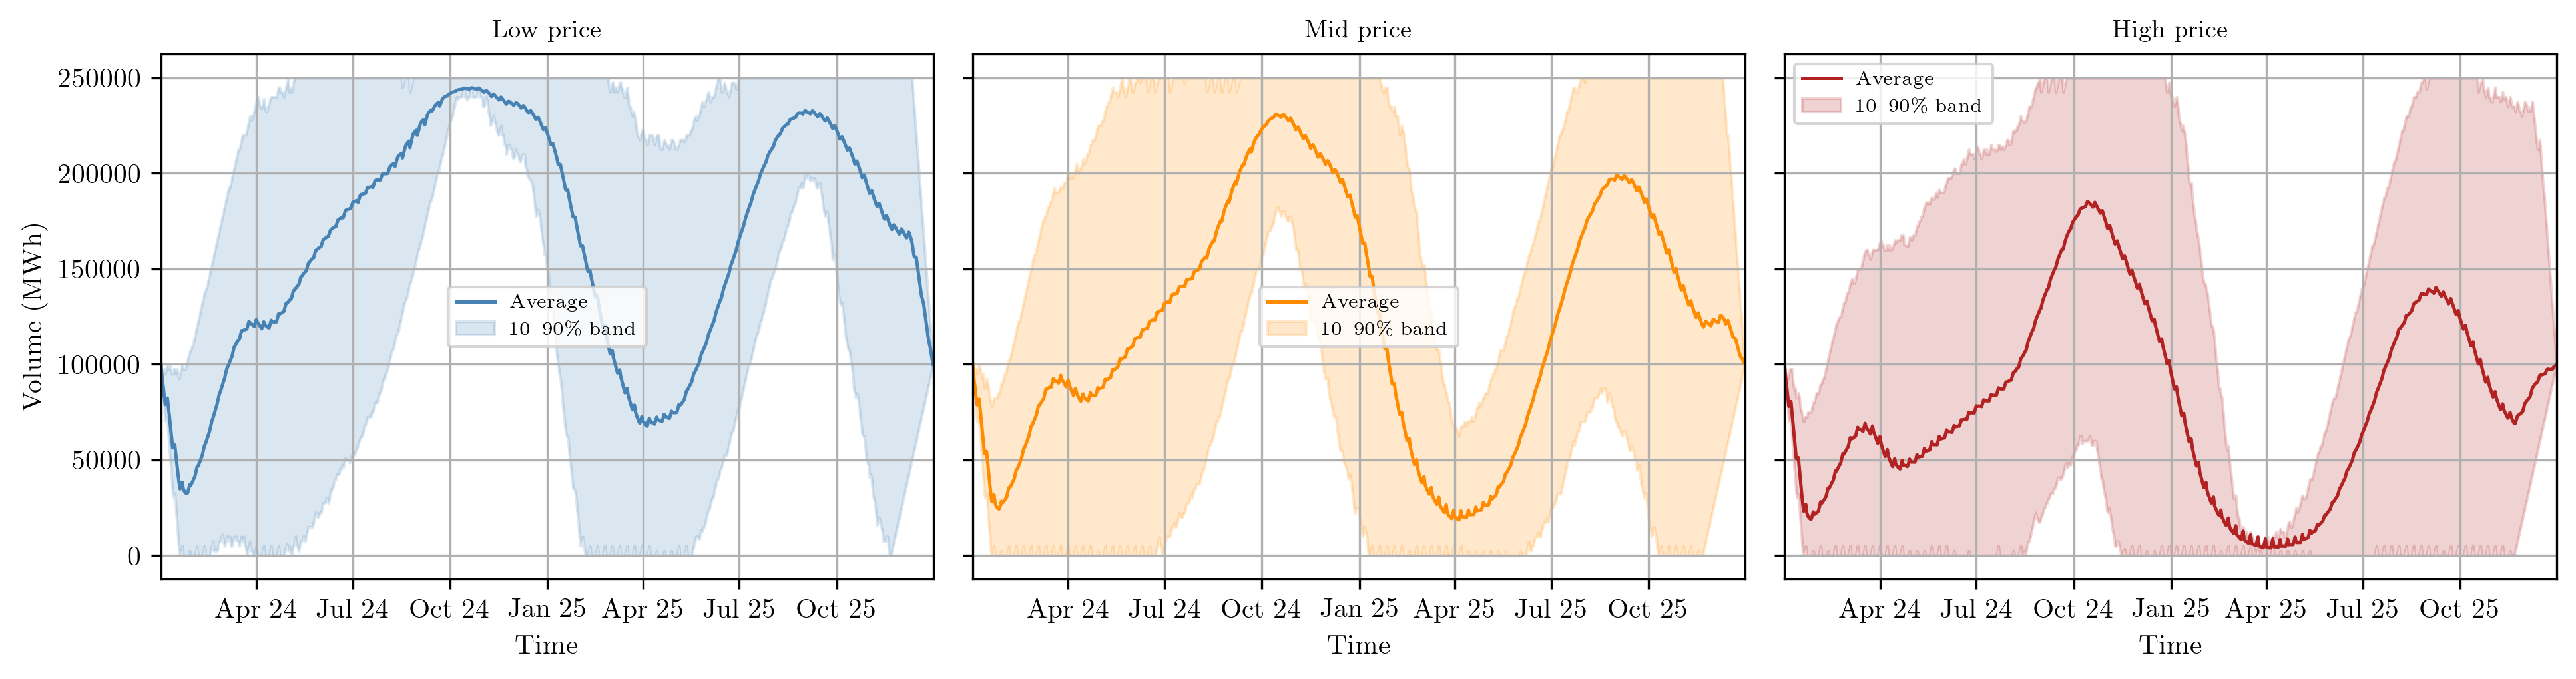

/var/folders/5j/jwmnpjk12gd85jt5f8996m740000gn/T/ipykernel_88479/1535632232.py:45: RuntimeWarning: invalid value encountered in divide
  return np.where(cg > 0, sg / cg, np.nan)


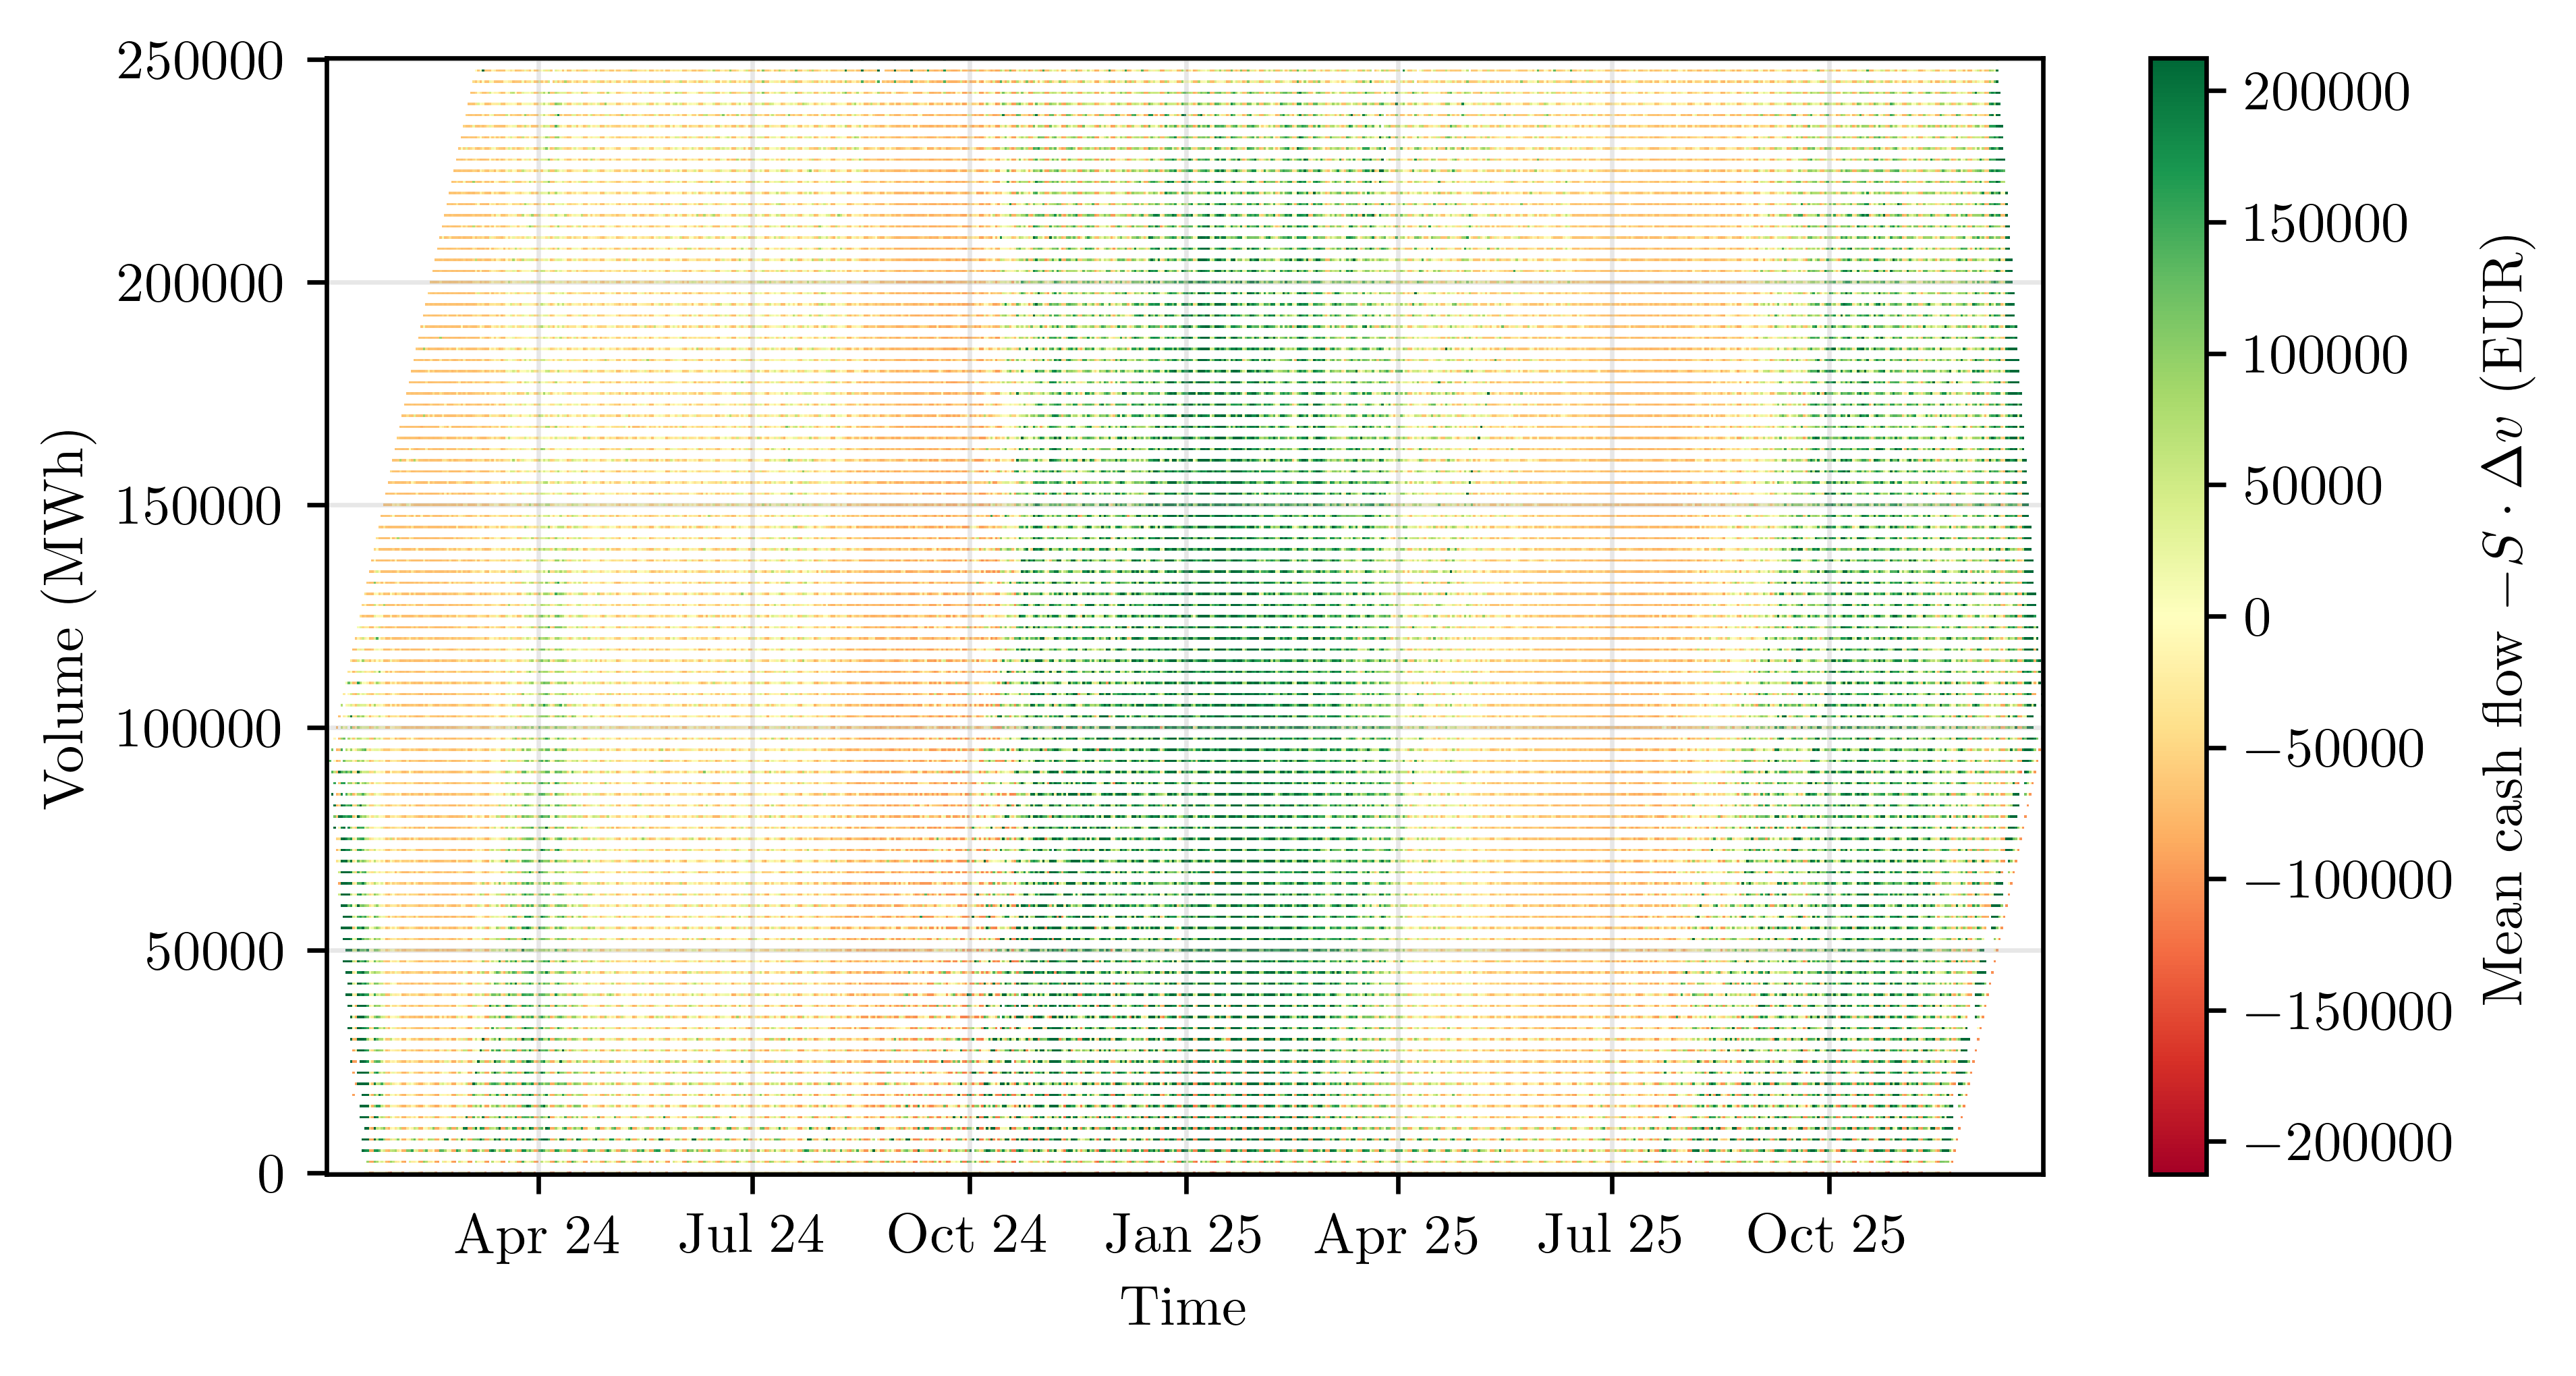

In [3]:
# ============================================================
# Four diagnostic plots for the optimal LSMC policy
# ============================================================

# --- Simulate paths ---
n_paths_plot = 5_000
seed_plot    = seed

rng_plot = np.random.default_rng(seed_plot)
n_half_p = int(np.ceil(n_paths_plot / 2))
Z_half_p = rng_plot.standard_normal(size=(Tn - 1, n_half_p))
Z_plot   = np.concatenate([Z_half_p, -Z_half_p], axis=1)[:, :n_paths_plot]

S_plot = simulate_from_Z(
    Z_plot, n_paths=n_paths_plot, Tn=Tn, t_arr=t_arr,
    kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col,
)

# Backward pass for B_store (Plot 2), then forward rollout for v_path (Plots 1,3,4)
_, B_store_plot, _, _ = lsmc_value_and_B_store_given_S(S_plot)
_, v_path_plot, dates_plot = lsmc_value_and_paths_given_S(S_plot)

dates_pd_plot = pd.DatetimeIndex(dates_plot)
T1, M_plot    = v_path_plot.shape   # (730, 5000)
T_steps       = T1 - 1             # 729

# --- Common derived quantities ---
dv        = np.diff(v_path_plot, axis=0)                        # (T, M)
cf        = -S_plot[:T_steps] * dv                              # (T, M)
disc_to_0 = np.concatenate(([1.0], np.cumprod(disc_arr[:-1])))  # (T,)
pv        = np.sum(disc_to_0[:, None] * cf, axis=0)             # (M,) pathwise PV

# Origin-volume grid index for each path at each step
n_idx = np.clip(
    np.round((v_path_plot - VMIN_GLOBAL) / alpha_f).astype(int), 0, Nf - 1
)  # (T+1, M)

# Aggregate a (T, M) field onto a (T, Nf) grid by grouping on the origin volume
def to_grid(field_TM):
    sg = np.zeros((T_steps, Nf), dtype=np.float64)
    cg = np.zeros((T_steps, Nf), dtype=np.int32)
    for t in range(T_steps):
        np.add.at(sg[t], n_idx[t], field_TM[t])
        np.add.at(cg[t], n_idx[t], 1)
    return np.where(cg > 0, sg / cg, np.nan)

# --- Matplotlib settings ---
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

# --- Shared pcolormesh grid coordinates ---
# x-edges = calendar dates (T+1 points = natural step boundaries)
# y-edges = midpoints between fine-grid nodes, extended by half a cell at each end
def _v_edges(v):
    mid = (v[:-1] + v[1:]) / 2
    return np.concatenate([[v[0] - (v[1] - v[0]) / 2], mid, [v[-1] + (v[-1] - v[-2]) / 2]])

X_base, Y_base = np.meshgrid(
    mdates.date2num(dates_pd_plot),  # 730 x-edges
    _v_edges(v_fine),                # 202 y-edges
)  # each (202, 730); paired with a (201, 729) = (Nf, T) colour matrix

def _fmt(ax):
    ax.xaxis_date()
    ax.set_xlim(dates_pd_plot[0], dates_pd_plot[-1])
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    ax.set_xlabel("Time")
    ax.set_ylabel("Volume (MWh)")
    ax.grid(True, alpha=0.3)


# ============================================================
# Plot 1 — Optimal action map
# colour = mean dv at each (time, volume) cell
# Red = withdrawing, blue = injecting, white = holding
# ============================================================
action_grid = to_grid(dv)   # (T, Nf)

fig1, ax1 = plt.subplots(figsize=(6.5, 3.5), dpi=600)
vmax1 = np.nanpercentile(np.abs(action_grid), 95)
pcm1  = ax1.pcolormesh(X_base, Y_base, np.ma.masked_invalid(action_grid.T),
                        cmap="RdBu_r", shading="flat", vmin=-vmax1, vmax=vmax1)
fig1.colorbar(pcm1, ax=ax1, label=r"Mean $\Delta v$ (MWh)")
_fmt(ax1)
fig1.tight_layout()
plt.savefig("../../fig/Plots/OLS_action_map.png")
plt.show()


# ============================================================
# Plot 2 — Continuation value at median spot price
# C(t, v; S_med(t)) evaluated using stored OLS coefficients
# Uses build_basis_matrix for generality across basis families
# ============================================================
S_med   = np.median(S_plot[:T_steps], axis=1)          # (T,) median spot at each step
phi_med = build_basis_matrix(S_med, basis_degree, basis_family)   # (T, p_dim)
# C at each (t, coarse-grid-point k): einsum over basis dimension
C_coarse_all = np.einsum("tp,tpk->tk", phi_med, B_store_plot)    # (T, Nc)

C_cont = np.full((T_steps, Nf), np.nan)
for t in range(T_steps):
    C_fine = np.interp(np.arange(Nf), coarse_fine_idx, C_coarse_all[t])
    C_fine[~all_can_reach[t + 1]] = np.nan
    C_cont[t] = C_fine

fig2, ax2 = plt.subplots(figsize=(6.5, 3.5), dpi=600)
pcm2 = ax2.pcolormesh(X_base, Y_base, np.ma.masked_invalid(C_cont.T),
                       cmap="plasma", shading="flat")
fig2.colorbar(pcm2, ax=ax2, label=r"$\hat{C}(t,v;\,S_{\mathrm{med}}(t))$ (EUR)")
_fmt(ax2)
fig2.tight_layout()
plt.savefig("../../fig/Plots/OLS_continuation_value.png")
plt.show()


# ============================================================
# Plot 3 — Inventory bands split by overall price-level tercile
# Paths sorted by mean log spot; each panel shows a different
# price-level regime to isolate the strategy from price confounding
# ============================================================
mean_log_S = np.mean(np.log(S_plot), axis=0)           # (M,) path-level price index
q33, q67   = np.percentile(mean_log_S, [33.3, 66.7])
masks3 = [
    mean_log_S < q33,
    (mean_log_S >= q33) & (mean_log_S < q67),
    mean_log_S >= q67,
]
labels3 = ["Low price", "Mid price", "High price"]
colors3 = ["steelblue", "darkorange", "firebrick"]

fig3, axes3 = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True, dpi=300)
for ax, mask, lbl, col in zip(axes3, masks3, labels3, colors3):
    vp = v_path_plot[:, mask]
    ax.plot(dates_pd_plot, vp.mean(axis=1), color=col, lw=1.2, label="Average")
    ax.fill_between(dates_pd_plot,
                    np.percentile(vp, 10, axis=1),
                    np.percentile(vp, 90, axis=1),
                    alpha=0.2, color=col, label=r"10--90\% band")
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel("Time")
    ax.set_xlim(dates_pd_plot[0], dates_pd_plot[-1])
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    ax.grid(True)
    ax.legend(fontsize=7)
axes3[0].set_ylabel("Volume (MWh)")
fig3.tight_layout()
plt.savefig("../../fig/Plots/OLS_inventory_price_terciles.png")
plt.show()


# ============================================================
# Plot 4 — Immediate cash flow map
# colour = mean (-S * dv) at each (time, volume) cell
# Green = net revenue (withdrawing at high price or injecting at negative spread),
# red = net cost; unconfounded by value along the rest of the path
# ============================================================
cf_grid = to_grid(cf)   # (T, Nf)

fig4, ax4 = plt.subplots(figsize=(6.5, 3.5), dpi=600)
vmax4 = np.nanpercentile(np.abs(cf_grid), 95)
pcm4  = ax4.pcolormesh(X_base, Y_base, np.ma.masked_invalid(cf_grid.T),
                        cmap="RdYlGn", shading="flat", vmin=-vmax4, vmax=vmax4)
fig4.colorbar(pcm4, ax=ax4, label=r"Mean cash flow $-S \cdot \Delta v$ (EUR)")
_fmt(ax4)
fig4.tight_layout()
plt.savefig("../../fig/Plots/OLS_cashflow_map.png")
plt.show()

Convergence over seeds: 100%|██████████| 10/10 [14:03<00:00, 84.36s/it]


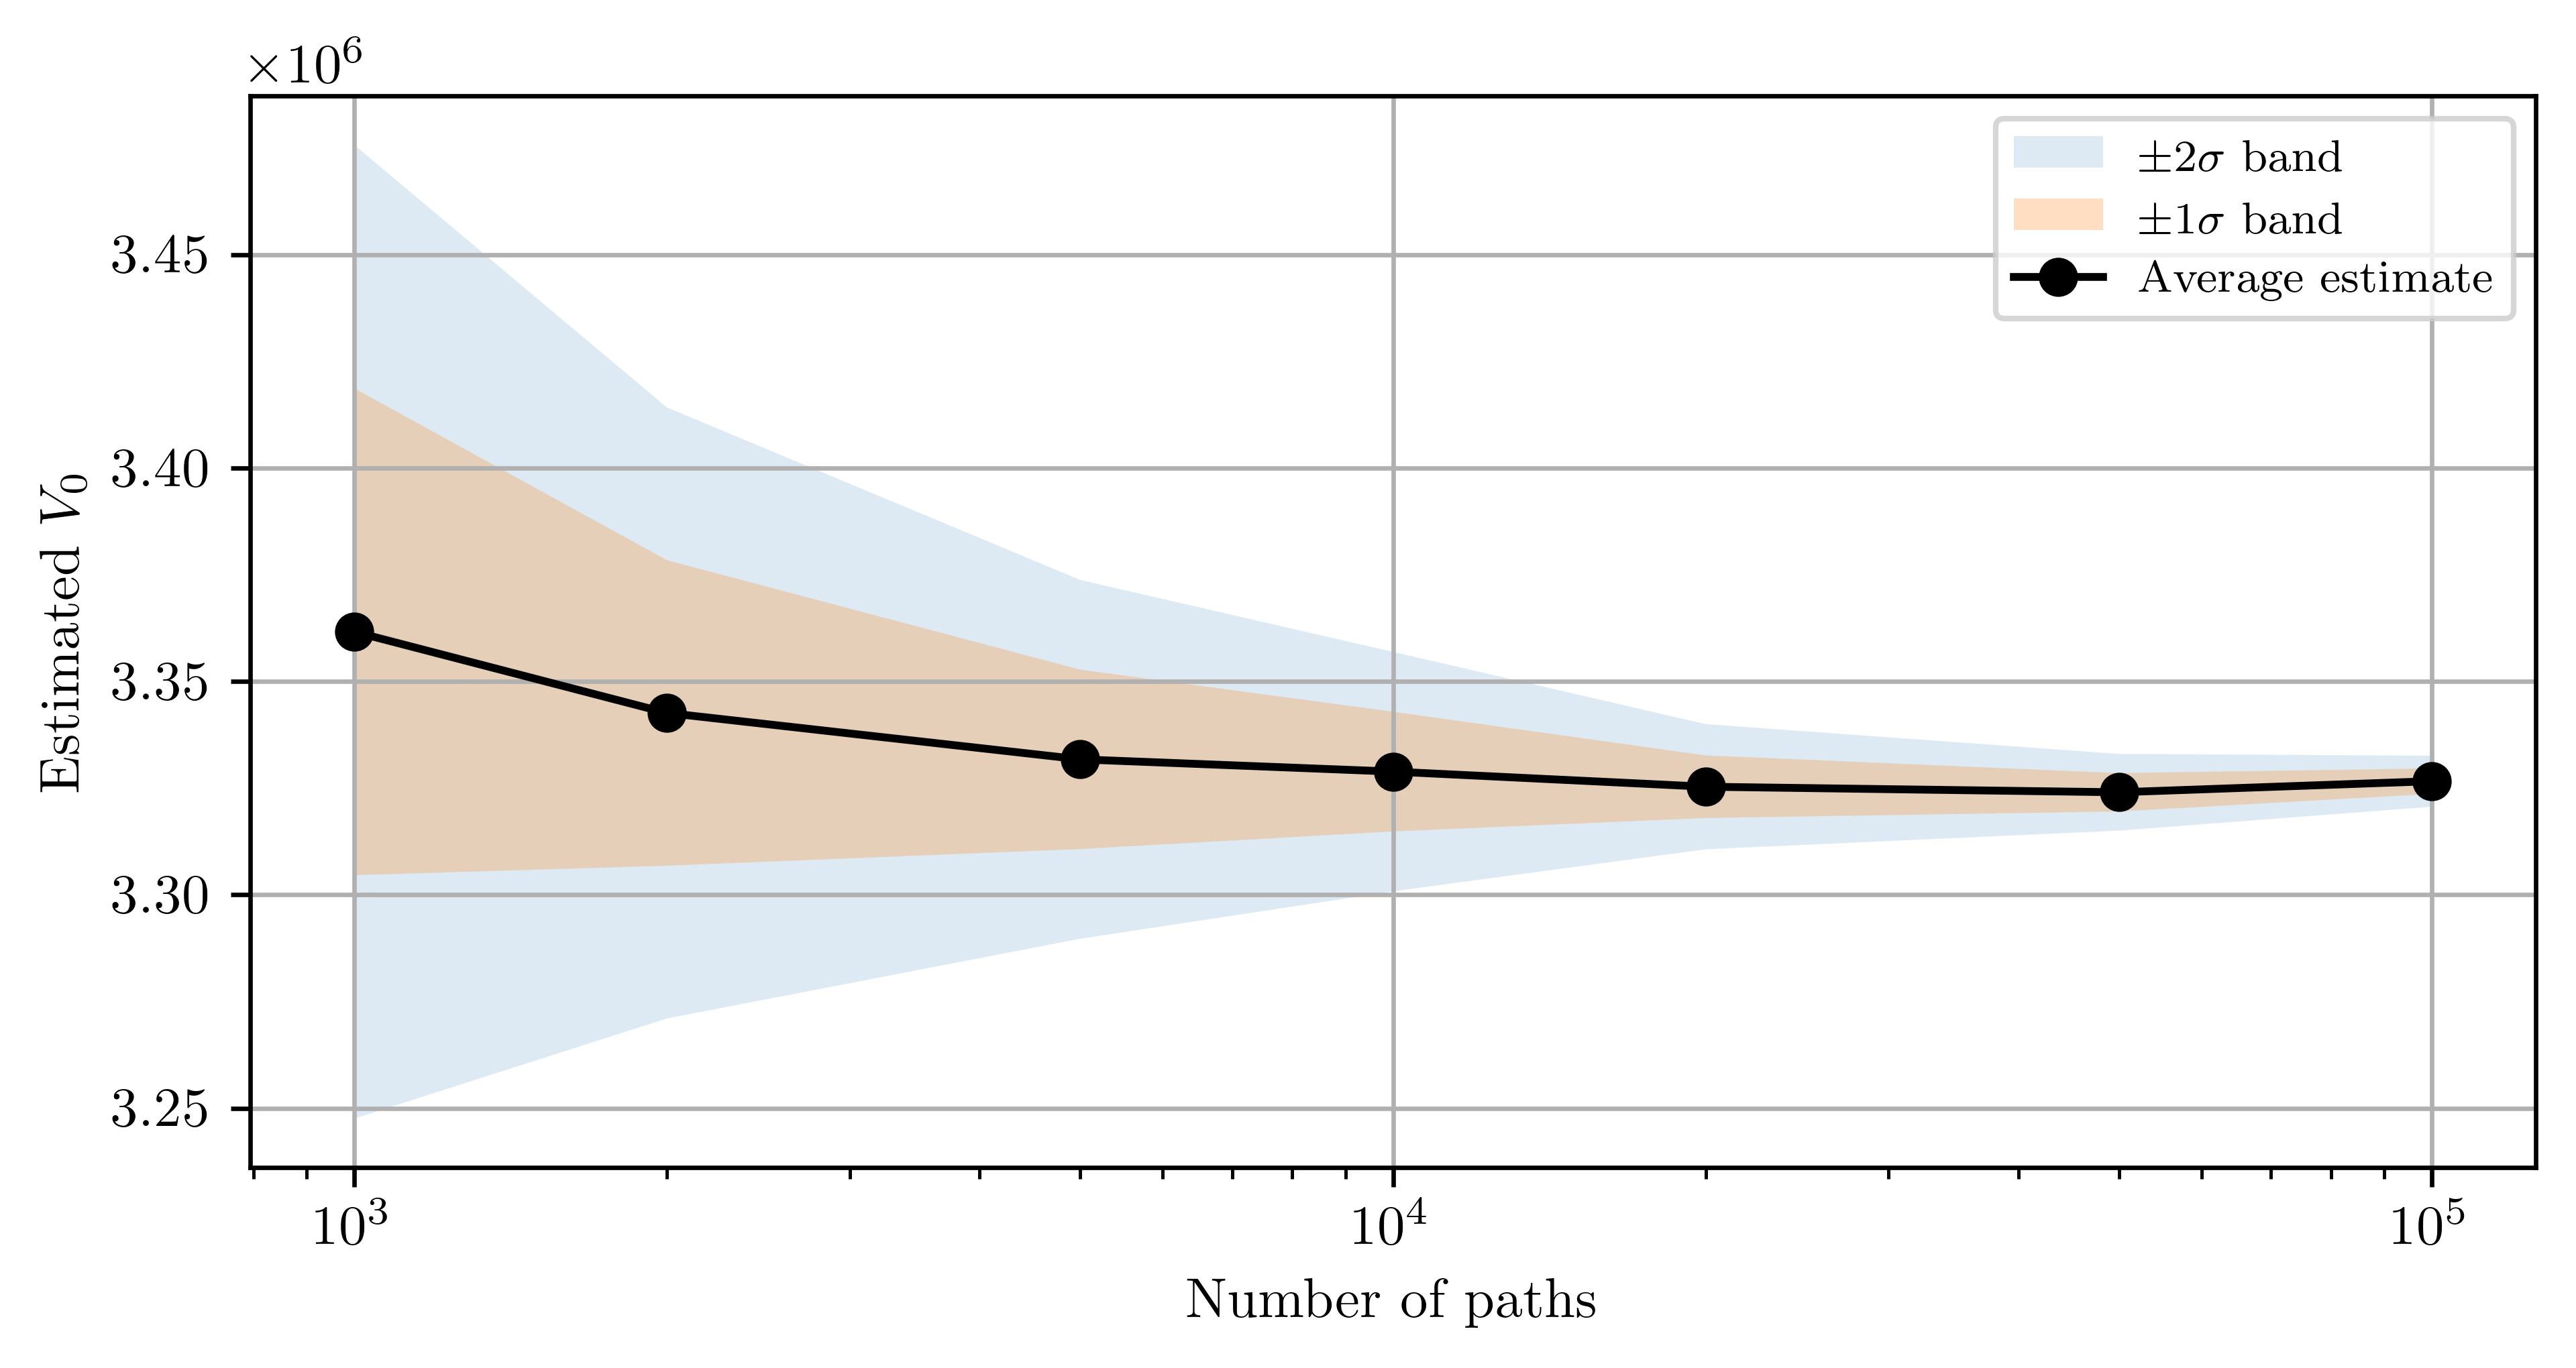

In [ ]:
# -------------------------------------------------
# Convergence analysis: observations
# -------------------------------------------------

n_paths = 100000
base_seed = 123
n_seeds = 10
n_values = [1000, 2000, 5000, 10000, 20000, 50000, 100000]

seed_values = base_seed + np.arange(n_seeds)
records = []

for seed_idx, seed in enumerate(tqdm(seed_values, desc="Convergence over seeds")):
    rng = np.random.default_rng(seed)
    n_half = int(np.ceil(n_paths / 2))
    Z_half = rng.standard_normal(size=(Tn - 1, n_half))
    Z = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths]

    for n_paths in n_values:
        t0 = time.perf_counter()
        S = simulate_from_Z(
            Z,
            n_paths=n_paths,
            Tn=Tn,
            t_arr=t_arr,
            kappa_hat=kappa_hat,
            sigma_hat=sigma_hat,
            m_col=m_col,
        )
        V0_hat = lsmc_value_given_S(S)
        runtime_seconds = time.perf_counter() - t0

        records.append({
            "seed": int(seed),
            "n_paths": int(n_paths),
            "V0_hat": V0_hat,
            "runtime_seconds": runtime_seconds,
        })

results_df = pd.DataFrame(records)

summary_df = (
    results_df
    .groupby("n_paths", as_index=False)
    .agg(
        mean_V0_hat=("V0_hat", "mean"),
        std_V0_hat=("V0_hat", lambda x: x.std(ddof=1)),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        std_runtime_seconds=("runtime_seconds", lambda x: x.std(ddof=1)),
    )
    .sort_values("n_paths")
    .reset_index(drop=True)
)

summary_df["minus_1std"] = summary_df["mean_V0_hat"] - summary_df["std_V0_hat"]
summary_df["plus_1std"] = summary_df["mean_V0_hat"] + summary_df["std_V0_hat"]
summary_df["minus_2std"] = summary_df["mean_V0_hat"] - 2.0 * summary_df["std_V0_hat"]
summary_df["plus_2std"] = summary_df["mean_V0_hat"] + 2.0 * summary_df["std_V0_hat"]

results_df = results_df.merge(summary_df, on="n_paths", how="left")

# Save seed-level observations, including runtime for each (seed, n_paths)
results_df.to_csv("../data/OLS_convergence_observations.csv", index=False)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

p_array = summary_df["n_paths"].to_numpy(dtype=np.float64)
V_mean = summary_df["mean_V0_hat"].to_numpy(dtype=np.float64)
V_std = summary_df["std_V0_hat"].to_numpy(dtype=np.float64)

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)
ax.fill_between(p_array, V_mean - 2.0 * V_std, V_mean + 2.0 * V_std,
                alpha=0.15, label=r"$\pm 2\sigma$ band")
ax.fill_between(p_array, V_mean - V_std, V_mean + V_std,
                alpha=0.25, label=r"$\pm 1\sigma$ band")

ax.plot(p_array, V_mean, linewidth=1.4, color="black", marker="o",
        label="Average estimate")

ax.set_xscale("log")
ax.set_xlabel("Number of paths")
ax.set_ylabel(r"Estimated $V_0$")
ax.grid(True)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_convergence_observations.png")
plt.show()

Convergence over seeds: 100%|██████████| 10/10 [00:00<00:00, 4466.30it/s]


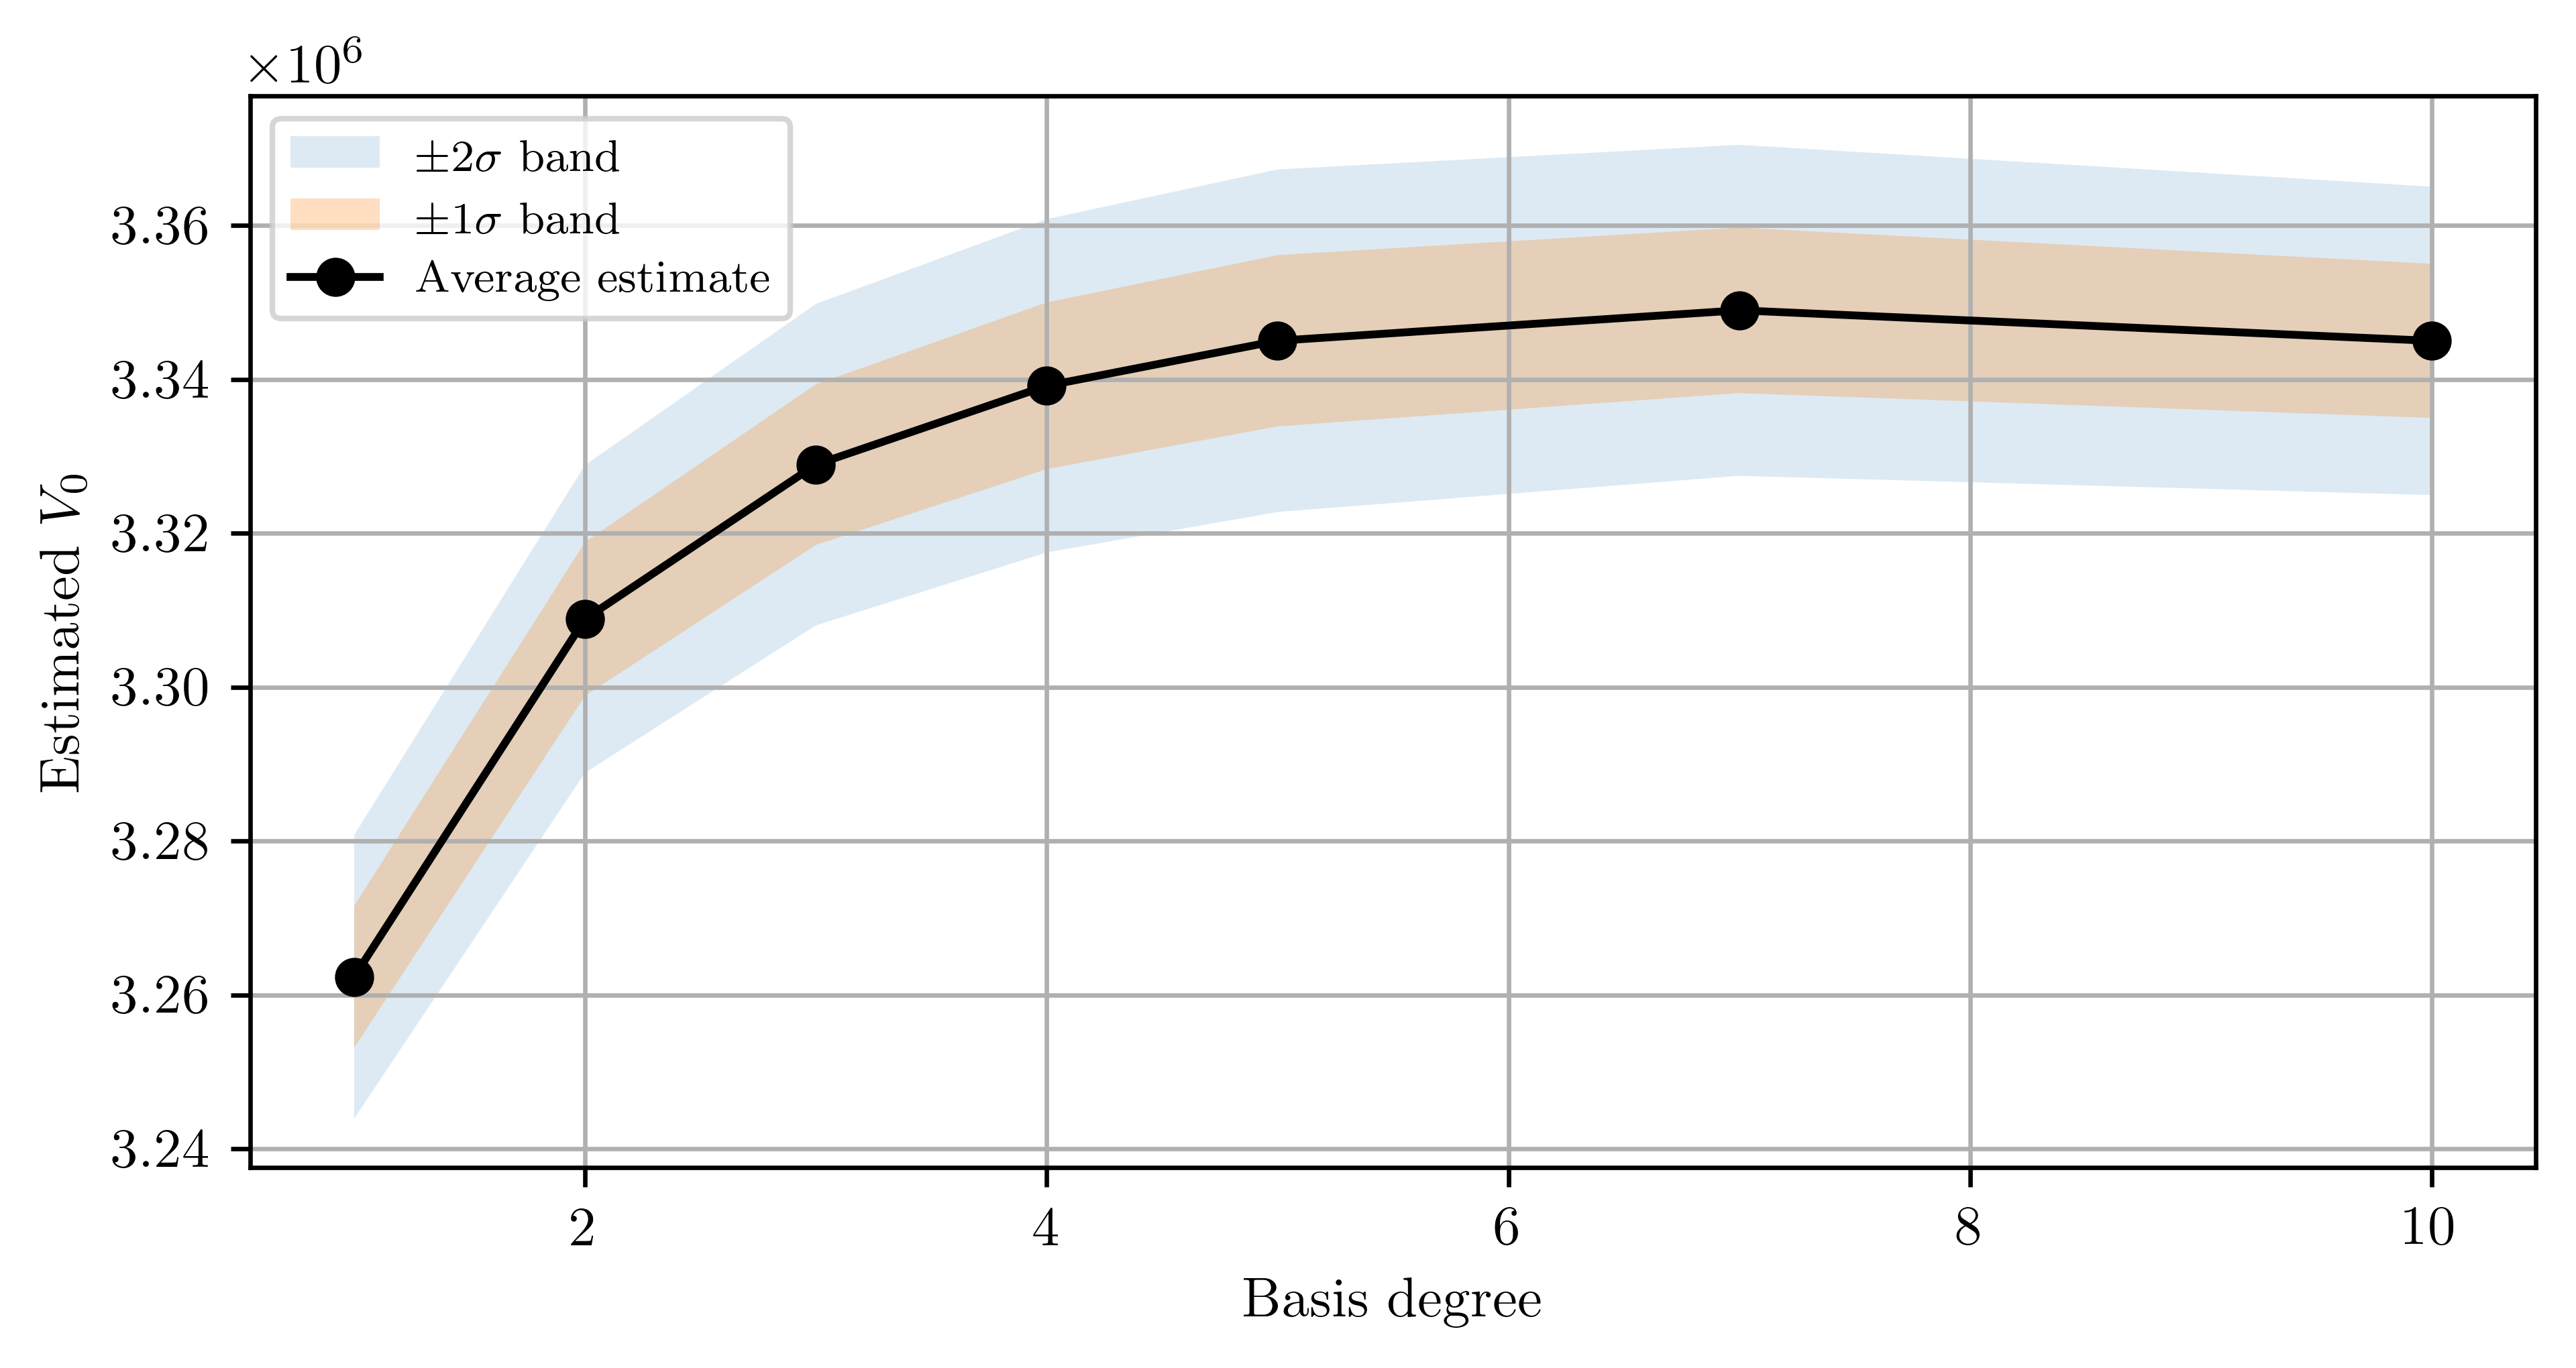

In [3]:
# -------------------------------------------------
# Convergence analysis: Basis functions
# -------------------------------------------------
import time
from tqdm import tqdm
from joblib import Parallel, delayed

n_paths = 10000
base_seed = 123
n_seeds = 10
basis_degree_values = [1, 2, 3, 4, 5, 7, 10]

seed_values = base_seed + np.arange(n_seeds)


def _run_seed(seed, basis_degree_values, n_paths, Tn, t_arr,
              kappa_hat, sigma_hat, m_col):
    rng = np.random.default_rng(seed)
    n_half = int(np.ceil(n_paths / 2))
    Z_half = rng.standard_normal(size=(Tn - 1, n_half))
    Z = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths]

    # S does not depend on basis_degree — simulate once per seed
    S = simulate_from_Z(
        Z,
        n_paths=n_paths,
        Tn=Tn,
        t_arr=t_arr,
        kappa_hat=kappa_hat,
        sigma_hat=sigma_hat,
        m_col=m_col,
    )

    records = []
    for basis_degree in basis_degree_values:
        t0 = time.perf_counter()
        V0_hat = lsmc_value_given_S_and_basis_degree(S, basis_degree)
        runtime_seconds = time.perf_counter() - t0
        records.append({
            "seed": int(seed),
            "n_paths": int(n_paths),
            "basis_degree": int(basis_degree),
            "V0_hat": V0_hat,
            "runtime_seconds": runtime_seconds,
        })
    return records


nested = Parallel(n_jobs=-1, backend="loky")(
    delayed(_run_seed)(
        seed, basis_degree_values, n_paths, Tn, t_arr,
        kappa_hat, sigma_hat, m_col,
    )
    for seed in tqdm(seed_values, desc="Convergence over seeds")
)
records = [r for seed_records in nested for r in seed_records]

results_df = pd.DataFrame(records)

summary_df = (
    results_df
    .groupby("basis_degree", as_index=False)
    .agg(
        mean_V0_hat=("V0_hat", "mean"),
        std_V0_hat=("V0_hat", lambda x: x.std(ddof=1)),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        std_runtime_seconds=("runtime_seconds", lambda x: x.std(ddof=1)),
    )
    .sort_values("basis_degree")
    .reset_index(drop=True)
)

summary_df["minus_1std"] = summary_df["mean_V0_hat"] - summary_df["std_V0_hat"]
summary_df["plus_1std"] = summary_df["mean_V0_hat"] + summary_df["std_V0_hat"]
summary_df["minus_2std"] = summary_df["mean_V0_hat"] - 2.0 * summary_df["std_V0_hat"]
summary_df["plus_2std"] = summary_df["mean_V0_hat"] + 2.0 * summary_df["std_V0_hat"]

results_df = results_df.merge(summary_df, on="basis_degree", how="left")

# Save seed-level observations, including runtime for each (seed, n_paths)
results_df.to_csv("../data/OLS_convergence_basis_degree.csv", index=False)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

p_array = summary_df["basis_degree"].to_numpy(dtype=np.float64)
V_mean = summary_df["mean_V0_hat"].to_numpy(dtype=np.float64)
V_std = summary_df["std_V0_hat"].to_numpy(dtype=np.float64)

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

ax.fill_between(p_array, V_mean - 2.0 * V_std, V_mean + 2.0 * V_std,
                alpha=0.15, label=r"$\pm 2\sigma$ band")
ax.fill_between(p_array, V_mean - V_std, V_mean + V_std,
                alpha=0.25, label=r"$\pm 1\sigma$ band")
ax.plot(p_array, V_mean, linewidth=1.4, color="black", marker="o",
        label="Average estimate")

ax.set_xlabel("Basis degree")
ax.set_ylabel(r"Estimated $V_0$")
ax.grid(True)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_convergence_basis_degree.png")
plt.show()

Convergence over seeds: 100%|██████████| 10/10 [07:17<00:00, 43.78s/it]


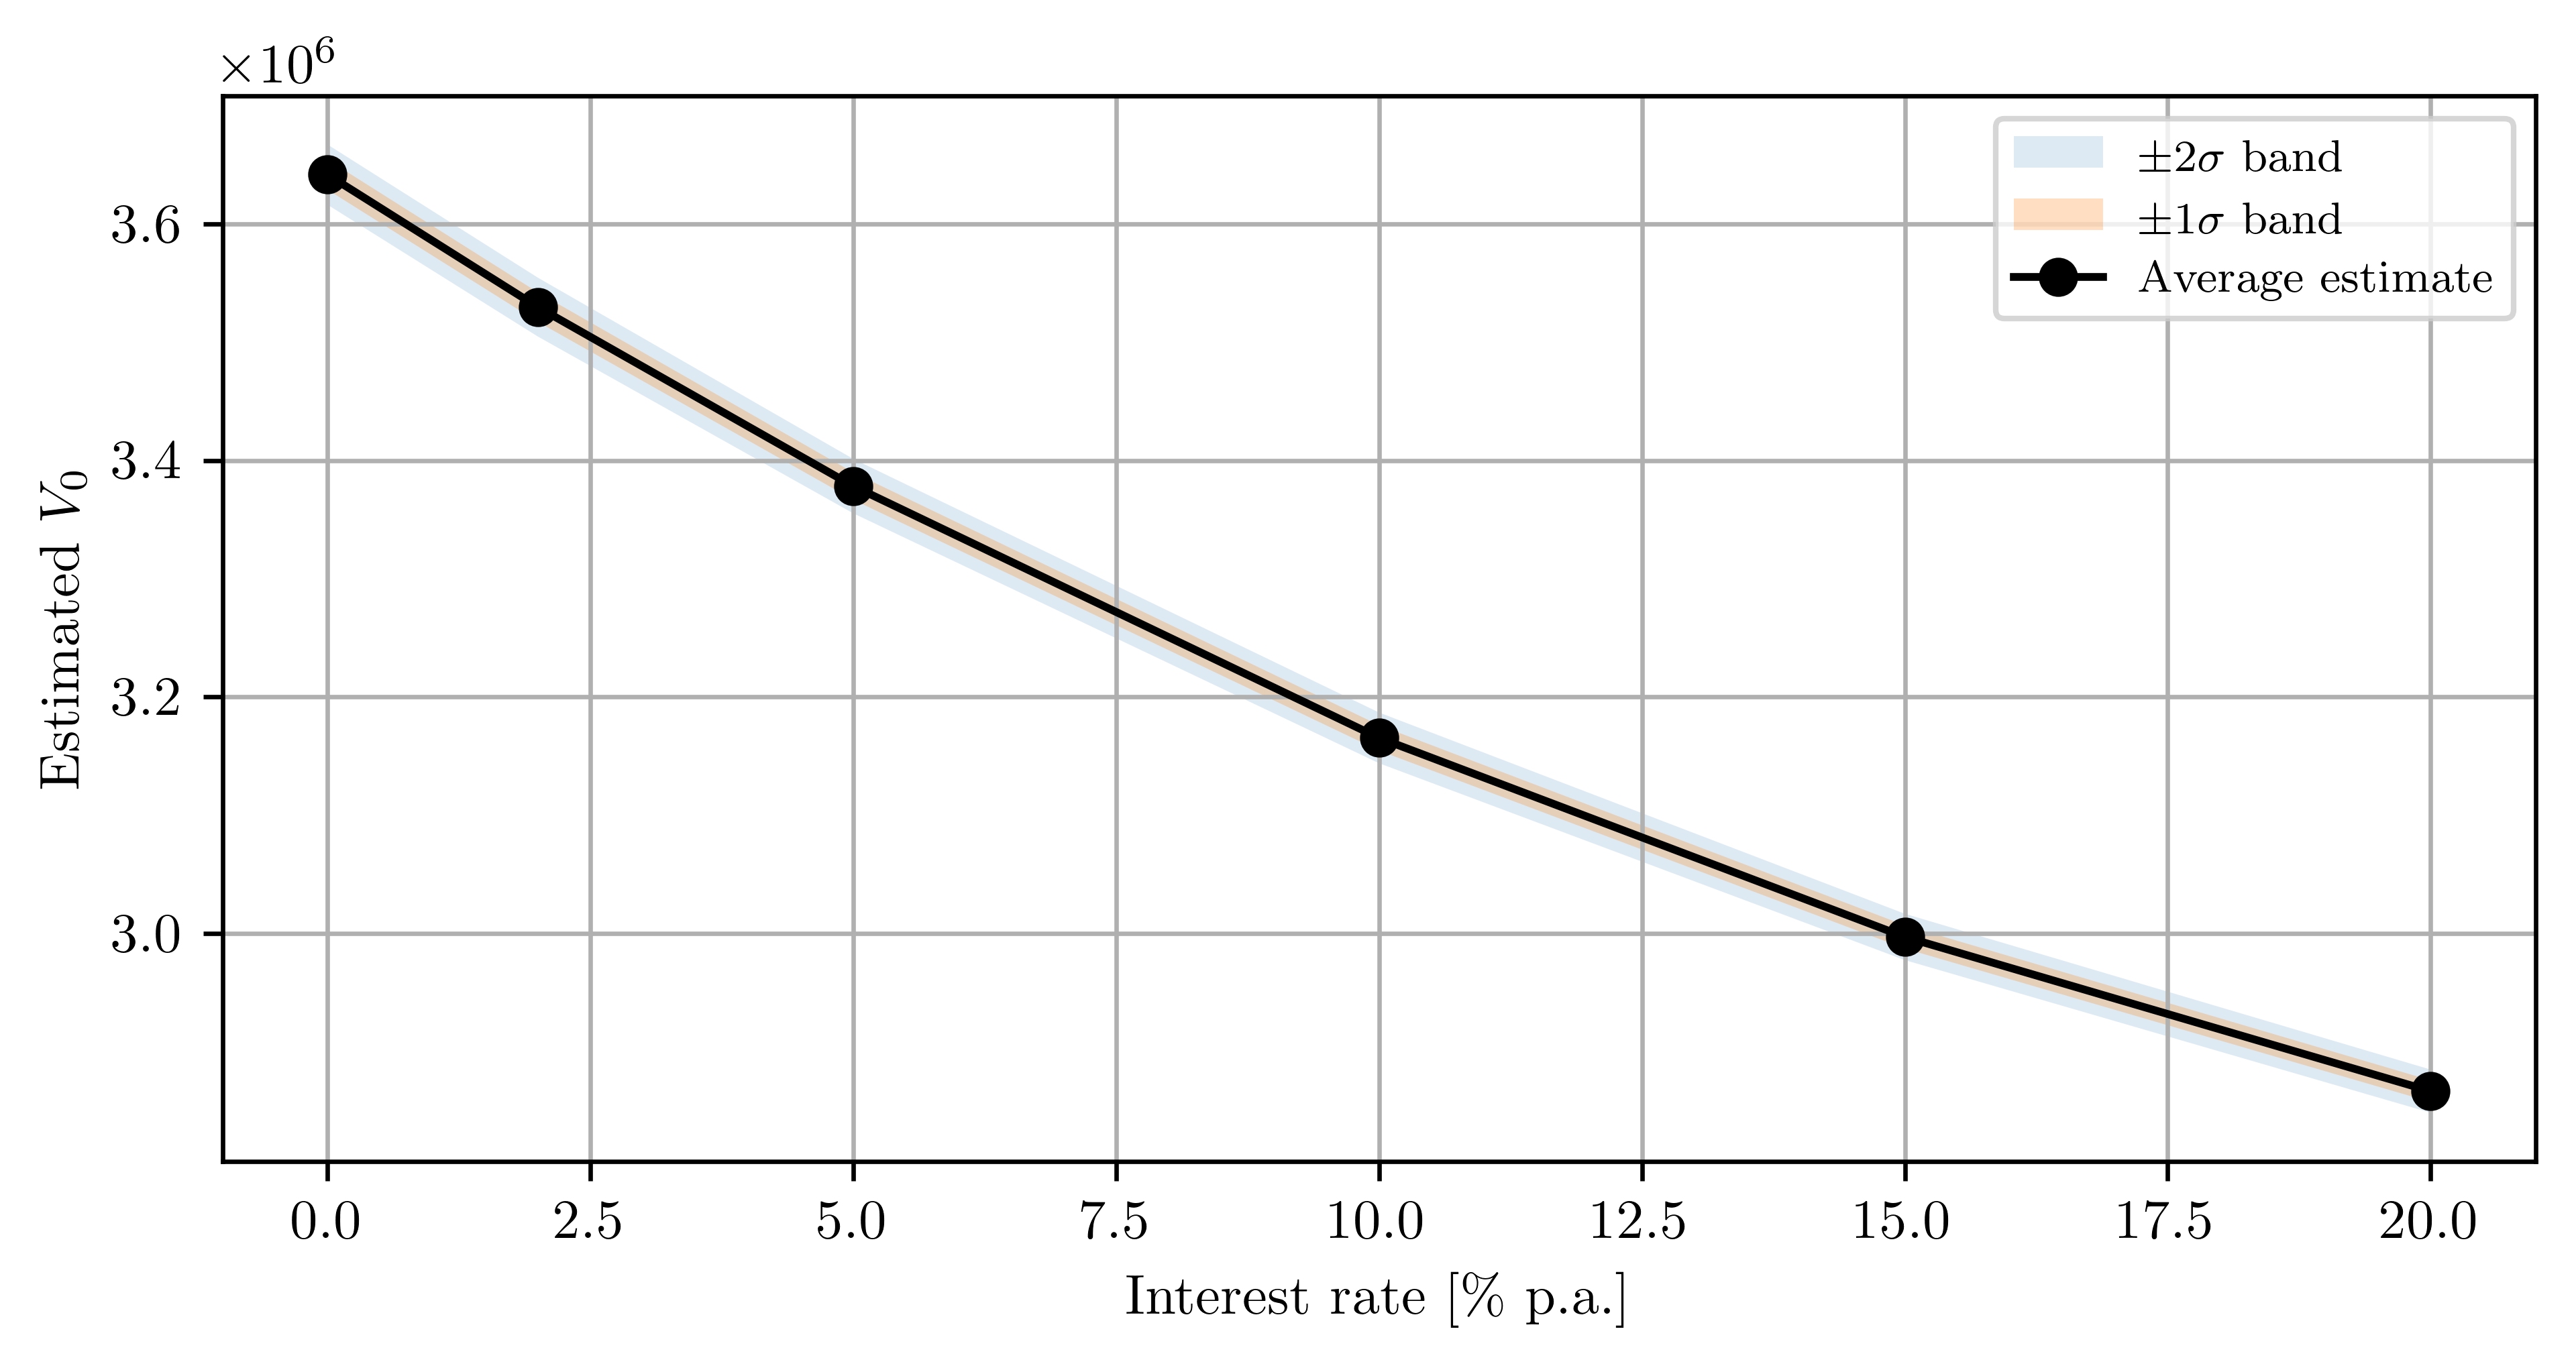

In [6]:
# -------------------------------------------------
# Convergence analysis: interest rate
# -------------------------------------------------
from tqdm import tqdm

n_paths = 10000
base_seed = 123
n_seeds = 10
interest_rate_values = [0.00, 0.02, 0.05, 0.10, 0.15, 0.20]

seed_values = base_seed + np.arange(n_seeds)
records = []

_r_annual_backup = float(r_annual)
_disc_arr_backup = disc_arr.copy()

for seed_idx, seed in enumerate(tqdm(seed_values, desc="Convergence over seeds")):
    rng = np.random.default_rng(seed)
    n_half = int(np.ceil(n_paths / 2))
    Z_half = rng.standard_normal(size=(Tn - 1, n_half))
    Z = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths]

    S = simulate_from_Z(
        Z,
        n_paths=n_paths,
        Tn=Tn,
        t_arr=t_arr,
        kappa_hat=kappa_hat,
        sigma_hat=sigma_hat,
        m_col=m_col,
    )

    for interest_rate in tqdm(
        interest_rate_values,
        desc=f"Rates for seed {seed}",
        leave=False,
    ):
        r_annual = float(interest_rate)
        disc_arr = np.exp(-r_annual * np.diff(t_arr) / 365.0)

        V0_hat = lsmc_value_given_S(S)

        records.append({
            "seed": int(seed),
            "n_paths": int(n_paths),
            "interest_rate": float(interest_rate),
            "V0_hat": V0_hat,
        })

r_annual = _r_annual_backup
disc_arr = _disc_arr_backup.copy()

results_df = pd.DataFrame(records)

summary_df = (
    results_df
    .groupby("interest_rate", as_index=False)
    .agg(
        mean_V0_hat=("V0_hat", "mean"),
        std_V0_hat=("V0_hat", lambda x: x.std(ddof=1)),
    )
    .sort_values("interest_rate")
    .reset_index(drop=True)
)

summary_df["minus_1std"] = summary_df["mean_V0_hat"] - summary_df["std_V0_hat"]
summary_df["plus_1std"] = summary_df["mean_V0_hat"] + summary_df["std_V0_hat"]
summary_df["minus_2std"] = summary_df["mean_V0_hat"] - 2.0 * summary_df["std_V0_hat"]
summary_df["plus_2std"] = summary_df["mean_V0_hat"] + 2.0 * summary_df["std_V0_hat"]

results_df = results_df.merge(summary_df, on="interest_rate", how="left")

results_df.to_csv("../data/OLS_convergence_interest_rate.csv", index=False)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

r_array_pct = 100.0 * summary_df["interest_rate"].to_numpy(dtype=np.float64)
V_mean = summary_df["mean_V0_hat"].to_numpy(dtype=np.float64)
V_std = summary_df["std_V0_hat"].to_numpy(dtype=np.float64)

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

ax.fill_between(r_array_pct, V_mean - 2.0 * V_std, V_mean + 2.0 * V_std,
                alpha=0.15, label=r"$\pm 2\sigma$ band")
ax.fill_between(r_array_pct, V_mean - V_std, V_mean + V_std,
                alpha=0.25, label=r"$\pm 1\sigma$ band")
ax.plot(r_array_pct, V_mean, linewidth=1.4, color="black", marker="o",
        label="Average estimate")

ax.set_xlabel(r"Interest rate [\% p.a.]")
ax.set_ylabel(r"Estimated $V_0$")
ax.grid(True)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_convergence_interest_rate.png")
plt.show()


,interest_rate,discount_adjustment_to_10pct,mean_relative_diff_pct,std_relative_diff_pct,mean_V0_hat_adjusted_to_10pct,mean_V0_hat_baseline_10pct
0,0.00,0.906590,4.300118,0.116885,3.301438e+06,3.165326e+06
1,0.02,0.924301,3.067184,0.102831,3.262413e+06,3.165326e+06
2,0.05,0.951755,1.576239,0.076556,3.215219e+06,3.165326e+06
3,0.10,1.000000,0.000000,0.000000,3.165326e+06,3.165326e+06
4,0.15,1.051564,-0.435078,0.034866,3.151553e+06,3.165326e+06
5,0.20,1.106705,0.226377,0.079604,3.172489e+06,3.165326e+06


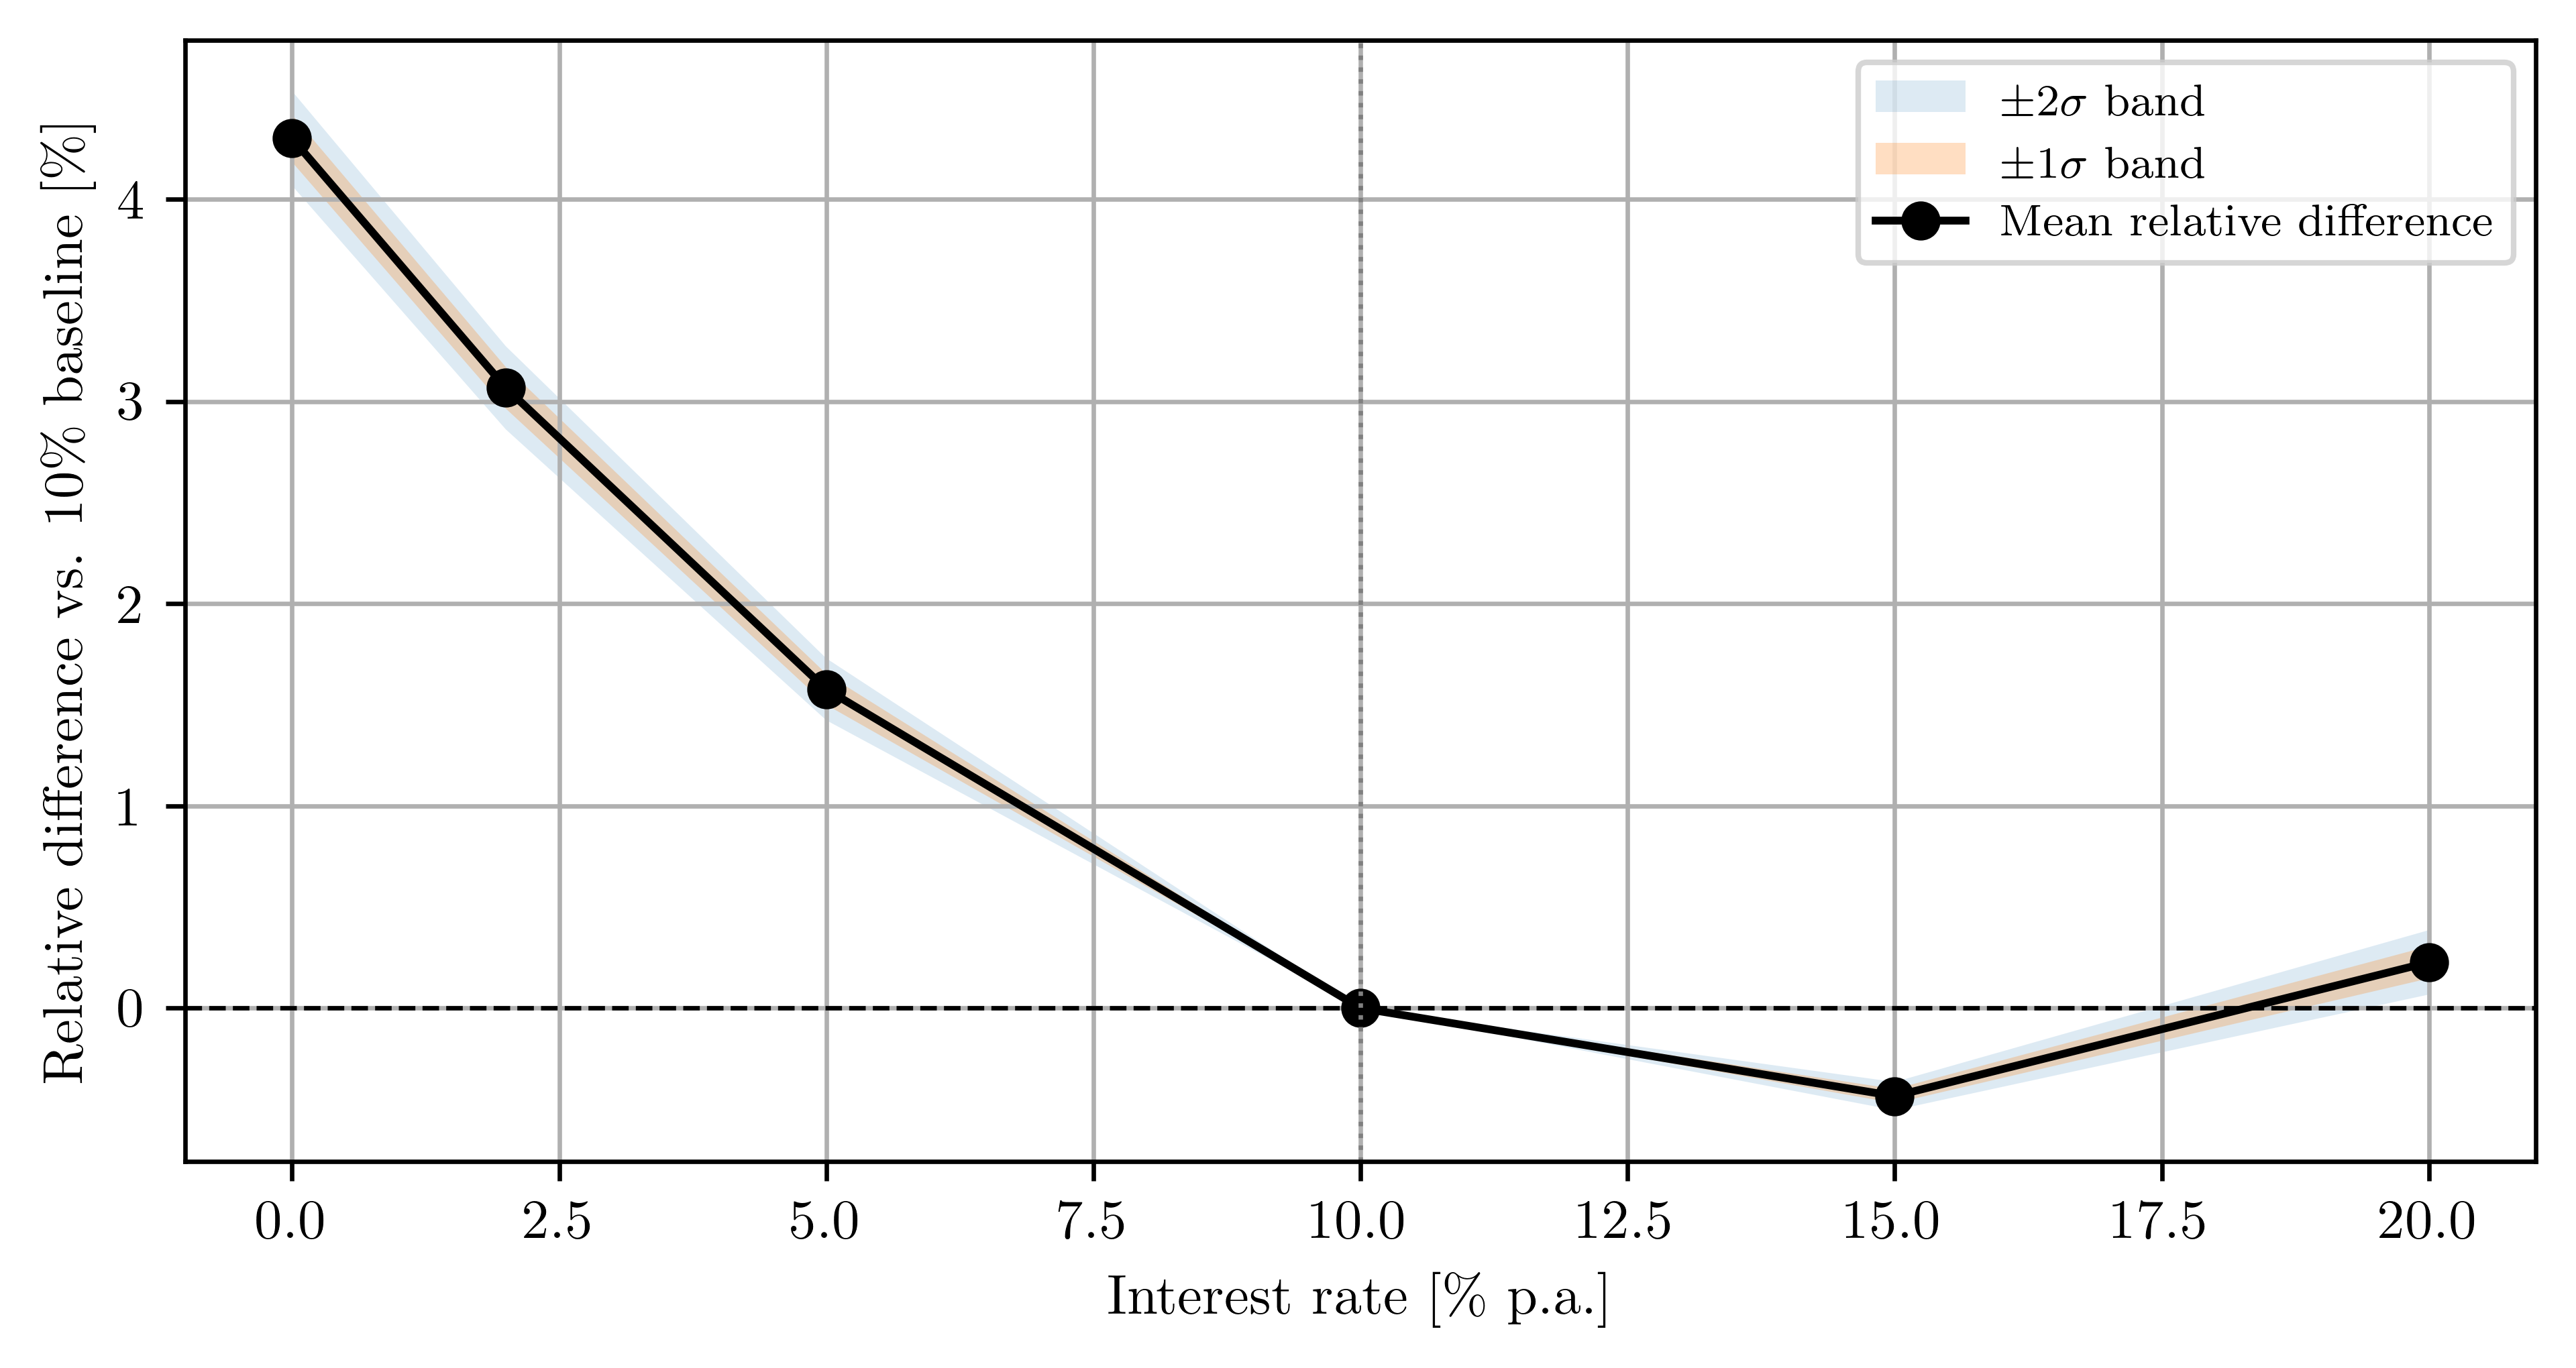

In [7]:
# -------------------------------------------------
# Interest-rate sensitivity after discount adjustment to the 10% baseline
# -------------------------------------------------

baseline_rate = 0.10

interest_df = pd.read_csv("../data/OLS_convergence_interest_rate.csv")

def disc_arr_for_rate(rate):
    return np.exp(-float(rate) * np.diff(t_arr) / 365.0)

def cum_disc_to_0_for_rate(rate):
    disc = disc_arr_for_rate(rate)
    return np.concatenate(([1.0], np.cumprod(disc[:-1])))

cum_disc_baseline = cum_disc_to_0_for_rate(baseline_rate)

rate_to_adjustment = {}
for rate in sorted(interest_df["interest_rate"].unique()):
    cum_disc_rate = cum_disc_to_0_for_rate(rate)
    # Aggregate forward-discounting to 10% via the average cumulative
    # discount ratio over the calendar grid.
    rate_to_adjustment[rate] = float(np.mean(cum_disc_baseline / cum_disc_rate))

interest_df["discount_adjustment_to_10pct"] = interest_df["interest_rate"].map(rate_to_adjustment)
interest_df["V0_hat_adjusted_to_10pct"] = (
    interest_df["V0_hat"] * interest_df["discount_adjustment_to_10pct"]
)

baseline_seed_df = (
    interest_df.loc[np.isclose(interest_df["interest_rate"], baseline_rate), ["seed", "V0_hat"]]
    .rename(columns={"V0_hat": "V0_hat_baseline_10pct"})
)

interest_df = interest_df.merge(baseline_seed_df, on="seed", how="left")
interest_df["relative_diff_pct_vs_10pct"] = 100.0 * (
    interest_df["V0_hat_adjusted_to_10pct"] - interest_df["V0_hat_baseline_10pct"]
) / np.abs(interest_df["V0_hat_baseline_10pct"])

summary_adj_df = (
    interest_df
    .groupby("interest_rate", as_index=False)
    .agg(
        mean_relative_diff_pct=("relative_diff_pct_vs_10pct", "mean"),
        std_relative_diff_pct=("relative_diff_pct_vs_10pct", lambda x: x.std(ddof=1)),
        mean_V0_hat_adjusted_to_10pct=("V0_hat_adjusted_to_10pct", "mean"),
        mean_V0_hat_baseline_10pct=("V0_hat_baseline_10pct", "mean"),
        discount_adjustment_to_10pct=("discount_adjustment_to_10pct", "first"),
    )
    .sort_values("interest_rate")
    .reset_index(drop=True)
)

summary_adj_df["minus_1std"] = (
    summary_adj_df["mean_relative_diff_pct"] - summary_adj_df["std_relative_diff_pct"]
)
summary_adj_df["plus_1std"] = (
    summary_adj_df["mean_relative_diff_pct"] + summary_adj_df["std_relative_diff_pct"]
)
summary_adj_df["minus_2std"] = (
    summary_adj_df["mean_relative_diff_pct"] - 2.0 * summary_adj_df["std_relative_diff_pct"]
)
summary_adj_df["plus_2std"] = (
    summary_adj_df["mean_relative_diff_pct"] + 2.0 * summary_adj_df["std_relative_diff_pct"]
)

display(summary_adj_df[[
    "interest_rate",
    "discount_adjustment_to_10pct",
    "mean_relative_diff_pct",
    "std_relative_diff_pct",
    "mean_V0_hat_adjusted_to_10pct",
    "mean_V0_hat_baseline_10pct",
]])

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

r_array_pct = 100.0 * summary_adj_df["interest_rate"].to_numpy(dtype=np.float64)
rel_mean = summary_adj_df["mean_relative_diff_pct"].to_numpy(dtype=np.float64)
rel_std = summary_adj_df["std_relative_diff_pct"].fillna(0.0).to_numpy(dtype=np.float64)

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

ax.fill_between(r_array_pct, rel_mean - 2.0 * rel_std, rel_mean + 2.0 * rel_std,
                alpha=0.15, label=r"$\pm 2\sigma$ band")
ax.fill_between(r_array_pct, rel_mean - rel_std, rel_mean + rel_std,
                alpha=0.25, label=r"$\pm 1\sigma$ band")
ax.plot(r_array_pct, rel_mean, linewidth=1.4, color="black", marker="o",
        label=r"Mean relative difference")
ax.axhline(0.0, color="black", lw=0.8, ls="--")
ax.axvline(100.0 * baseline_rate, color="grey", lw=0.8, ls=":")

ax.set_xlabel(r"Interest rate [\% p.a.]")
ax.set_ylabel(r"Relative difference vs. 10\% baseline [\%]")
ax.grid(True)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_convergence_interest_rate_policy_effect.png")
plt.show()


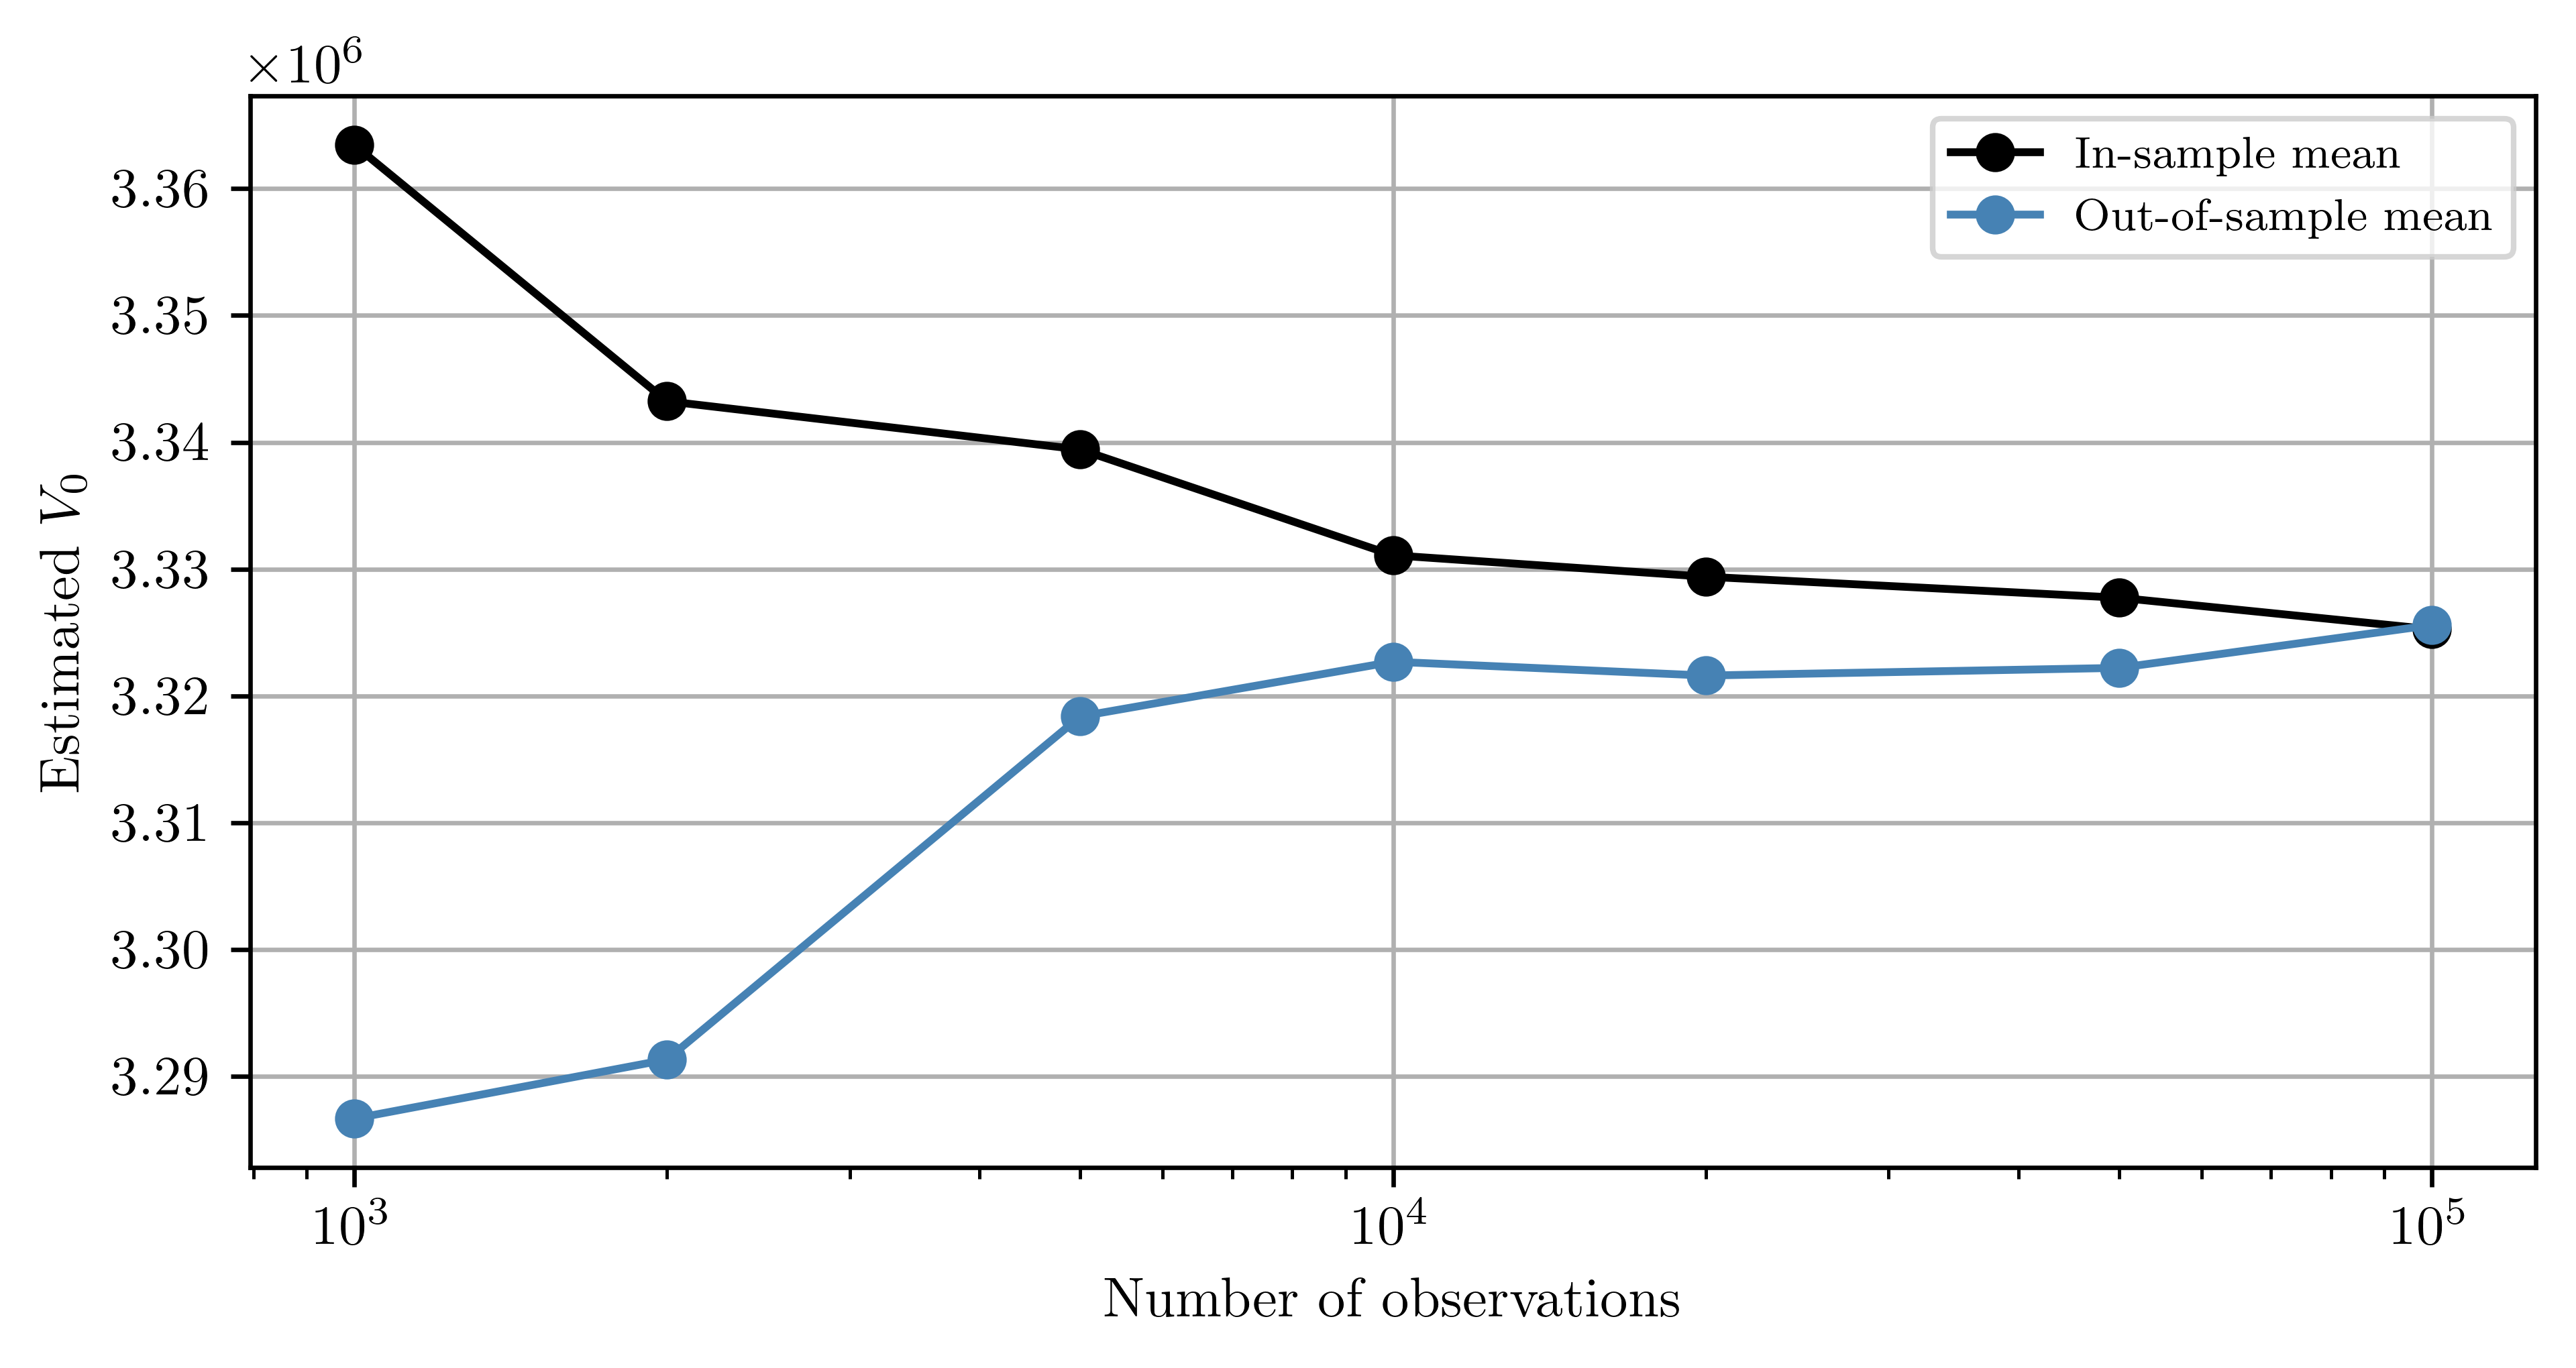

In [ ]:
import time
from tqdm import tqdm

# -------------------------------------------------
# Convergence analysis: observations (in-sample vs out-of-sample)
# -------------------------------------------------

n_observations_values = [1000, 2000, 5000, 10000, 20000, 50000, 100000]
n_observations_max = max(n_observations_values)
base_seed = 223
n_seeds = 10

seed_values = base_seed + np.arange(n_seeds)
records = []

for seed in tqdm(seed_values, desc="Convergence over seeds"):
    seed_train = int(seed)
    seed_test = int(seed + 10_000)

    rng_train = np.random.default_rng(seed_train)
    n_half_train = int(np.ceil(n_observations_max / 2))
    Z_half_train = rng_train.standard_normal(size=(Tn - 1, n_half_train))
    Z_train = np.concatenate([Z_half_train, -Z_half_train], axis=1)[:, :n_observations_max]

    rng_test = np.random.default_rng(seed_test)
    n_half_test = int(np.ceil(n_observations_max / 2))
    Z_half_test = rng_test.standard_normal(size=(Tn - 1, n_half_test))
    Z_test = np.concatenate([Z_half_test, -Z_half_test], axis=1)[:, :n_observations_max]

    for n_observations in n_observations_values:
        S_train = simulate_from_Z(
            Z_train,
            n_paths=n_observations,
            Tn=Tn,
            t_arr=t_arr,
            kappa_hat=kappa_hat,
            sigma_hat=sigma_hat,
            m_col=m_col,
        )

        t0 = time.perf_counter()
        V0_hat_is, B_store, _, _ = lsmc_value_and_B_store_given_S(S_train)
        runtime_in_sample_seconds = time.perf_counter() - t0

        S_test = simulate_from_Z(
            Z_test,
            n_paths=n_observations,
            Tn=Tn,
            t_arr=t_arr,
            kappa_hat=kappa_hat,
            sigma_hat=sigma_hat,
            m_col=m_col,
        )

        t1 = time.perf_counter()
        V0_hat_oos = oos_value_from_B_store(S_test, B_store)
        runtime_out_of_sample_seconds = time.perf_counter() - t1

        records.append({
            "seed": int(seed),
            "seed_train": seed_train,
            "seed_test": seed_test,
            "n_observations": int(n_observations),
            "V0_hat_in_sample": V0_hat_is,
            "V0_hat_out_of_sample": V0_hat_oos,
            "runtime_in_sample_seconds": runtime_in_sample_seconds,
            "runtime_out_of_sample_seconds": runtime_out_of_sample_seconds,
            "runtime_total_seconds": runtime_in_sample_seconds + runtime_out_of_sample_seconds,
        })

results_df = pd.DataFrame(records)

summary_df = (
    results_df
    .groupby("n_observations", as_index=False)
    .agg(
        mean_V0_hat_in_sample=("V0_hat_in_sample", "mean"),
        std_V0_hat_in_sample=("V0_hat_in_sample", lambda x: x.std(ddof=1)),
        mean_V0_hat_out_of_sample=("V0_hat_out_of_sample", "mean"),
        std_V0_hat_out_of_sample=("V0_hat_out_of_sample", lambda x: x.std(ddof=1)),
        mean_runtime_in_sample_seconds=("runtime_in_sample_seconds", "mean"),
        std_runtime_in_sample_seconds=("runtime_in_sample_seconds", lambda x: x.std(ddof=1)),
        mean_runtime_out_of_sample_seconds=("runtime_out_of_sample_seconds", "mean"),
        std_runtime_out_of_sample_seconds=("runtime_out_of_sample_seconds", lambda x: x.std(ddof=1)),
        mean_runtime_total_seconds=("runtime_total_seconds", "mean"),
        std_runtime_total_seconds=("runtime_total_seconds", lambda x: x.std(ddof=1)),
    )
    .sort_values("n_observations")
    .reset_index(drop=True)
)

summary_df["minus_1std_in_sample"] = summary_df["mean_V0_hat_in_sample"] - summary_df["std_V0_hat_in_sample"]
summary_df["plus_1std_in_sample"] = summary_df["mean_V0_hat_in_sample"] + summary_df["std_V0_hat_in_sample"]
summary_df["minus_2std_in_sample"] = summary_df["mean_V0_hat_in_sample"] - 2.0 * summary_df["std_V0_hat_in_sample"]
summary_df["plus_2std_in_sample"] = summary_df["mean_V0_hat_in_sample"] + 2.0 * summary_df["std_V0_hat_in_sample"]
summary_df["minus_1std_out_of_sample"] = summary_df["mean_V0_hat_out_of_sample"] - summary_df["std_V0_hat_out_of_sample"]
summary_df["plus_1std_out_of_sample"] = summary_df["mean_V0_hat_out_of_sample"] + summary_df["std_V0_hat_out_of_sample"]
summary_df["minus_2std_out_of_sample"] = summary_df["mean_V0_hat_out_of_sample"] - 2.0 * summary_df["std_V0_hat_out_of_sample"]
summary_df["plus_2std_out_of_sample"] = summary_df["mean_V0_hat_out_of_sample"] + 2.0 * summary_df["std_V0_hat_out_of_sample"]

results_df = results_df.merge(summary_df, on="n_observations", how="left")
results_df.to_csv("../data/OLS_convergence_observations_out_of_sample.csv", index=False)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

obs_array = summary_df["n_observations"].to_numpy(dtype=np.float64)
V_is_mean = summary_df["mean_V0_hat_in_sample"].to_numpy(dtype=np.float64)
V_is_std = summary_df["std_V0_hat_in_sample"].to_numpy(dtype=np.float64)
V_oos_mean = summary_df["mean_V0_hat_out_of_sample"].to_numpy(dtype=np.float64)
V_oos_std = summary_df["std_V0_hat_out_of_sample"].to_numpy(dtype=np.float64)

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

ax.plot(obs_array, V_is_mean, linewidth=1.4, color="black", marker="o",
        label="In-sample mean")
ax.plot(obs_array, V_oos_mean, linewidth=1.4, color="steelblue", marker="o", label="Out-of-sample mean")

ax.set_xscale("log")
ax.set_xlabel("Number of observations")
ax.set_ylabel(r"Estimated $V_0$")
ax.grid(True)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_convergence_observations_out_of_sample.png")
plt.show()

Convergence over seeds: 100%|██████████| 10/10 [04:35<00:00, 27.53s/it]


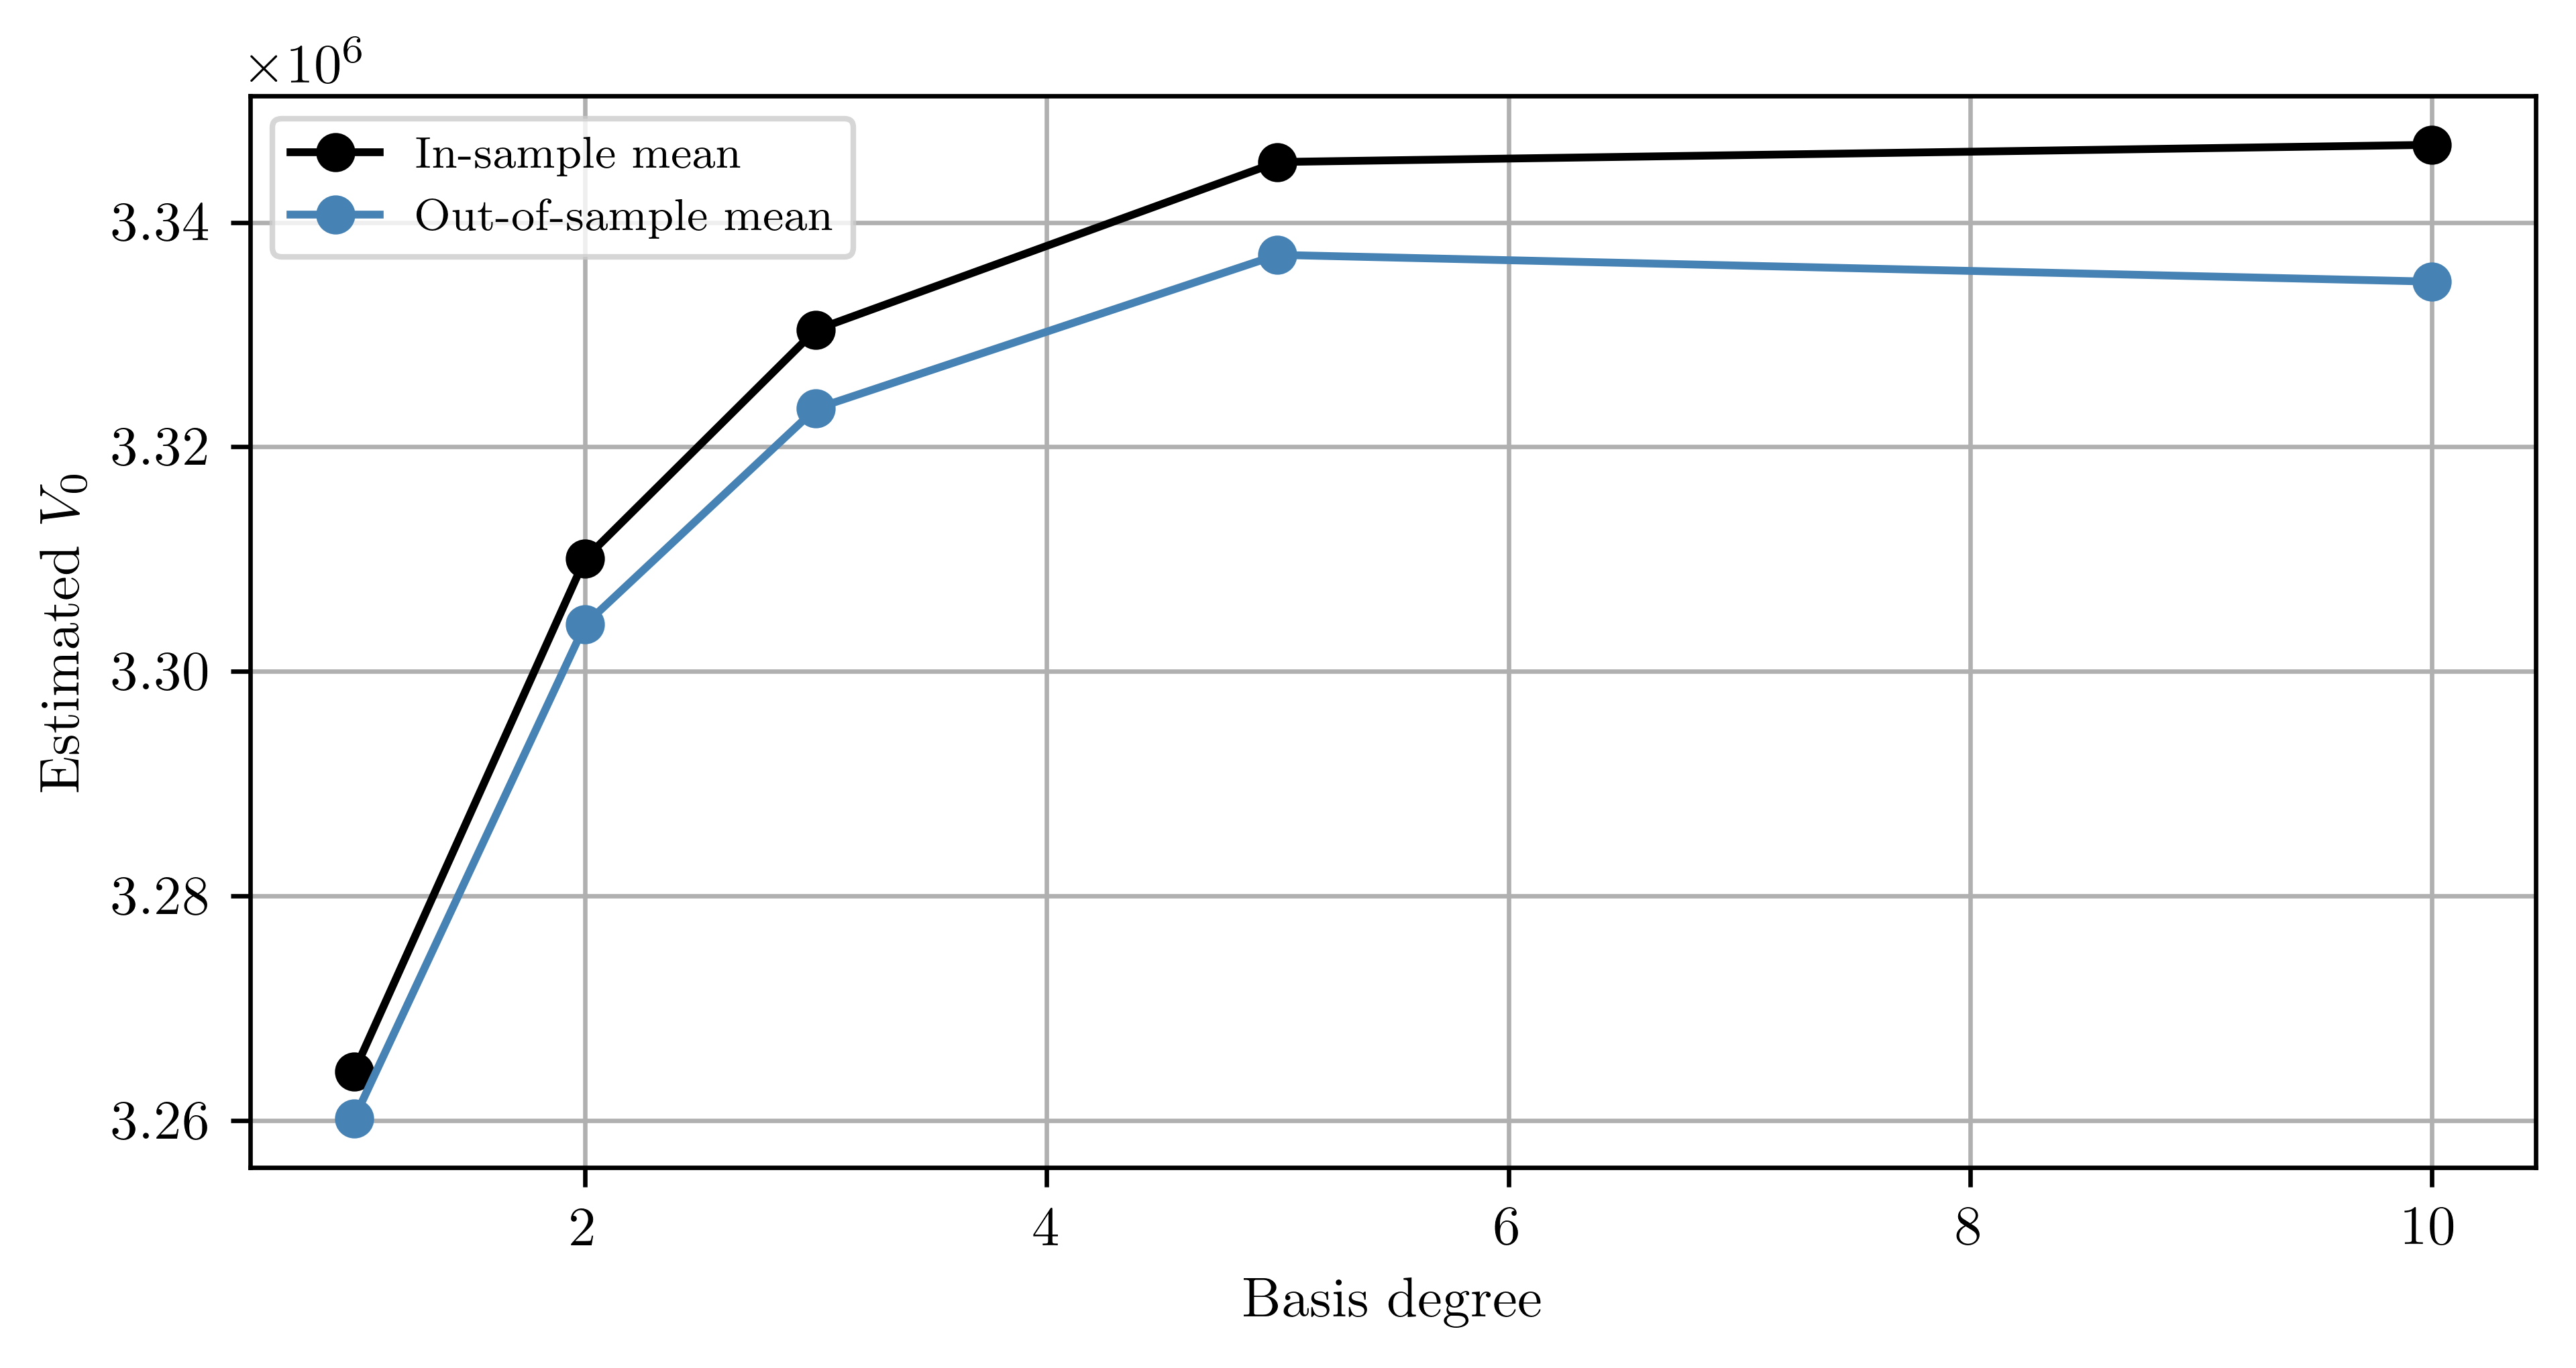

In [32]:
import time
from tqdm import tqdm

# -------------------------------------------------
# Convergence analysis: basis degree (in-sample vs out-of-sample)
# -------------------------------------------------

n_observations = 10000
base_seed = 323
n_seeds = 10
basis_degree_values = [1, 2, 3, 5, 10]
basis_family_name = "monomial"

seed_values = base_seed + np.arange(n_seeds)
records = []

for seed in tqdm(seed_values, desc="Convergence over seeds"):
    seed_train = int(seed)
    seed_test = int(seed + 10_000)

    rng_train = np.random.default_rng(seed_train)
    n_half_train = int(np.ceil(n_observations / 2))
    Z_half_train = rng_train.standard_normal(size=(Tn - 1, n_half_train))
    Z_train = np.concatenate([Z_half_train, -Z_half_train], axis=1)[:, :n_observations]

    rng_test = np.random.default_rng(seed_test)
    n_half_test = int(np.ceil(n_observations / 2))
    Z_half_test = rng_test.standard_normal(size=(Tn - 1, n_half_test))
    Z_test = np.concatenate([Z_half_test, -Z_half_test], axis=1)[:, :n_observations]

    S_train = simulate_from_Z(
        Z_train,
        n_paths=n_observations,
        Tn=Tn,
        t_arr=t_arr,
        kappa_hat=kappa_hat,
        sigma_hat=sigma_hat,
        m_col=m_col,
    )

    S_test = simulate_from_Z(
        Z_test,
        n_paths=n_observations,
        Tn=Tn,
        t_arr=t_arr,
        kappa_hat=kappa_hat,
        sigma_hat=sigma_hat,
        m_col=m_col,
    )

    for basis_degree in basis_degree_values:
        t0 = time.perf_counter()
        V0_hat_is, B_store, _, _ = lsmc_value_and_B_store_given_S(
            S_train,
            basis_degree_override=basis_degree,
            basis_family_override=basis_family_name,
        )
        runtime_in_sample_seconds = time.perf_counter() - t0

        t1 = time.perf_counter()
        V0_hat_oos = oos_value_from_B_store(
            S_test,
            B_store,
            basis_degree_override=basis_degree,
            basis_family_override=basis_family_name,
        )
        runtime_out_of_sample_seconds = time.perf_counter() - t1

        records.append({
            "seed": int(seed),
            "seed_train": seed_train,
            "seed_test": seed_test,
            "n_observations": int(n_observations),
            "basis_family": basis_family_name,
            "basis_degree": int(basis_degree),
            "V0_hat_in_sample": V0_hat_is,
            "V0_hat_out_of_sample": V0_hat_oos,
            "runtime_in_sample_seconds": runtime_in_sample_seconds,
            "runtime_out_of_sample_seconds": runtime_out_of_sample_seconds,
            "runtime_total_seconds": runtime_in_sample_seconds + runtime_out_of_sample_seconds,
        })

results_df = pd.DataFrame(records)

summary_df = (
    results_df
    .groupby("basis_degree", as_index=False)
    .agg(
        mean_V0_hat_in_sample=("V0_hat_in_sample", "mean"),
        std_V0_hat_in_sample=("V0_hat_in_sample", lambda x: x.std(ddof=1)),
        mean_V0_hat_out_of_sample=("V0_hat_out_of_sample", "mean"),
        std_V0_hat_out_of_sample=("V0_hat_out_of_sample", lambda x: x.std(ddof=1)),
        mean_runtime_in_sample_seconds=("runtime_in_sample_seconds", "mean"),
        std_runtime_in_sample_seconds=("runtime_in_sample_seconds", lambda x: x.std(ddof=1)),
        mean_runtime_out_of_sample_seconds=("runtime_out_of_sample_seconds", "mean"),
        std_runtime_out_of_sample_seconds=("runtime_out_of_sample_seconds", lambda x: x.std(ddof=1)),
        mean_runtime_total_seconds=("runtime_total_seconds", "mean"),
        std_runtime_total_seconds=("runtime_total_seconds", lambda x: x.std(ddof=1)),
    )
    .sort_values("basis_degree")
    .reset_index(drop=True)
)

summary_df["minus_1std_in_sample"] = summary_df["mean_V0_hat_in_sample"] - summary_df["std_V0_hat_in_sample"]
summary_df["plus_1std_in_sample"] = summary_df["mean_V0_hat_in_sample"] + summary_df["std_V0_hat_in_sample"]
summary_df["minus_2std_in_sample"] = summary_df["mean_V0_hat_in_sample"] - 2.0 * summary_df["std_V0_hat_in_sample"]
summary_df["plus_2std_in_sample"] = summary_df["mean_V0_hat_in_sample"] + 2.0 * summary_df["std_V0_hat_in_sample"]
summary_df["minus_1std_out_of_sample"] = summary_df["mean_V0_hat_out_of_sample"] - summary_df["std_V0_hat_out_of_sample"]
summary_df["plus_1std_out_of_sample"] = summary_df["mean_V0_hat_out_of_sample"] + summary_df["std_V0_hat_out_of_sample"]
summary_df["minus_2std_out_of_sample"] = summary_df["mean_V0_hat_out_of_sample"] - 2.0 * summary_df["std_V0_hat_out_of_sample"]
summary_df["plus_2std_out_of_sample"] = summary_df["mean_V0_hat_out_of_sample"] + 2.0 * summary_df["std_V0_hat_out_of_sample"]

results_df = results_df.merge(summary_df, on="basis_degree", how="left")
results_df.to_csv("../data/OLS_convergence_basis_degree_out_of_sample.csv", index=False)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

basis_array = summary_df["basis_degree"].to_numpy(dtype=np.float64)
V_is_mean = summary_df["mean_V0_hat_in_sample"].to_numpy(dtype=np.float64)
V_is_std = summary_df["std_V0_hat_in_sample"].to_numpy(dtype=np.float64)
V_oos_mean = summary_df["mean_V0_hat_out_of_sample"].to_numpy(dtype=np.float64)
V_oos_std = summary_df["std_V0_hat_out_of_sample"].to_numpy(dtype=np.float64)

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

ax.plot(basis_array, V_is_mean, linewidth=1.4, color="black", marker="o",
        label="In-sample mean")
ax.plot(basis_array, V_oos_mean, linewidth=1.4, color="steelblue", marker="o",
        label="Out-of-sample mean")

ax.set_xlabel("Basis degree")
ax.set_ylabel(r"Estimated $V_0$")
ax.grid(True)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_convergence_basis_degree_out_of_sample.png")
plt.show()

Convergence over seeds: 100%|██████████| 5/5 [10:35<00:00, 127.10s/it]


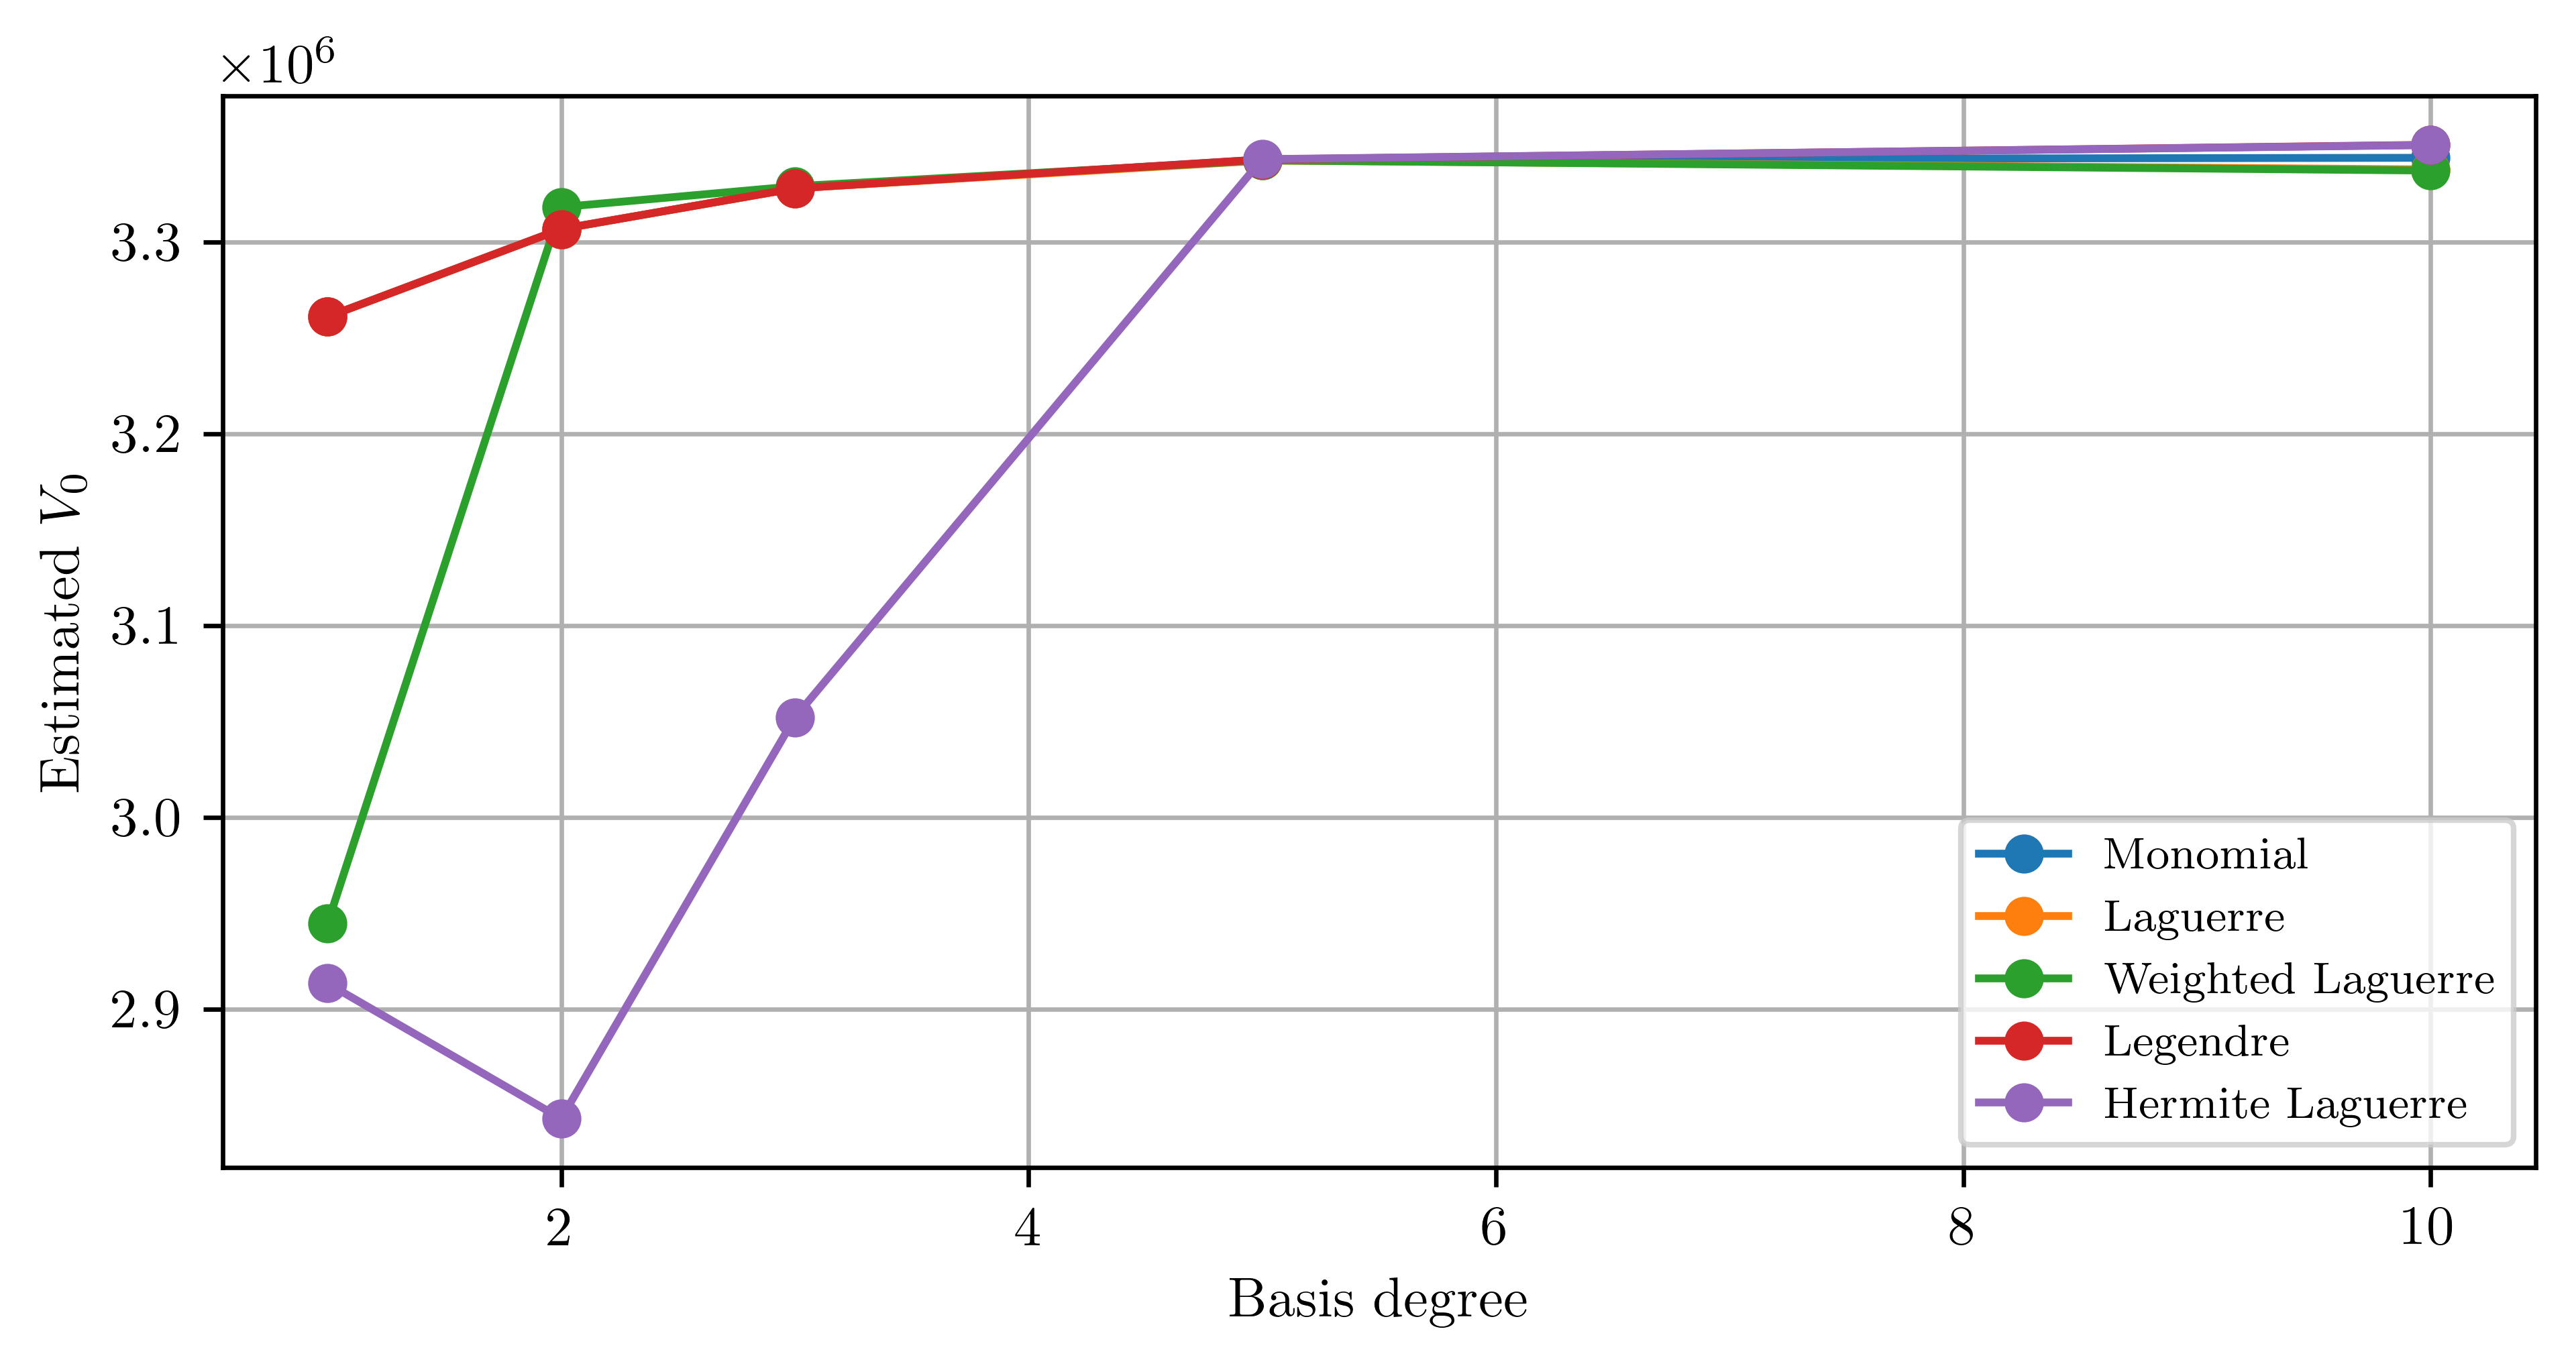

In [30]:
import time
from tqdm import tqdm

# -------------------------------------------------
# Convergence analysis: Basis families
# -------------------------------------------------

n_paths = 10000
base_seed = 123
n_seeds = 5
basis_degree_values = [1, 2, 3, 5, 10]
basis_families = ["monomial", "laguerre", "weighted_laguerre", "legendre", "hermite_laguerre"]

seed_values = base_seed + np.arange(n_seeds)
records = []

for seed in tqdm(seed_values, desc="Convergence over seeds"):
    rng = np.random.default_rng(int(seed))
    n_half = int(np.ceil(n_paths / 2))
    Z_half = rng.standard_normal(size=(Tn - 1, n_half))
    Z = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths]

    S = simulate_from_Z(
        Z,
        n_paths=n_paths,
        Tn=Tn,
        t_arr=t_arr,
        kappa_hat=kappa_hat,
        sigma_hat=sigma_hat,
        m_col=m_col,
    )

    for basis_family_name in basis_families:
        for basis_degree in basis_degree_values:
            t0 = time.perf_counter()
            V0_hat = lsmc_value_given_S_and_basis_degree(
                S,
                basis_degree=basis_degree,
                basis_family=basis_family_name,
            )
            runtime_seconds = time.perf_counter() - t0

            records.append({
                "seed": int(seed),
                "n_paths": int(n_paths),
                "basis_family": basis_family_name,
                "basis_degree": int(basis_degree),
                "V0_hat": V0_hat,
                "runtime_seconds": runtime_seconds,
            })

results_df = pd.DataFrame(records)

summary_df = (
    results_df
    .groupby(["basis_family", "basis_degree"], as_index=False)
    .agg(
        mean_V0_hat=("V0_hat", "mean"),
        std_V0_hat=("V0_hat", lambda x: x.std(ddof=1)),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        std_runtime_seconds=("runtime_seconds", lambda x: x.std(ddof=1)),
    )
    .sort_values(["basis_family", "basis_degree"])
    .reset_index(drop=True)
)

summary_df["minus_1std"] = summary_df["mean_V0_hat"] - summary_df["std_V0_hat"]
summary_df["plus_1std"] = summary_df["mean_V0_hat"] + summary_df["std_V0_hat"]
summary_df["minus_2std"] = summary_df["mean_V0_hat"] - 2.0 * summary_df["std_V0_hat"]
summary_df["plus_2std"] = summary_df["mean_V0_hat"] + 2.0 * summary_df["std_V0_hat"]

summary_df.to_csv("../data/OLS_convergence_basis_families.csv", index=False)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

for basis_family_name in basis_families:
    basis_df = summary_df.loc[summary_df["basis_family"] == basis_family_name].sort_values("basis_degree")
    x_vals = basis_df["basis_degree"].to_numpy(dtype=np.float64)
    y_mean = basis_df["mean_V0_hat"].to_numpy(dtype=np.float64)
    ax.plot(x_vals, y_mean, linewidth=1.4, marker="o", label=basis_family_name.replace("_", " ").title())

ax.set_xlabel("Basis degree")
ax.set_ylabel(r"Estimated $V_0$")
ax.grid(True)
ax.legend(loc="best", fontsize=8)
plt.savefig("../../fig/Plots/OLS_convergence_basis_families.png")
fig.tight_layout()
plt.show()


In [ ]:
import time
from tqdm import tqdm

# -------------------------------------------------
# Basis family / degree / observations summary
# -------------------------------------------------

n_observations_values = [1000, 5000, 20000]
n_observations_max = max(n_observations_values)
base_seed = 423
n_seeds = 5
basis_degree_values = [2, 3, 5]
basis_families = ["monomial", "laguerre", "legendre"]

seed_values = base_seed + np.arange(n_seeds)
records = []

for seed in tqdm(seed_values, desc="Convergence over seeds"):
    rng = np.random.default_rng(int(seed))
    n_half = int(np.ceil(n_observations_max / 2))
    Z_half = rng.standard_normal(size=(Tn - 1, n_half))
    Z_full = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_observations_max]

    for n_observations in n_observations_values:
        S = simulate_from_Z(
            Z_full,
            n_paths=n_observations,
            Tn=Tn,
            t_arr=t_arr,
            kappa_hat=kappa_hat,
            sigma_hat=sigma_hat,
            m_col=m_col,
        )

        for basis_family_name in basis_families:
            for basis_degree in basis_degree_values:
                t0 = time.perf_counter()
                V0_hat = lsmc_value_given_S_and_basis_degree(
                    S,
                    basis_degree=basis_degree,
                    basis_family=basis_family_name,
                )
                runtime_seconds = time.perf_counter() - t0

                records.append({
                    "seed": int(seed),
                    "n_observations": int(n_observations),
                    "basis_family": basis_family_name,
                    "basis_degree": int(basis_degree),
                    "V0_hat": V0_hat,
                    "runtime_seconds": runtime_seconds,
                })

results_df = pd.DataFrame(records)

results_df.to_csv("../data/OLS_basis_family_degree_observations.csv", index=False)

summary_df = (
    results_df
    .groupby(["basis_family", "basis_degree", "n_observations"], as_index=False)
    .agg(
        mean_V0_hat=("V0_hat", "mean"),
        std_V0_hat=("V0_hat", lambda x: x.std(ddof=1)),
        mean_runtime_seconds=("runtime_seconds", "mean"),
    )
    .sort_values(["basis_family", "basis_degree", "n_observations"])
    .reset_index(drop=True)
)

summary_df.to_csv("../data/OLS_basis_family_degree_observations_summary.csv", index=False)
summary_df



alpha_c=  20,000  Nc=   13  Nf=   241
  Pre-computing feasible action sets... done (1.1s)
  V0_hat =   3,079,648.49 EUR   (4.1s)

alpha_c=  15,000  Nc=   18  Nf=   256
  Pre-computing feasible action sets... done (1.2s)
  V0_hat =   3,079,619.10 EUR   (4.7s)

alpha_c=  10,000  Nc=   26  Nf=   251
  Pre-computing feasible action sets... done (1.1s)
  V0_hat =   3,157,898.84 EUR   (6.0s)

alpha_c=   8,000  Nc=   32  Nf=   249
  Pre-computing feasible action sets... done (1.1s)
  V0_hat =   3,143,678.92 EUR   (6.7s)

alpha_c=   5,000  Nc=   51  Nf=   251
  Pre-computing feasible action sets... done (1.1s)
  V0_hat =   3,166,943.84 EUR   (9.2s)

alpha_c=   3,000  Nc=   84  Nf=   250
  Pre-computing feasible action sets... done (1.1s)
  V0_hat =   3,161,541.46 EUR   (13.7s)

alpha_c=   2,000  Nc=  126  Nf=   251
  Pre-computing feasible action sets... done (1.2s)
  V0_hat =   3,172,381.26 EUR   (18.5s)

alpha_c=   1,000  Nc=  251  Nf=   251
  Pre-computing feasible action sets... done (1.1

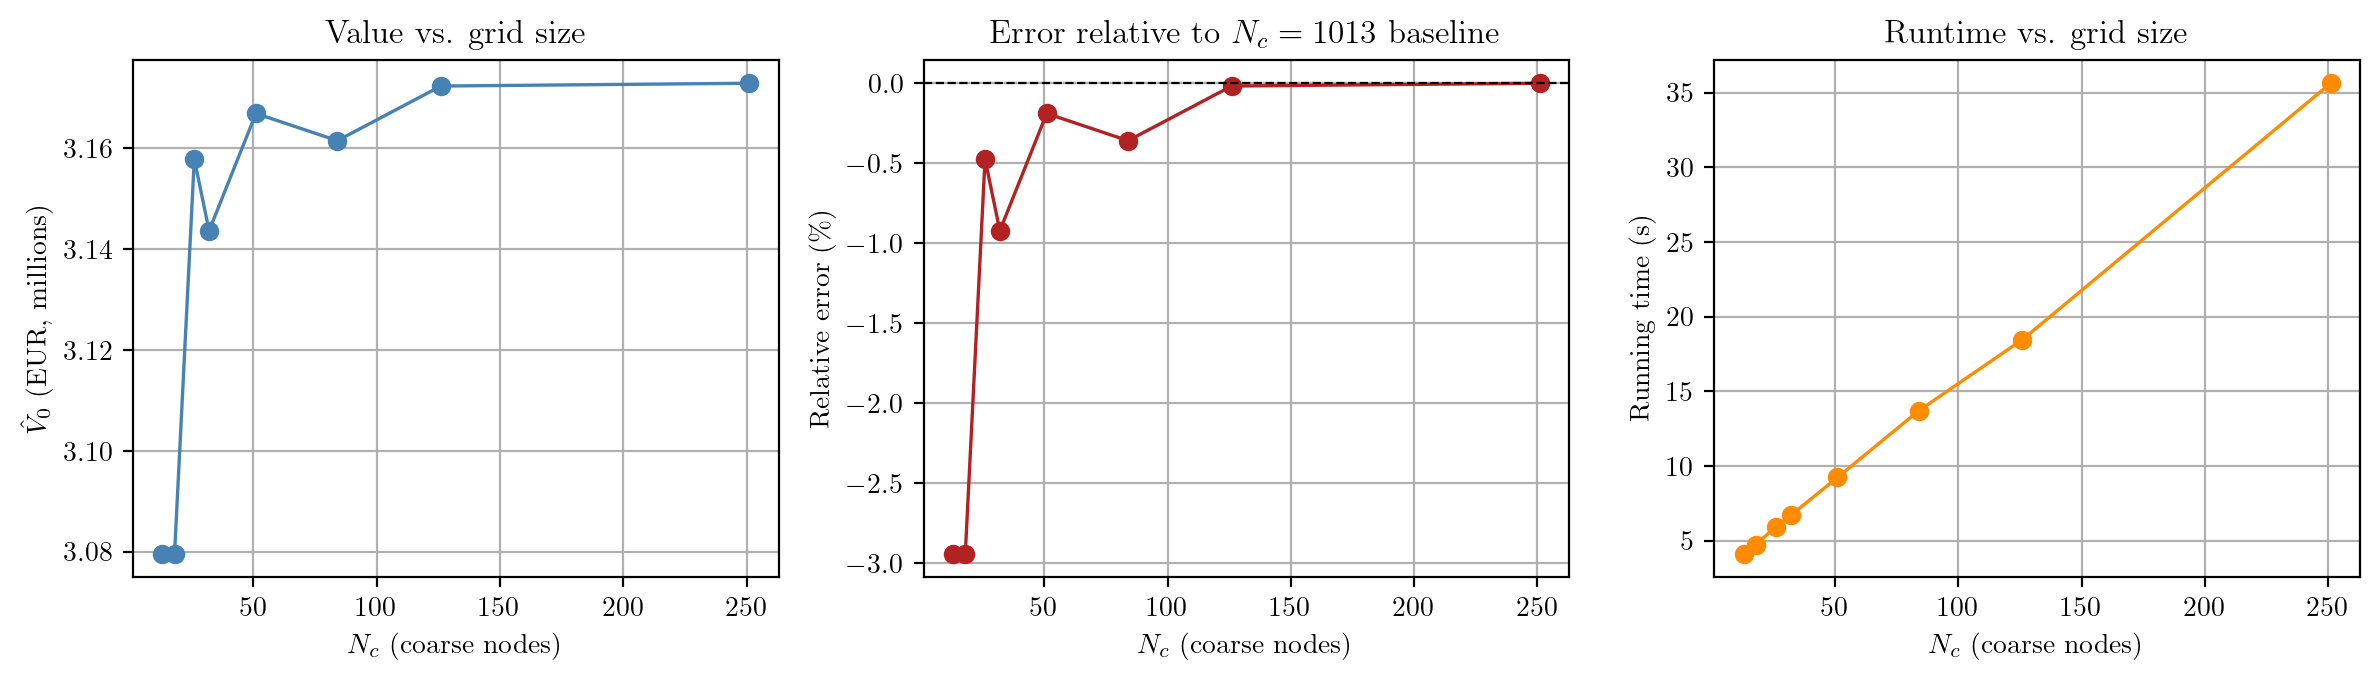

In [4]:
# ============================================================
# Grid convergence study: vary alpha_c, keep alpha_f = 2500 fixed
# refine_factor = alpha_c / 2500 is updated each iteration so the
# fine grid spacing is always 2500 MWh regardless of coarse spacing.
# Coarsest -> finest so the loop ends at the original state.
# ============================================================
import time

_alpha_c_candidates = [20000, 15000, 10000, 8000, 5000, 3000, 2000, 1000]

n_paths = 10000
convergence_results = []

ALPHA_F_FINE = 1000   # fine grid spacing — held constant

seed = 123

rng = np.random.default_rng(seed)
n_half = int(np.ceil(n_paths / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths]

S_sim = simulate_from_Z(Z, n_paths=n_paths, Tn=Tn, t_arr=t_arr,
                        kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

for _alpha_c_val in _alpha_c_candidates:
    # ---- rebuild grid globals ----
    alpha_c         = float(_alpha_c_val)
    refine_factor   = int(round(alpha_c / ALPHA_F_FINE))
    alpha_f         = alpha_c / refine_factor          # == ALPHA_F_FINE
    Nc              = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
    Nf              = (Nc - 1) * refine_factor + 1
    v_coarse        = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
    v_fine          = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
    coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
    assert coarse_fine_idx[-1] == Nf - 1
    assert abs(alpha_f - ALPHA_F_FINE) < 1e-6, f'alpha_f={alpha_f} != {ALPHA_F_FINE}'

    # snap starting / terminal inventory to new fine grid
    n0_f = int(round((vT_target - VMIN_CONST) / alpha_f))
    nT_f = int(round((vT_target - VMIN_CONST) / alpha_f))

    # ---- rebuild feasible-action sets ----
    print(f"\nalpha_c={alpha_c:>8,.0f}  Nc={Nc:>5d}  Nf={Nf:>6d}")
    print("  Pre-computing feasible action sets...", end=" ", flush=True)
    t_fa = time.perf_counter()

    all_next_idx = []
    all_dv_mat   = []
    all_K_len    = []
    all_dest_ok  = []
    for t_idx in range(Tn):
        ni, dv, kl = build_feasible_actions_at_t(t_idx)
        all_next_idx.append(ni)
        all_dv_mat.append(dv)
        all_K_len.append(kl)
        t_next = min(t_idx + 1, len(vmax_arr) - 1)
        all_dest_ok.append(
            (v_fine >= vmin_arr[t_next] - 1e-6) &
            (v_fine <= vmax_arr[t_next] + 1e-6)
        )

    all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
    all_can_reach[T][nT_f] = True
    for t_idx in range(T - 1, -1, -1):
        can_reach_next = all_can_reach[t_idx + 1]
        can_reach_now  = all_can_reach[t_idx]
        ni_t = all_next_idx[t_idx]
        kl_t = all_K_len[t_idx]
        for n_f in range(Nf):
            klen = kl_t[n_f]
            if klen == 0:
                continue
            can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])

    print(f"done ({time.perf_counter()-t_fa:.1f}s)")

    # ---- run LSMC ----
    t0 = time.perf_counter()
    V0_hat_nc = lsmc_value_given_S(S_sim)
    elapsed = time.perf_counter() - t0

    convergence_results.append({
        "alpha_c": int(alpha_c), "Nc": Nc, "Nf": Nf,
        "V0_hat": V0_hat_nc, "time_s": elapsed,
    })
    print(f"  V0_hat = {V0_hat_nc:>14,.2f} EUR   ({elapsed:.1f}s)")

# ---- summary table ----
df_conv = pd.DataFrame(convergence_results)
print("\n--- Convergence summary ---")
print(df_conv.to_string(index=False))

# ---- plot ----
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

baseline_V0 = df_conv.loc[df_conv["Nc"].idxmax(), "V0_hat"]
df_conv["rel_error_pct"] = 100.0 * (df_conv["V0_hat"] - baseline_V0) / abs(baseline_V0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), dpi=200)

axes[0].plot(df_conv["Nc"], df_conv["V0_hat"] / 1e6,
             marker="o", color="steelblue", lw=1.2)
axes[0].set_xlabel(r"$N_c$ (coarse nodes)")
axes[0].set_ylabel(r"$\hat{V}_0$ (EUR, millions)")
axes[0].set_title("Value vs. grid size")
axes[0].grid(True)

axes[1].plot(df_conv["Nc"], df_conv["rel_error_pct"],
             marker="o", color="firebrick", lw=1.2)
axes[1].axhline(0, ls="--", lw=0.8, color="black")
axes[1].set_xlabel(r"$N_c$ (coarse nodes)")
axes[1].set_ylabel(r"Relative error (\%)")
axes[1].set_title(r"Error relative to $N_c = 1013$ baseline")
axes[1].grid(True)

axes[2].plot(df_conv["Nc"], df_conv["time_s"],
             marker="o", color="darkorange", lw=1.2)
axes[2].set_xlabel(r"$N_c$ (coarse nodes)")
axes[2].set_ylabel("Running time (s)")
axes[2].set_title("Runtime vs. grid size")
axes[2].grid(True)

fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_grid_convergence.png")
plt.show()


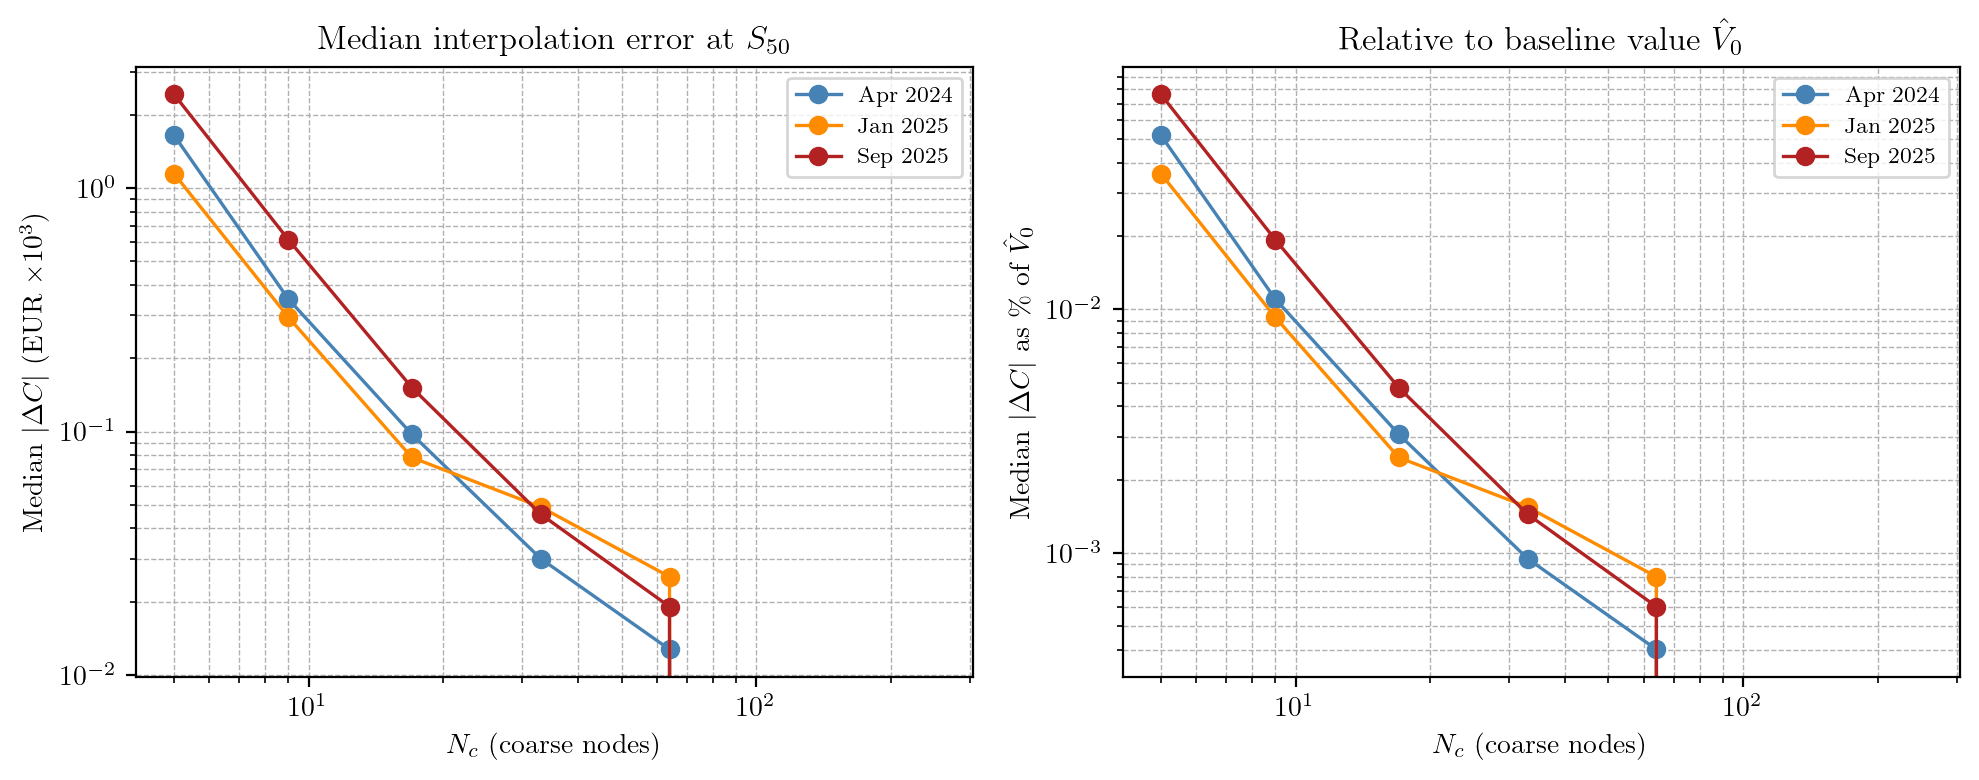

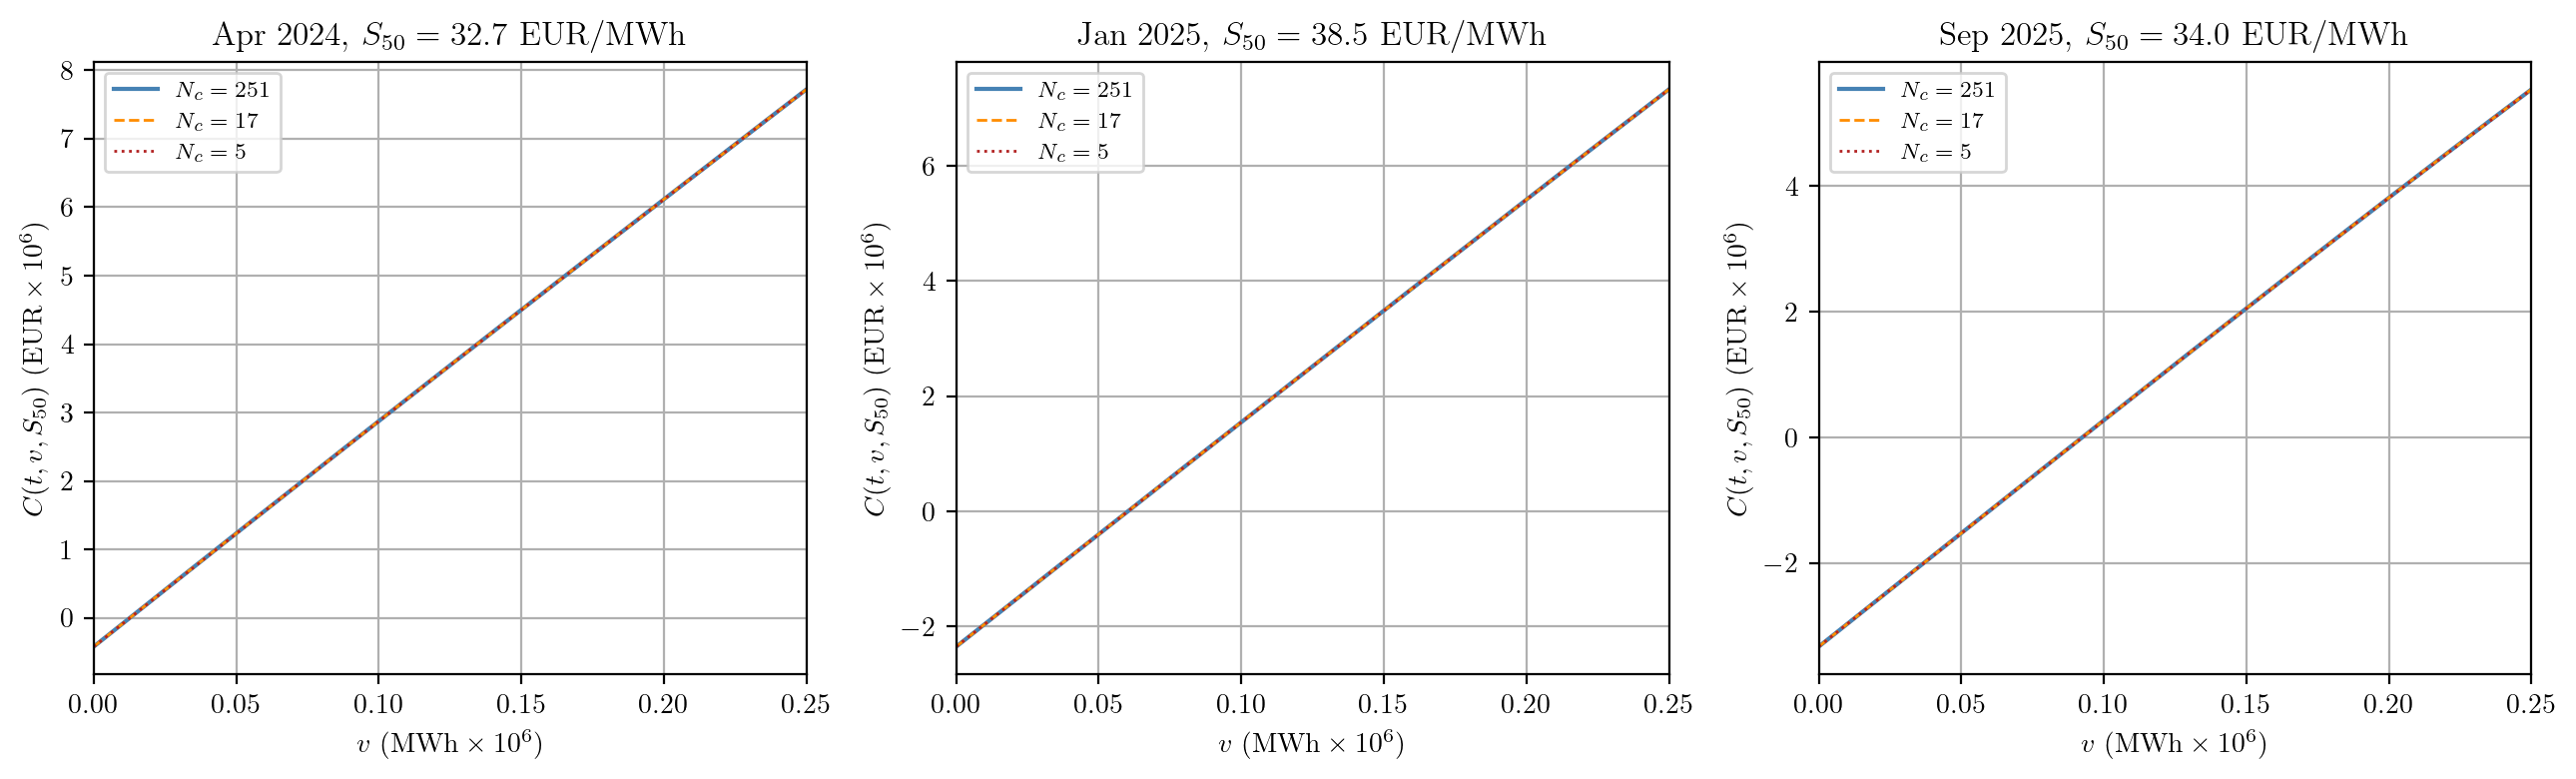


    Nc     alpha_c    Apr 2024 median err (EUR)  Jan 2025 median err (EUR)  Sep 2025 median err (EUR)
   251       1,000                       0.00                     0.00                     0.00
   126       2,000                       0.00                     0.00                     0.00
    64       3,968                      12.74                    25.33                    19.10
    33       7,812                      30.05                    48.97                    45.74
    17      15,625                      97.46                    78.23                   151.48
     9      31,250                     350.20                   294.94                   613.80
     5      62,500                   1,644.82                 1,144.24                 2,421.19


In [ ]:
# ============================================================
# Visualise C(t, v, S) in the v-dimension  — extended analysis
#
# Since k=1,2,4 lines were indistinguishable, push to much
# coarser grids (k up to 64, alpha_c up to ~640 000) and plot
# median interpolation error vs Nc to find where it starts to matter.
# Median over reachable fine-grid nodes is used instead of max
# to avoid distortion from the vmin boundary kink.
# ============================================================

def t_for_date(d_str):
    target = np.datetime64(d_str)
    idx    = int(np.searchsorted(data["date"].to_numpy(), target))
    return min(idx, B_store.shape[0] - 1)

t_picks  = [t_for_date("2024-04-01"),
            t_for_date("2025-01-01"),
            t_for_date("2025-09-01")]
t_labels = ["Apr 2024", "Jan 2025", "Sep 2025"]

# Subsampling factors to sweep — each k halves Nc approximately
k_sweep = [1, 2, 4, 8, 16, 32, 64]

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

# ---- per-timestep median interpolation error vs Nc ----
Nc_list  = []
err_mat  = np.zeros((len(t_picks), len(k_sweep)))

for ki, k_ in enumerate(k_sweep):
    sub_idx = np.arange(0, Nc, k_)
    if sub_idx[-1] != Nc - 1:
        sub_idx = np.append(sub_idx, Nc - 1)
    Nc_list.append(len(sub_idx))

    for ti, t_idx in enumerate(t_picks):
        S_t   = S_sim[t_idx]
        s_val = float(np.percentile(S_t, 50))
        s2, s3 = s_val ** 2, s_val ** 3
        reach = all_can_reach[t_idx]

        C_base = (B_store[t_idx, 0] + s_val * B_store[t_idx, 1]
                  + s2 * B_store[t_idx, 2] + s3 * B_store[t_idx, 3])

        C_fine_base = np.interp(v_fine, v_coarse, C_base)

        C_sub  = C_base[sub_idx]
        C_fine = np.interp(v_fine, v_coarse[sub_idx], C_sub)
        err_mat[ti, ki] = np.median(np.abs((C_fine - C_fine_base)[reach]))

# ---- Figure 1: median error vs Nc ----
fig1, (ax_err, ax_rel) = plt.subplots(1, 2, figsize=(10, 4.0), dpi=200)

colors_t = ["steelblue", "darkorange", "firebrick"]
for ti, (t_label, color) in enumerate(zip(t_labels, colors_t)):
    ax_err.plot(Nc_list, err_mat[ti] / 1e3,
                marker="o", color=color, lw=1.2, label=t_label)
    ax_rel.plot(Nc_list, 100 * err_mat[ti] / abs(V0_hat),
                marker="o", color=color, lw=1.2, label=t_label)

ax_err.set_xlabel(r"$N_c$ (coarse nodes)")
ax_err.set_ylabel(r"Median $|\Delta C|$ (EUR $\times 10^3$)")
ax_err.set_title(r"Median interpolation error at $S_{50}$")
ax_err.set_xscale("log")
ax_err.set_yscale("log")
ax_err.grid(True, which="both", ls="--", lw=0.5)
ax_err.legend(fontsize=8)

ax_rel.set_xlabel(r"$N_c$ (coarse nodes)")
ax_rel.set_ylabel(r"Median $|\Delta C|$ as \% of $\hat{V}_0$")
ax_rel.set_title(r"Relative to baseline value $\hat{V}_0$")
ax_rel.set_xscale("log")
ax_rel.set_yscale("log")
ax_rel.grid(True, which="both", ls="--", lw=0.5)
ax_rel.legend(fontsize=8)

fig1.tight_layout()
plt.savefig("../../fig/Plots/OLS_convergence_interpolation_error.png")
plt.show()

# ---- Figure 2: C(v) curves for the three most extreme k values ----
k_plot   = [1, 16, 64]
lw_plot  = [1.5, 1.0, 1.0]
ls_plot  = ["-", "--", ":"]
col_plot = ["steelblue", "darkorange", "firebrick"]

fig2, axes = plt.subplots(1, 3, figsize=(13, 4.0), dpi=200)

for ax, t_idx, t_label in zip(axes, t_picks, t_labels):
    S_t   = S_sim[t_idx]
    reach = all_can_reach[t_idx]
    s_val = float(np.percentile(S_t, 50))
    s2, s3 = s_val ** 2, s_val ** 3

    C_base = (B_store[t_idx, 0] + s_val * B_store[t_idx, 1]
              + s2 * B_store[t_idx, 2] + s3 * B_store[t_idx, 3])

    for k_, lw, ls, color in zip(k_plot, lw_plot, ls_plot, col_plot):
        sub_idx = np.arange(0, Nc, k_)
        if sub_idx[-1] != Nc - 1:
            sub_idx = np.append(sub_idx, Nc - 1)
        Nc_sub = len(sub_idx)
        C_fine = np.interp(v_fine, v_coarse[sub_idx], C_base[sub_idx])
        C_plot = np.where(reach, C_fine, np.nan)
        ax.plot(v_fine / 1e6, C_plot / 1e6,
                color=color, lw=lw, ls=ls, label=fr"$N_c={Nc_sub}$")

    if reach.any():
        ax.set_xlim(v_fine[reach][0] / 1e6, v_fine[reach][-1] / 1e6)

    ax.set_xlabel(r"$v$ ($\mathrm{MWh} \times 10^6$)")
    ax.set_ylabel(r"$C(t, v, S_{50})$ ($\mathrm{EUR} \times 10^6$)")
    ax.set_title(fr"{t_label},  $S_{{50}}={s_val:.1f}$ EUR/MWh")
    ax.grid(True)
    ax.legend(fontsize=8)

fig2.tight_layout()
plt.savefig("../../fig/Plots/OLS_convergence_C_curves.png")
plt.show()

# ---- summary table ----
print(f"\n{'Nc':>6}  {'alpha_c':>10}  ", end="")
for t_label in t_labels:
    print(f"  {t_label} median err (EUR)", end="")
print()
for ki, (k_, Nc_sub) in enumerate(zip(k_sweep, Nc_list)):
    alpha_c_equiv = (VMAX_GLOBAL - VMIN_GLOBAL) / (Nc_sub - 1) if Nc_sub > 1 else np.inf
    print(f"{Nc_sub:>6}  {alpha_c_equiv:>10,.0f}  ", end="")
    for ti in range(len(t_picks)):
        print(f"  {err_mat[ti, ki]:>23,.2f}", end="")
    print()


In [25]:
# ============================================================
# Fine-grid convergence study: keep alpha_c = 10000 fixed and
# vary refine_factor so only the fine grid is made finer.
# Also reproduce the extended C(t, v, S) diagnostics for this sweep.
# ============================================================
import time

_backup_names = [
    "alpha_c", "refine_factor", "alpha_f", "Nc", "Nf",
    "v_coarse", "v_fine", "coarse_fine_idx", "n0_f", "nT_f",
    "all_next_idx", "all_dv_mat", "all_K_len", "all_dest_ok",
    "all_can_reach", "B_store",
]
_state_present = {name: name in globals() for name in _backup_names}
_state_backup  = {name: globals().get(name) for name in _backup_names}

ALPHA_C_FIXED = 1000.0
refine_factor_candidates = [2, 4, 8, 16, 32, 64]

n_paths = 10000
seed = 123

rng = np.random.default_rng(seed)
n_half = int(np.ceil(n_paths / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths]

S_sim = simulate_from_Z(Z, n_paths=n_paths, Tn=Tn, t_arr=t_arr,
                        kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

B_store = lsmc_value_and_B_store_given_S(S_sim)[1]

fine_conv_results = []
B_store_by_rf = {}
all_can_reach_by_rf = {}
v_fine_by_rf = {}
alpha_f_by_rf = {}
Nf_by_rf = {}

for _rf in refine_factor_candidates:
    alpha_c = float(ALPHA_C_FIXED)
    refine_factor = int(_rf)
    alpha_f = alpha_c / refine_factor
    Nc = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
    Nf = (Nc - 1) * refine_factor + 1
    v_coarse = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
    v_fine = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
    coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
    assert coarse_fine_idx[-1] == Nf - 1

    n0_f = int(round((vT_target - VMIN_CONST) / alpha_f))
    nT_f = int(round((vT_target - VMIN_CONST) / alpha_f))

    print(f"\nrefine_factor={refine_factor:>4d}  alpha_f={alpha_f:>8,.2f}  Nc={Nc:>4d}  Nf={Nf:>5d}")
    print("  Pre-computing feasible action sets...", end=" ", flush=True)
    t_fa = time.perf_counter()

    all_next_idx = []
    all_dv_mat = []
    all_K_len = []
    all_dest_ok = []
    for t_idx in range(Tn):
        ni, dv, kl = build_feasible_actions_at_t(t_idx)
        all_next_idx.append(ni)
        all_dv_mat.append(dv)
        all_K_len.append(kl)
        t_next = min(t_idx + 1, len(vmax_arr) - 1)
        all_dest_ok.append(
            (v_fine >= vmin_arr[t_next] - 1e-6) &
            (v_fine <= vmax_arr[t_next] + 1e-6)
        )

    all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
    all_can_reach[T][nT_f] = True
    for t_idx in range(T - 1, -1, -1):
        can_reach_next = all_can_reach[t_idx + 1]
        can_reach_now = all_can_reach[t_idx]
        ni_t = all_next_idx[t_idx]
        kl_t = all_K_len[t_idx]
        for n_f in range(Nf):
            klen = kl_t[n_f]
            if klen == 0:
                continue
            can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])

    print(f"done ({time.perf_counter() - t_fa:.1f}s)")

    t0 = time.perf_counter()
    V0_hat_rf = lsmc_value_given_S(S_sim)
    elapsed = time.perf_counter() - t0

    fine_conv_results.append({
        "refine_factor": refine_factor,
        "alpha_c": int(alpha_c),
        "alpha_f": alpha_f,
        "Nc": Nc,
        "Nf": Nf,
        "V0_hat": V0_hat_rf,
        "time_s": elapsed,
    })
    B_store_by_rf[refine_factor] = B_store.copy()
    all_can_reach_by_rf[refine_factor] = [arr.copy() for arr in all_can_reach]
    v_fine_by_rf[refine_factor] = v_fine.copy()
    alpha_f_by_rf[refine_factor] = alpha_f
    Nf_by_rf[refine_factor] = Nf
    print(f"  V0_hat = {V0_hat_rf:>14,.2f} EUR   ({elapsed:.1f}s)")

df_fine = pd.DataFrame(fine_conv_results)
print("\n--- Fine-grid convergence summary ---")
print(df_fine.to_string(index=False))

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

baseline_rf = int(df_fine["refine_factor"].max())
baseline_V0_fine = float(df_fine.loc[df_fine["refine_factor"] == baseline_rf, "V0_hat"].iloc[0])
df_fine["rel_error_pct"] = 100.0 * (df_fine["V0_hat"] - baseline_V0_fine) / abs(baseline_V0_fine)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), dpi=200)

axes[0].plot(df_fine["refine_factor"], df_fine["V0_hat"] / 1e6,
             marker="o", color="steelblue", lw=1.2)
axes[0].set_xlabel("refine factor")
axes[0].set_ylabel(r"$\hat{V}_0$ (EUR, millions)")
axes[0].set_title(r"Value vs. fine-grid refinement")
axes[0].grid(True)

axes[1].plot(df_fine["refine_factor"], df_fine["rel_error_pct"],
             marker="o", color="firebrick", lw=1.2)
axes[1].axhline(0, ls="--", lw=0.8, color="black")
axes[1].set_xlabel("refine factor")
axes[1].set_ylabel(r"Relative error (\%)")
axes[1].set_title(fr"Error relative to refine factor = {baseline_rf}")
axes[1].grid(True)

axes[2].plot(df_fine["refine_factor"], df_fine["time_s"],
             marker="o", color="darkorange", lw=1.2)
axes[2].set_xlabel("refine factor")
axes[2].set_ylabel("Running time (s)")
axes[2].set_title("Runtime vs. fine-grid refinement")
axes[2].grid(True)

fig.tight_layout()
plt.savefig("../../fig/Plots/OLS_fine_grid_convergence.png")
plt.show()

# ---- extended C(t, v, S) analysis for the refine-factor sweep ----
_t_picks = [t_for_date("2024-04-01"),
            t_for_date("2025-01-01"),
            t_for_date("2025-09-01")]
_t_labels = ["Apr 2024", "Jan 2025", "Sep 2025"]

v_coarse_fixed = VMIN_GLOBAL + ALPHA_C_FIXED * np.arange(Nc, dtype=np.float64)
err_mat_fine = np.zeros((len(_t_picks), len(refine_factor_candidates)))
B_ref = B_store_by_rf[baseline_rf]

for ri, rf_ in enumerate(refine_factor_candidates):
    B_rf = B_store_by_rf[rf_]
    v_fine_rf = v_fine_by_rf[rf_]
    reach_rf_all = all_can_reach_by_rf[rf_]

    for ti, t_idx in enumerate(_t_picks):
        s_val = float(np.percentile(S_sim[t_idx], 50))
        s2, s3 = s_val ** 2, s_val ** 3

        C_ref_coarse = (B_ref[t_idx, 0] + s_val * B_ref[t_idx, 1]
                        + s2 * B_ref[t_idx, 2] + s3 * B_ref[t_idx, 3])
        C_rf_coarse = (B_rf[t_idx, 0] + s_val * B_rf[t_idx, 1]
                       + s2 * B_rf[t_idx, 2] + s3 * B_rf[t_idx, 3])

        C_ref_fine = np.interp(v_fine_rf, v_coarse_fixed, C_ref_coarse)
        C_rf_fine = np.interp(v_fine_rf, v_coarse_fixed, C_rf_coarse)
        reach_rf = reach_rf_all[t_idx]
        err_mat_fine[ti, ri] = np.median(np.abs((C_rf_fine - C_ref_fine)[reach_rf]))

fig1, (ax_err, ax_rel) = plt.subplots(1, 2, figsize=(10, 4.0), dpi=200)

colors_t = ["steelblue", "darkorange", "firebrick"]
for ti, (t_label, color) in enumerate(zip(_t_labels, colors_t)):
    ax_err.plot(refine_factor_candidates, err_mat_fine[ti] / 1e3,
                marker="o", color=color, lw=1.2, label=t_label)
    ax_rel.plot(refine_factor_candidates, 100 * err_mat_fine[ti] / abs(baseline_V0_fine),
                marker="o", color=color, lw=1.2, label=t_label)

ax_err.set_xlabel("refine factor")
ax_err.set_ylabel(r"Median $|\Delta C|$ (EUR $\times 10^3$)")
ax_err.set_title(r"Median $C$-error vs. fine-grid refinement")
ax_err.set_xscale("log", base=2)
ax_err.set_yscale("log")
ax_err.grid(True, which="both", ls="--", lw=0.5)
ax_err.legend(fontsize=8)

ax_rel.set_xlabel("refine factor")
ax_rel.set_ylabel(r"Median $|\Delta C|$ as \% of $\hat{V}_0$")
ax_rel.set_title(fr"Relative to refine factor = {baseline_rf}")
ax_rel.set_xscale("log", base=2)
ax_rel.set_yscale("log")
ax_rel.grid(True, which="both", ls="--", lw=0.5)
ax_rel.legend(fontsize=8)

fig1.tight_layout()
plt.savefig("../../fig/Plots/OLS_fine_grid_interpolation_error.png")
plt.show()

rf_plot = [rf for rf in [4, 16, 64] if rf in refine_factor_candidates]
lw_plot = [1.5, 1.0, 1.0][:len(rf_plot)]
ls_map = {4: "-", 16: "--", 64: ":"}
col_map = {4: "steelblue", 16: "darkorange", 64: "firebrick"}

fig2, axes = plt.subplots(1, 3, figsize=(13, 4.0), dpi=200)

for ax, t_idx, t_label in zip(axes, _t_picks, _t_labels):
    s_val = float(np.percentile(S_sim[t_idx], 50))
    s2, s3 = s_val ** 2, s_val ** 3

    for rf_, lw in zip(rf_plot, lw_plot):
        B_rf = B_store_by_rf[rf_]
        v_fine_rf = v_fine_by_rf[rf_]
        reach_rf = all_can_reach_by_rf[rf_][t_idx]
        C_rf_coarse = (B_rf[t_idx, 0] + s_val * B_rf[t_idx, 1]
                       + s2 * B_rf[t_idx, 2] + s3 * B_rf[t_idx, 3])
        C_rf_fine = np.interp(v_fine_rf, v_coarse_fixed, C_rf_coarse)
        C_plot = np.where(reach_rf, C_rf_fine, np.nan)
        ax.plot(v_fine_rf / 1e6, C_plot / 1e6,
                color=col_map[rf_], lw=lw, ls=ls_map[rf_],
                label=fr"$r={rf_},\;N_f={Nf_by_rf[rf_]}$")

    reach_ref = all_can_reach_by_rf[baseline_rf][t_idx]
    v_ref = v_fine_by_rf[baseline_rf]
    if reach_ref.any():
        ax.set_xlim(v_ref[reach_ref][0] / 1e6, v_ref[reach_ref][-1] / 1e6)

    ax.set_xlabel(r"$v$ ($\mathrm{MWh} \times 10^6$)")
    ax.set_ylabel(r"$C(t, v, S_{50})$ ($\mathrm{EUR} \times 10^6$)")
    ax.set_title(fr"{t_label},  $S_{{50}}={s_val:.1f}$ EUR/MWh")
    ax.grid(True)
    ax.legend(fontsize=8)

fig2.tight_layout()
plt.savefig("../../fig/Plots/OLS_fine_grid_C_curves.png")
plt.show()

print(f"\n{'refine_factor':>13}  {'alpha_f':>10}  {'Nf':>6}  ", end="")
for t_label in _t_labels:
    print(f"  {t_label} median err (EUR)", end="")
print()
for ri, rf_ in enumerate(refine_factor_candidates):
    print(f"{rf_:>13d}  {alpha_f_by_rf[rf_]:>10,.2f}  {Nf_by_rf[rf_]:>6d}  ", end="")
    for ti in range(len(_t_picks)):
        print(f"  {err_mat_fine[ti, ri]:>23,.2f}", end="")
    print()

for name in _backup_names:
    if _state_present[name]:
        globals()[name] = _state_backup[name]
    elif name in globals():
        del globals()[name]



refine_factor=   2  alpha_f=  500.00  Nc= 251  Nf=  501
  Pre-computing feasible action sets... done (2.3s)
  V0_hat =   3,338,674.82 EUR   (40.0s)

refine_factor=   4  alpha_f=  250.00  Nc= 251  Nf= 1001
  Pre-computing feasible action sets... done (4.6s)
  V0_hat =   3,338,674.82 EUR   (58.8s)

refine_factor=   8  alpha_f=  125.00  Nc= 251  Nf= 2001
  Pre-computing feasible action sets... done (9.4s)


KeyboardInterrupt: 

Testing basis degrees: 100%|██████████| 6/6 [06:08<00:00, 61.46s/it]


,basis_degree,n_terms,V0_hat,mean_pathwise,std_pathwise,skewness,excess_kurtosis,shapiro_p,jb_p,sw_reject_5pct,jb_reject_5pct,fat_tails,asymmetric
0,1,2,3251624.03,3253130.94,1267739.26,-0.0927,-0.0801,0.003854,0.000201,True,True,False,False
1,2,3,3299454.00,3299516.93,1357027.41,-0.0335,-0.1293,0.057966,0.011751,False,True,False,False
2,3,4,3321481.85,3321211.63,1361902.04,-0.0272,-0.1366,0.023725,0.010747,True,True,False,False
3,4,5,3329565.46,3328982.29,1368711.82,-0.0312,-0.1322,0.374919,0.011338,False,True,False,False
4,5,6,3336109.76,3336459.42,1375514.03,-0.0158,-0.1331,0.062306,0.019672,False,True,False,False
5,6,7,3339177.31,3338976.83,1378346.14,-0.0118,-0.1310,0.023423,0.024245,True,True,False,False


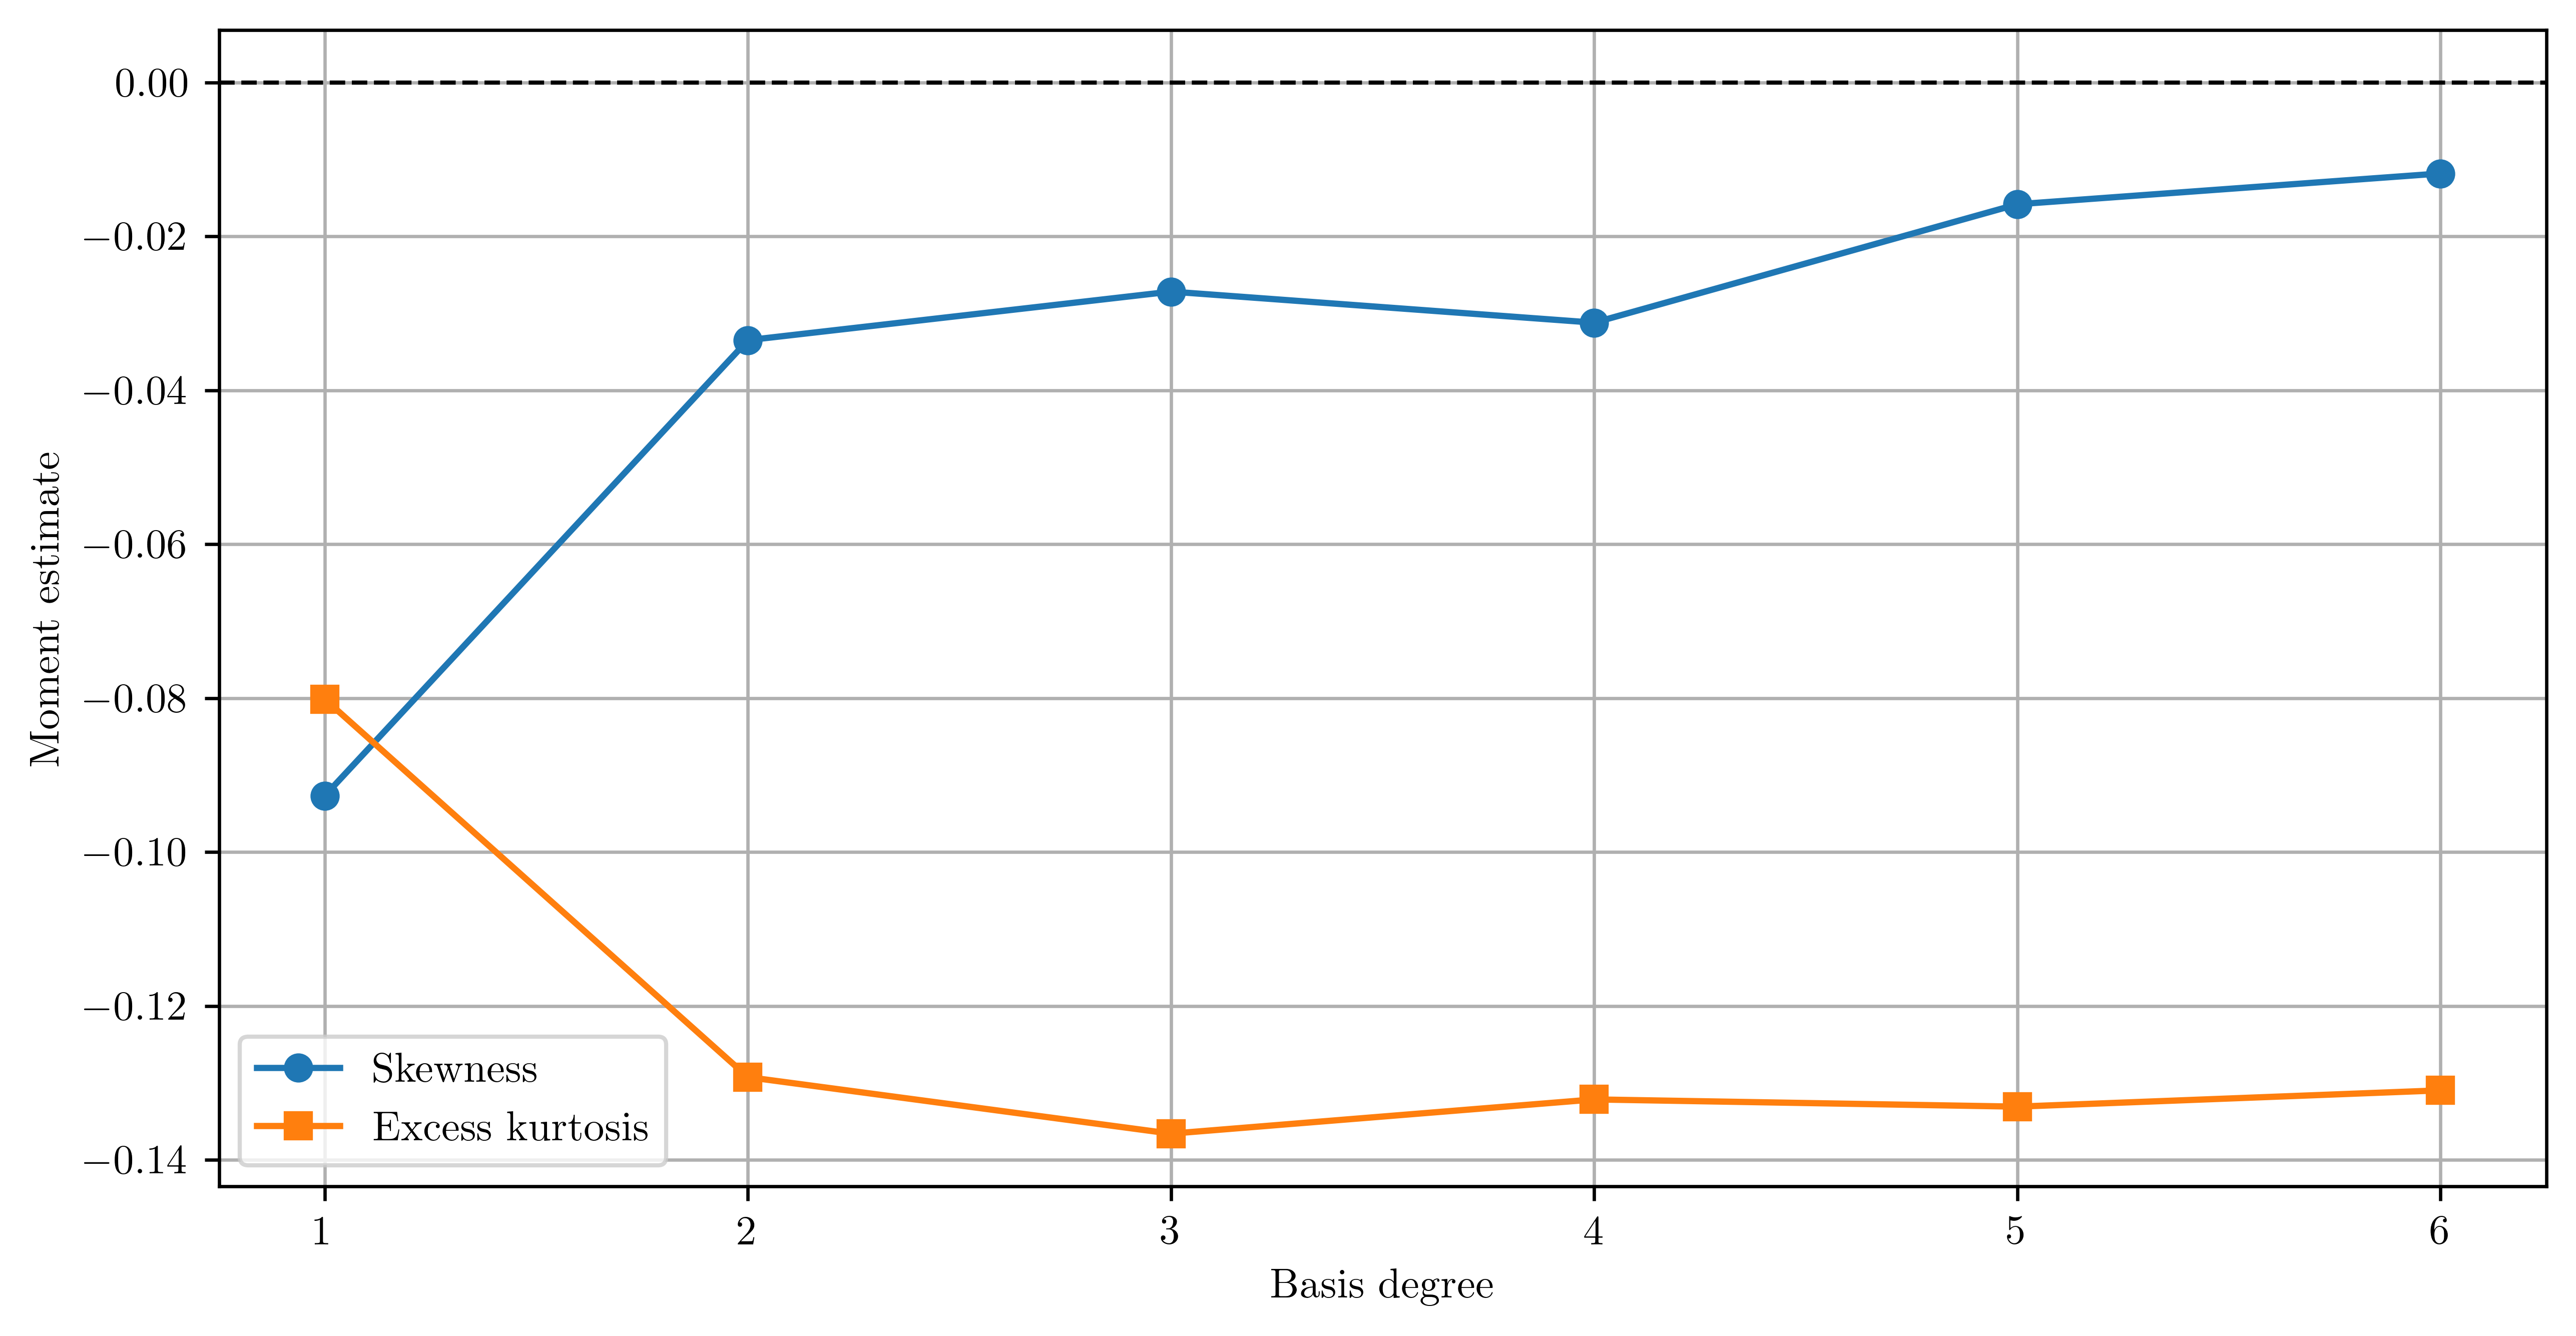

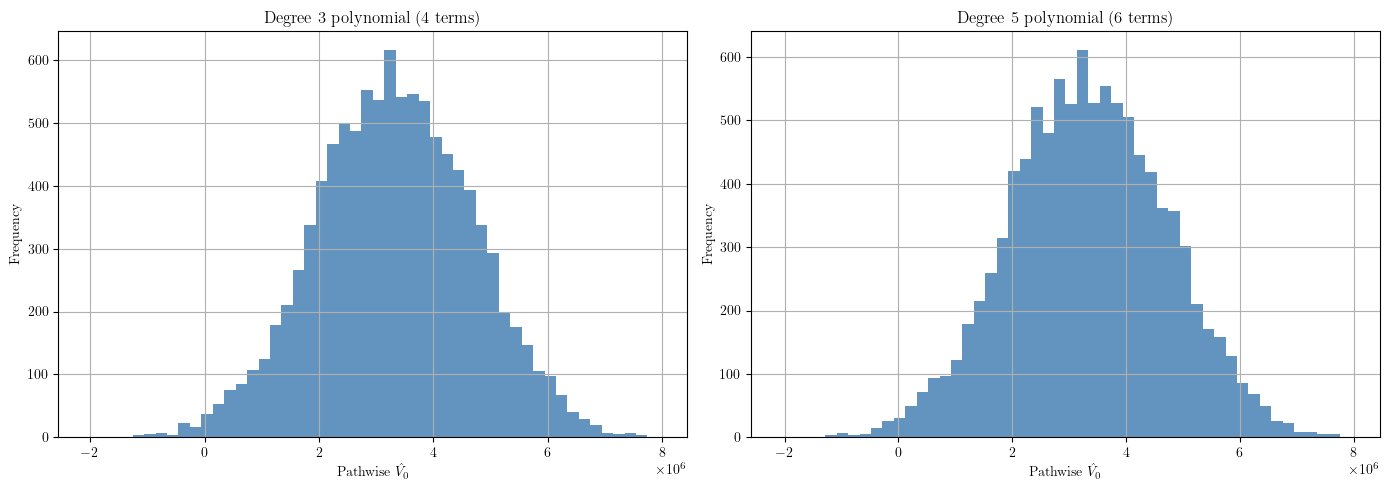

Interpretation guide:
- Positive excess kurtosis indicates fat tails relative to a normal distribution.
- Large absolute skewness indicates asymmetry.
- Kircher's claim is supported if these features become stronger once basis degree > 4.


In [4]:
# Test Kircher's point with a generalized polynomial basis.
# This cell is self-contained because the notebook's original LSMC routine is
# hardcoded for a cubic regression basis.
from scipy import stats

def poly_features(s, degree):
    return np.vander(s, N=degree + 1, increasing=True)

def lsmc_value_and_paths_given_S_generalized(S: np.ndarray, degree: int):
    T = S.shape[0] - 1
    M = S.shape[1]
    p_dim = degree + 1

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    tv = terminal_value(v_fine)
    Y_next = np.tile(tv, (M, 1))
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current = np.empty((M, Nf), dtype=np.float64)
    pi_dtype = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T, M), dtype=pi_dtype)
    n_curr = np.full(M, nT_f, dtype=np.int32)
    B_store = np.zeros((T, p_dim, Nc), dtype=np.float64)

    for t in range(T - 1, -1, -1):
        S_t = S[t].astype(np.float64, copy=False)
        X = poly_features(S_t, degree)

        reach_next = all_can_reach[t + 1]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]
        B = np.zeros((p_dim, Nc), dtype=np.float64)

        for j in range(Nc):
            coarse_idx = coarse_fine_idx[j]
            if not reach_next[coarse_idx]:
                continue

            col = Y_disc[:, j]
            mask = np.isfinite(col)
            if mask.sum() < p_dim:
                continue

            Xm = X[mask]
            XtX = Xm.T @ Xm
            XtY = Xm.T @ col[mask]
            try:
                B[:, j] = np.linalg.solve(XtX, XtY)
            except np.linalg.LinAlgError:
                B[:, j] = np.linalg.lstsq(Xm, col[mask], rcond=None)[0]

        B_store[t] = B

        C_hat_coarse = X @ B
        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse, coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        bellman_update_numba(
            Y_current, Y_next, pi_next_idx[t], n_curr, S_t,
            C_hat_fine_buf, all_next_idx[t], all_dv_mat[t], all_K_len[t],
            disc_arr[t], terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    V0_hat = float(np.mean(Y_next[:, n0_f]))

    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    n_path_idx[0] = n0_f

    for t in range(T):
        S_t = S[t].astype(np.float64, copy=False)
        X = poly_features(S_t, degree)
        C_hat_coarse = X @ B_store[t]
        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse, coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, all_can_reach[t + 1], terminal_penalty)

        for i in range(M):
            n = n_path_idx[t, i]
            s = S_t[i]
            best_val = -np.inf
            best_next = n

            for k in range(all_K_len[t][n]):
                nxt = all_next_idx[t][n, k]
                if nxt < 0 or not all_can_reach[t + 1][nxt]:
                    continue

                cand = (-s * all_dv_mat[t][n, k]) + disc_arr[t] * C_hat_fine_buf[i, nxt]
                if cand > best_val:
                    best_val = cand
                    best_next = nxt

            n_path_idx[t + 1, i] = best_next

    v_path = v_fine[n_path_idx]
    return V0_hat, v_path, B_store

basis_degree_grid = [1, 2, 3, 4, 5, 6]
results = []
pathwise_by_degree = {}
rng_norm = np.random.default_rng(123)

for deg in tqdm(basis_degree_grid, desc="Testing basis degrees"):
    V0_hat_deg, v_path_deg, _ = lsmc_value_and_paths_given_S_generalized(S_sim, degree=deg)

    dv_path_deg = np.diff(v_path_deg, axis=0)
    cashflow_deg = -S_sim[:-1] * dv_path_deg
    V0_hat_pathwise_deg = np.sum(disc_to_0[:, None] * cashflow_deg, axis=0)
    x = np.asarray(V0_hat_pathwise_deg, dtype=float)
    x = x[np.isfinite(x)]

    shapiro_sample = x if x.size <= 5000 else rng_norm.choice(x, size=5000, replace=False)
    _, shapiro_p = stats.shapiro(shapiro_sample)
    jb_result = stats.jarque_bera(x)
    skew_x = stats.skew(x, bias=False)
    excess_kurt_x = stats.kurtosis(x, fisher=True, bias=False)

    results.append({
        "basis_degree": deg,
        "n_terms": deg + 1,
        "V0_hat": V0_hat_deg,
        "mean_pathwise": x.mean(),
        "std_pathwise": x.std(ddof=1),
        "skewness": skew_x,
        "excess_kurtosis": excess_kurt_x,
        "shapiro_p": shapiro_p,
        "jb_p": jb_result.pvalue,
    })
    pathwise_by_degree[deg] = x

results_df = pd.DataFrame(results)
results_df["sw_reject_5pct"] = results_df["shapiro_p"] < 0.05
results_df["jb_reject_5pct"] = results_df["jb_p"] < 0.05
results_df["fat_tails"] = results_df["excess_kurtosis"] > 0
results_df["asymmetric"] = results_df["skewness"].abs() > 0.1

display(results_df.round({
    "V0_hat": 2,
    "mean_pathwise": 2,
    "std_pathwise": 2,
    "skewness": 4,
    "excess_kurtosis": 4,
    "shapiro_p": 6,
    "jb_p": 6,
}))

plt.figure(figsize=(10, 5), dpi=600)
plt.plot(results_df["basis_degree"], results_df["skewness"], marker="o", label="Skewness")
plt.plot(results_df["basis_degree"], results_df["excess_kurtosis"], marker="s", label="Excess kurtosis")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Basis degree")
plt.ylabel("Moment estimate")
plt.grid(True)
plt.legend()
plt.savefig("../../fig/Plots/OLS_pathwise_moments_by_degree.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, deg in zip(axes, [3, 5]):
    ax.hist(pathwise_by_degree[deg], bins=50, alpha=0.85, color="steelblue")
    ax.set_title(f"Degree {deg} polynomial ({deg + 1} terms)")
    ax.set_xlabel(r"Pathwise $\hat{V}_0$")
    ax.set_ylabel("Frequency")
    ax.grid(True)
plt.tight_layout()
plt.show()

print("Interpretation guide:")
print("- Positive excess kurtosis indicates fat tails relative to a normal distribution.")
print("- Large absolute skewness indicates asymmetry.")
print("- Kircher's claim is supported if these features become stronger once basis degree > 4.")


,parameter,estimated value,baseline $\\hat{V}_0$
0,$\\kappa$,0.008425,3172934.54
1,$\\sigma$,0.023462,3172934.54


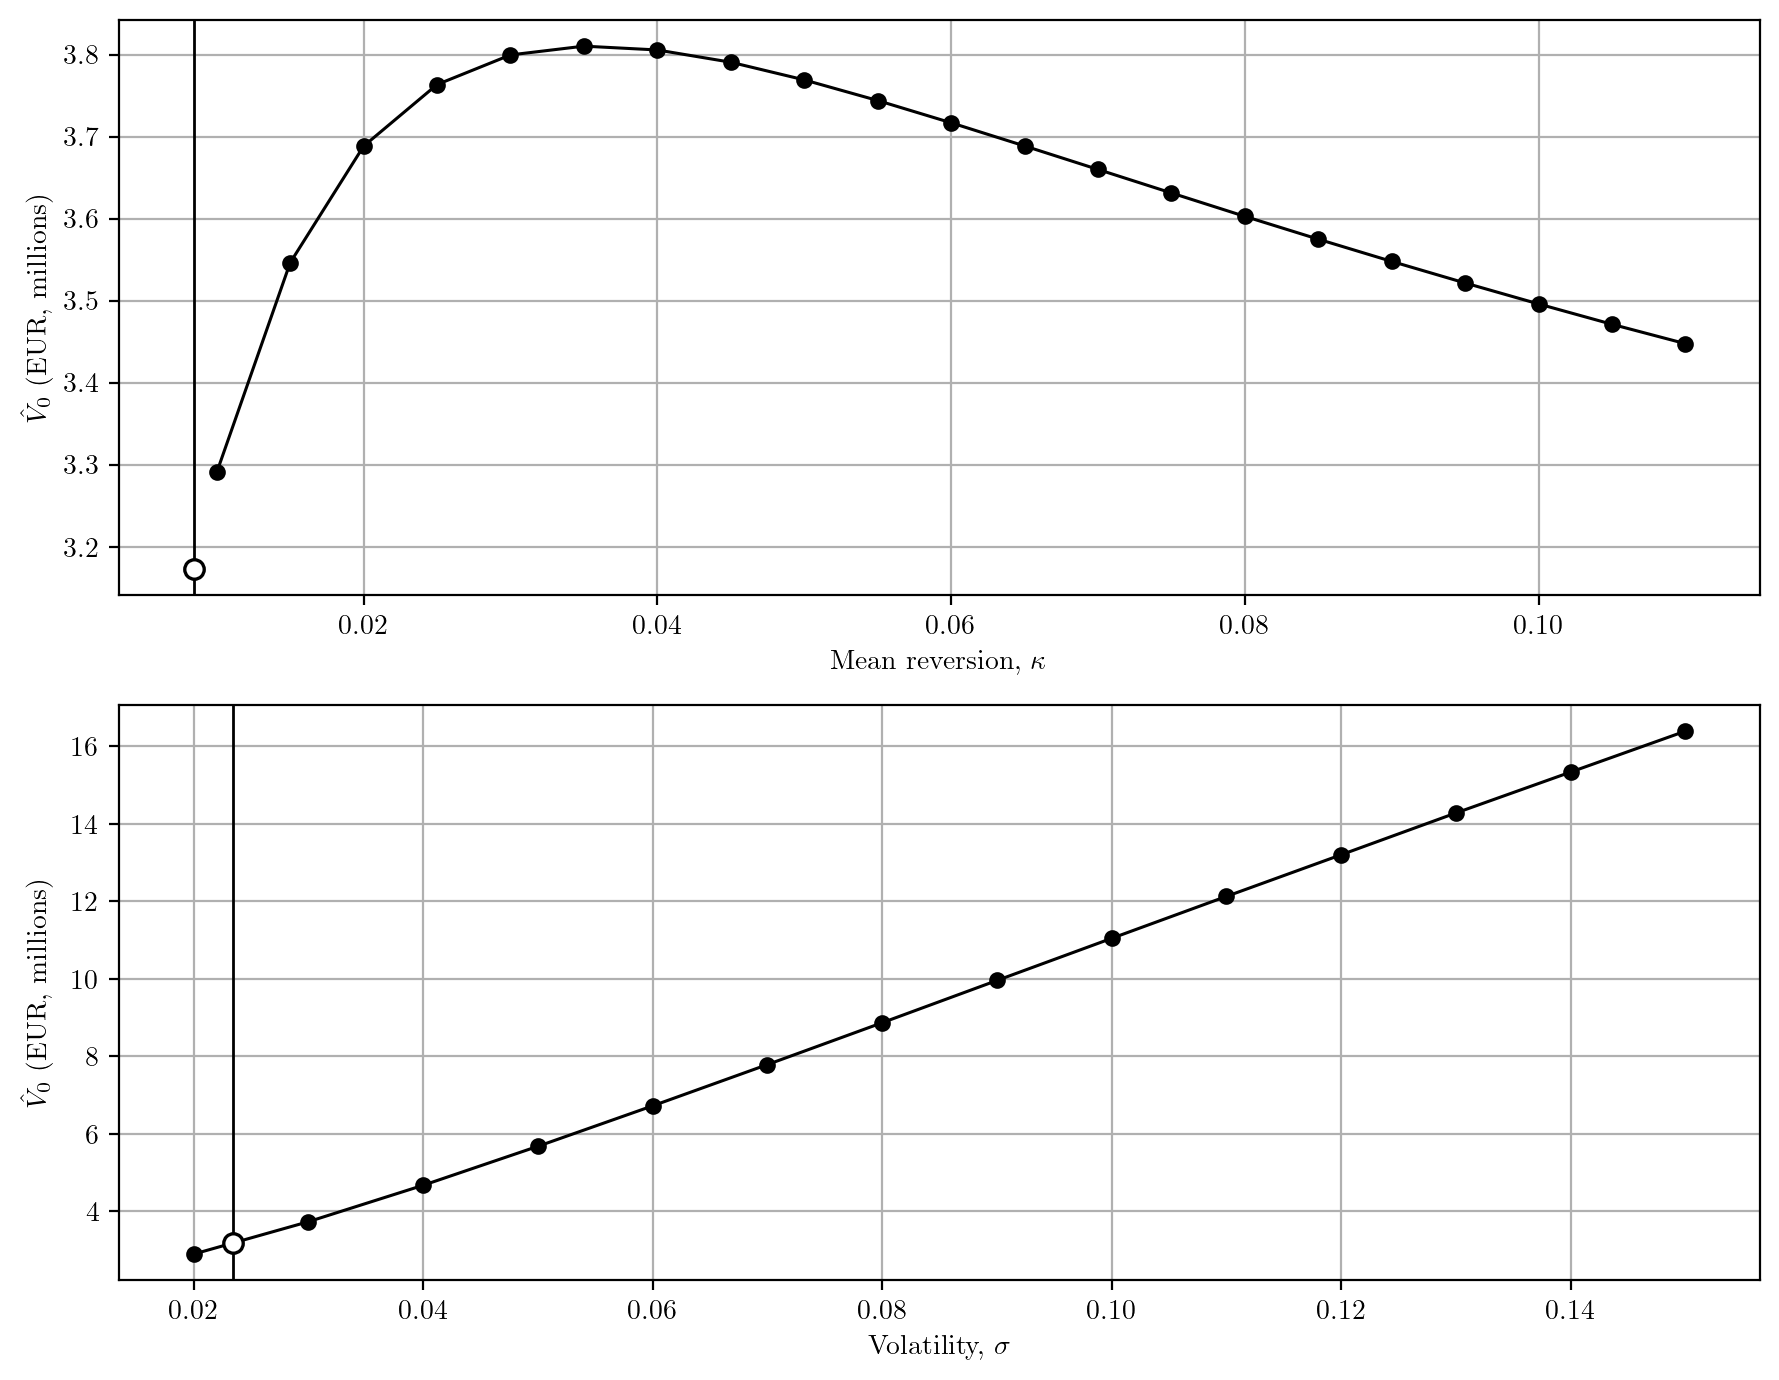

Estimated kappa_hat = 0.008425
Estimated sigma_hat = 0.023462
Baseline value       = 3,172,934.54 EUR
Sweep mode           = joblib loky, n_jobs=4


In [ ]:
# Sensitivity of the OLS-LSMC value to mean reversion and volatility.
# Standalone setup: vary one parameter at a time around the estimated baseline.

kappa_grid = np.arange(0.01, 0.115, 0.005)
sigma_grid = np.arange(0.02, 0.155, 0.01)

import os

n_paths_sens = 10_000
seed_sens = 123
save_path = "../../fig/Plots/OLS_value_vs_kappa_sigma.png"
n_jobs_sens = min(4, os.cpu_count() or 1)

def build_m_col_from_params(kappa_val: float, sigma_val: float):
    var_x = (sigma_val**2 / (2.0 * kappa_val)) * (1.0 - np.exp(-2.0 * kappa_val * t_arr))
    m_local = np.log(data["F0t"].to_numpy(dtype=np.float64)) - 0.5 * var_x
    return m_local[:, None]

def value_for_kappa(kappa_val: float):
    nb.set_num_threads(1)
    m_col_local = build_m_col_from_params(kappa_val, sigma_hat)
    S_local = simulate_from_Z(
        Z_sens,
        n_paths=n_paths_sens,
        Tn=Tn,
        t_arr=t_arr,
        kappa_hat=kappa_val,
        sigma_hat=sigma_hat,
        m_col=m_col_local,
    )
    return {
        "kappa": kappa_val,
        "V0_hat": lsmc_value_given_S(S_local),
    }

def value_for_sigma(sigma_val: float):
    nb.set_num_threads(1)
    m_col_local = build_m_col_from_params(kappa_hat, sigma_val)
    S_local = simulate_from_Z(
        Z_sens,
        n_paths=n_paths_sens,
        Tn=Tn,
        t_arr=t_arr,
        kappa_hat=kappa_hat,
        sigma_hat=sigma_val,
        m_col=m_col_local,
    )
    return {
        "sigma": sigma_val,
        "V0_hat": lsmc_value_given_S(S_local),
    }

rng_sens = np.random.default_rng(seed_sens)
n_half_sens = int(np.ceil(n_paths_sens / 2))
Z_half_sens = rng_sens.standard_normal(size=(Tn - 1, n_half_sens))
Z_sens = np.concatenate([Z_half_sens, -Z_half_sens], axis=1)[:, :n_paths_sens]

baseline_m_col = build_m_col_from_params(kappa_hat, sigma_hat)
S_baseline = simulate_from_Z(
    Z_sens,
    n_paths=n_paths_sens,
    Tn=Tn,
    t_arr=t_arr,
    kappa_hat=kappa_hat,
    sigma_hat=sigma_hat,
    m_col=baseline_m_col,
)
baseline_V0 = lsmc_value_given_S(S_baseline)

try:
    from joblib import Parallel, delayed

    kappa_results = Parallel(n_jobs=n_jobs_sens, backend="loky")(
        delayed(value_for_kappa)(kappa_val)
        for kappa_val in tqdm(kappa_grid, desc="Sweeping kappa")
    )
    sigma_results = Parallel(n_jobs=n_jobs_sens, backend="loky")(
        delayed(value_for_sigma)(sigma_val)
        for sigma_val in tqdm(sigma_grid, desc="Sweeping sigma")
    )
    parallel_mode = f"joblib loky, n_jobs={n_jobs_sens}"
except ImportError:
    print("joblib not available; running sweeps sequentially.")
    kappa_results = [value_for_kappa(kappa_val) for kappa_val in tqdm(kappa_grid, desc="Sweeping kappa")]
    sigma_results = [value_for_sigma(sigma_val) for sigma_val in tqdm(sigma_grid, desc="Sweeping sigma")]
    parallel_mode = "sequential fallback"

df_kappa = pd.DataFrame(kappa_results)
df_sigma = pd.DataFrame(sigma_results)

display(pd.DataFrame({
    "parameter": [r"$\\kappa$", r"$\\sigma$"],
    "estimated value": [kappa_hat, sigma_hat],
    r"baseline $\\hat{V}_0$": [baseline_V0, baseline_V0],
}).round({"estimated value": 6, r"baseline $\\hat{V}_0$": 2}))

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fig, axes = plt.subplots(2, 1, figsize=(9, 7), dpi=200, sharey=False)

axes[0].plot(df_kappa["kappa"], df_kappa["V0_hat"] / 1e6,
             marker="o", markersize=5, color="black", lw=1.1)
axes[0].axvline(kappa_hat, color="black", lw=1.0)
axes[0].plot(kappa_hat, baseline_V0 / 1e6,
             marker="o", markersize=7, markerfacecolor="white",
             markeredgecolor="black", markeredgewidth=1.2)
axes[0].set_xlabel(r"Mean reversion, $\kappa$")
axes[0].set_ylabel(r"$\hat{V}_0$ (EUR, millions)")
axes[0].grid(True)

axes[1].plot(df_sigma["sigma"], df_sigma["V0_hat"] / 1e6,
             marker="o", markersize=5, color="black", lw=1.1)
axes[1].axvline(sigma_hat, color="black", lw=1.0)
axes[1].plot(sigma_hat, baseline_V0 / 1e6,
             marker="o", markersize=7, markerfacecolor="white",
             markeredgecolor="black", markeredgewidth=1.2)
axes[1].set_xlabel(r"Volatility, $\sigma$")
axes[1].set_ylabel(r"$\hat{V}_0$ (EUR, millions)")
axes[1].grid(True)

fig.align_ylabels(axes)
fig.tight_layout()
plt.savefig(save_path)
plt.show()

print(f"Estimated kappa_hat = {kappa_hat:.6f}")
print(f"Estimated sigma_hat = {sigma_hat:.6f}")
print(f"Baseline value       = {baseline_V0:,.2f} EUR")
print(f"Sweep mode           = {parallel_mode}")


Sweeping max volume: 100%|██████████| 8/8 [02:20<00:00, 17.62s/it]


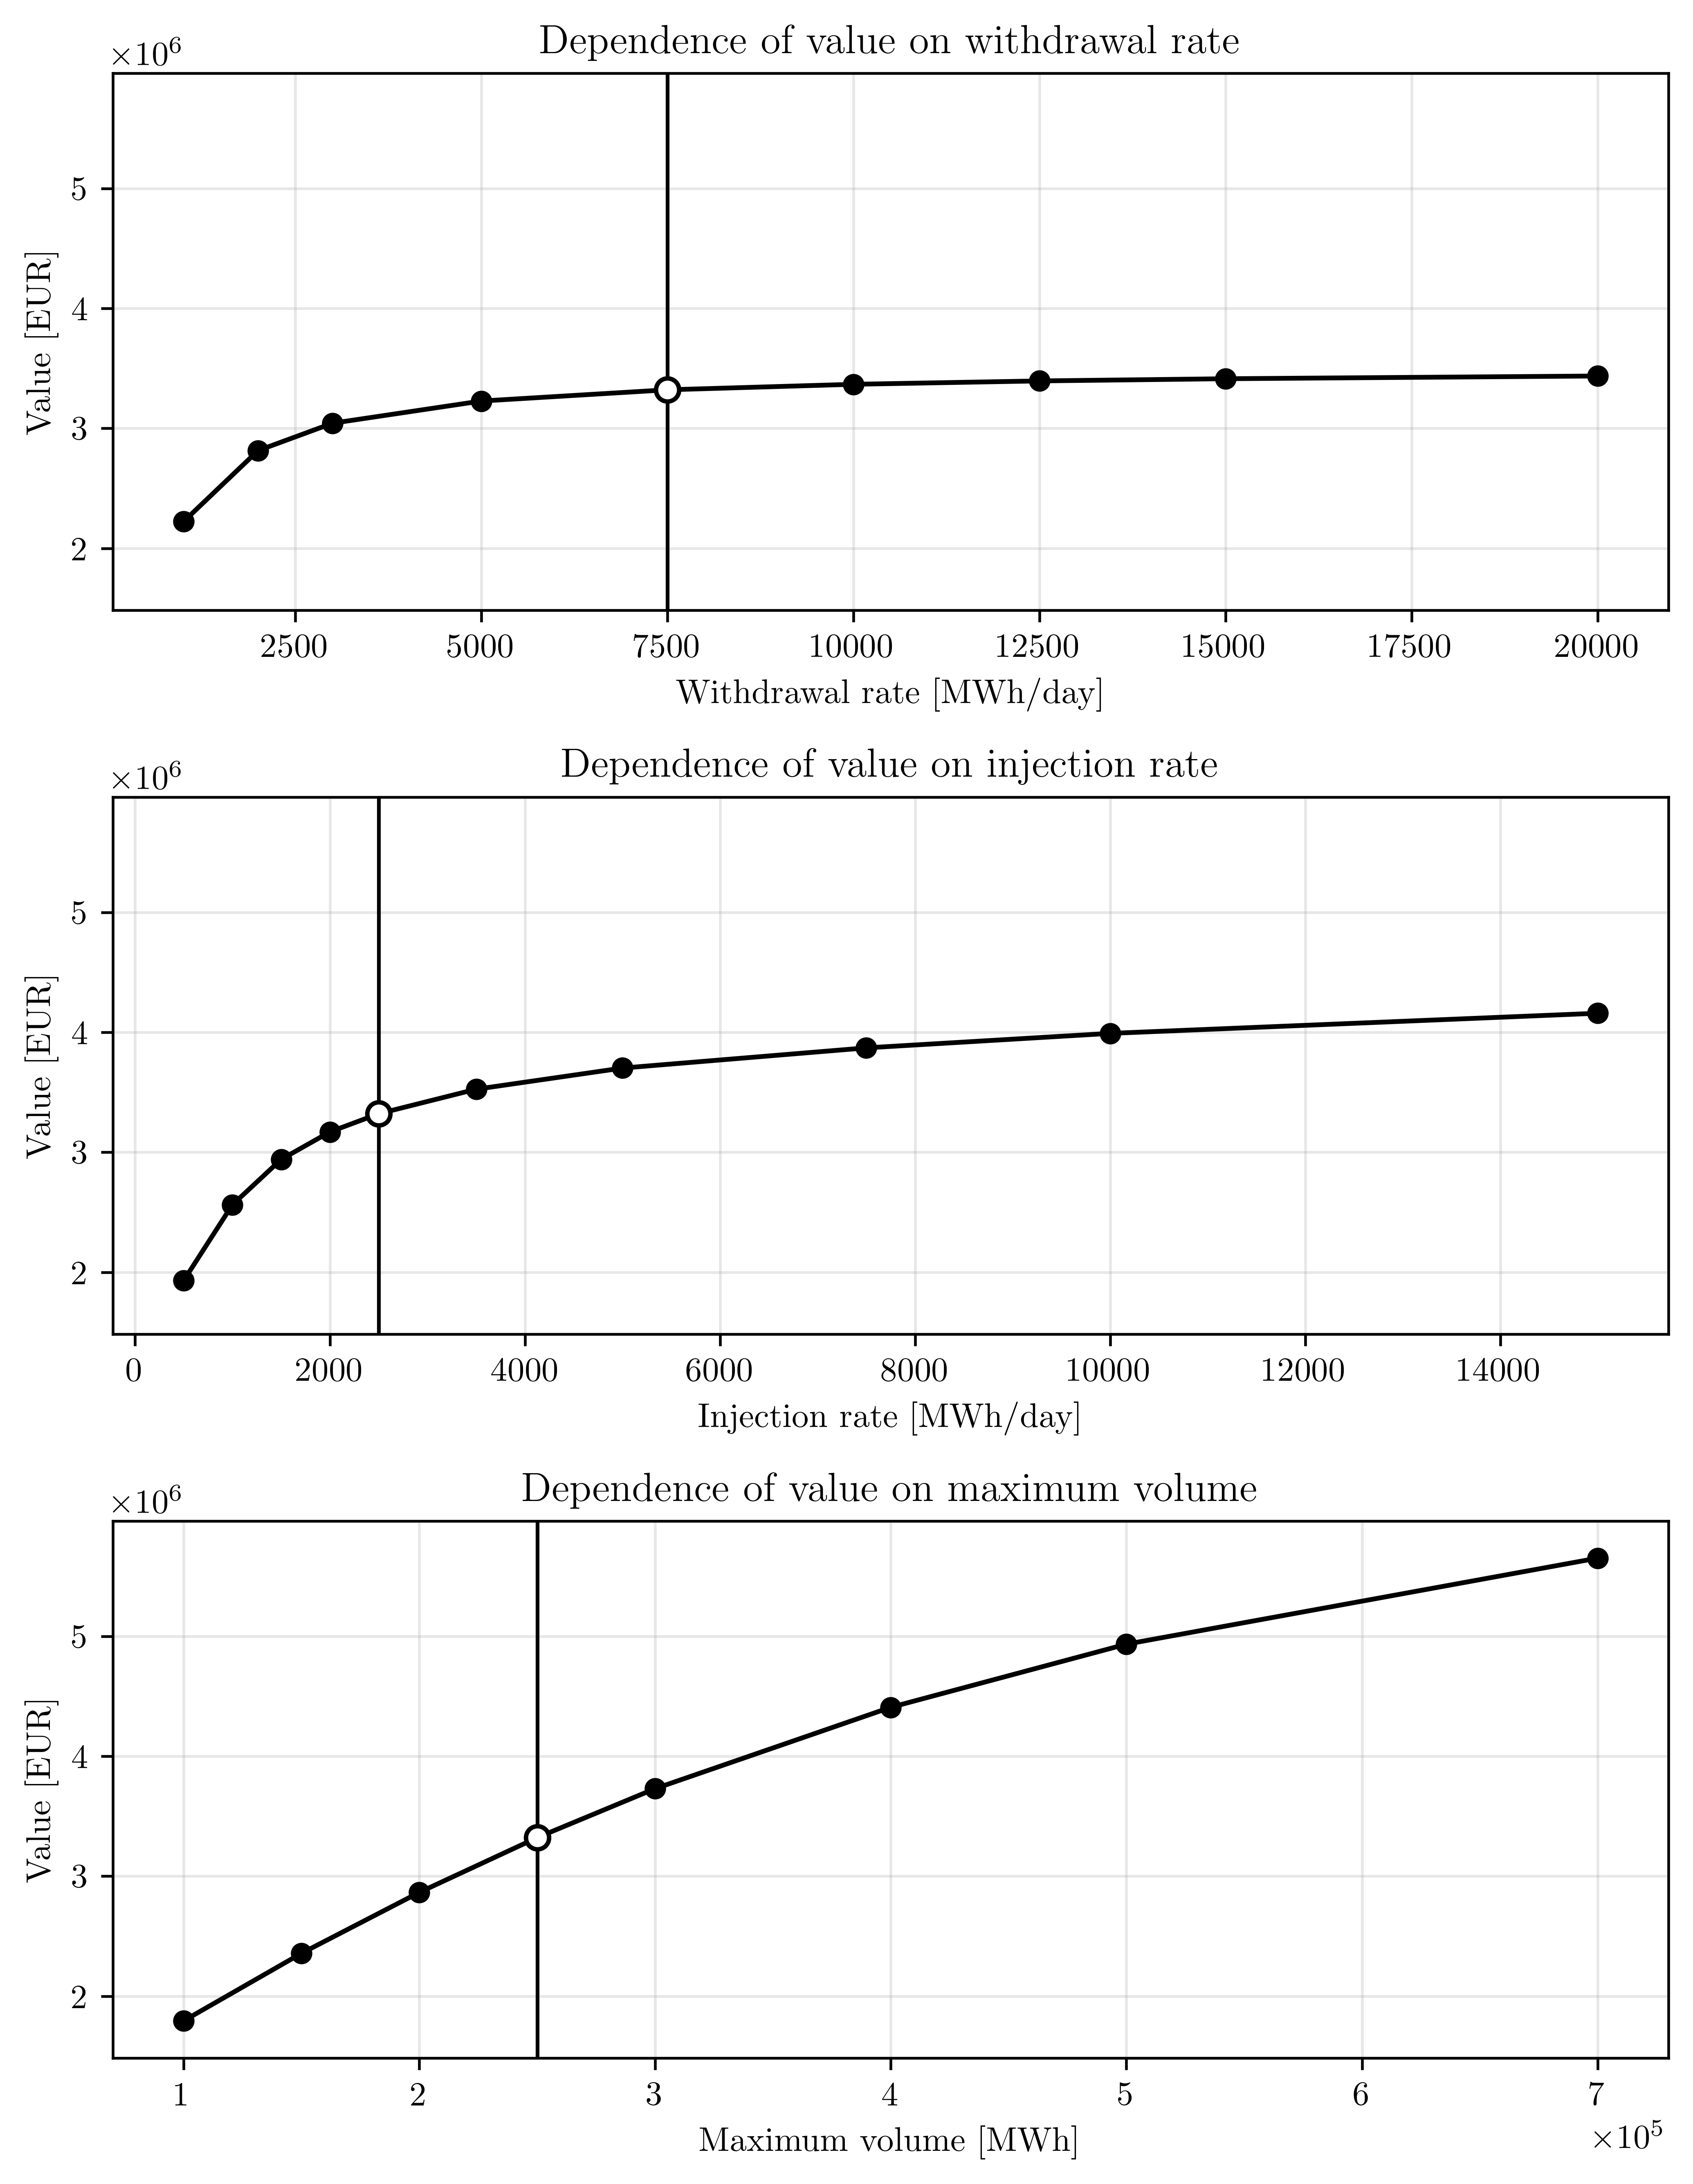

,parameter,parameter_value,x_plot,V0_hat,runtime_seconds
0,withdrawal_rate,1000.0,1000.0,2.223831e+06,11.135153
1,withdrawal_rate,2000.0,2000.0,2.814897e+06,10.618354
2,withdrawal_rate,3000.0,3000.0,3.042957e+06,10.930637
3,withdrawal_rate,5000.0,5000.0,3.227958e+06,12.216127
4,withdrawal_rate,7500.0,7500.0,3.321482e+06,13.679423
5,withdrawal_rate,10000.0,10000.0,3.367402e+06,15.123006
6,withdrawal_rate,12500.0,12500.0,3.395510e+06,16.851957
7,withdrawal_rate,15000.0,15000.0,3.413761e+06,18.703704
8,withdrawal_rate,20000.0,20000.0,3.436561e+06,21.848312
9,injection_rate,500.0,500.0,1.930706e+06,13.715768


In [12]:
# Contract sensitivity analysis: withdrawal rate, injection rate, and maximum volume.
# Standalone cell: rebuilds the contract-dependent globals for each sweep,
# values the same simulated price sample under each contract variant, then
# restores the baseline configuration used elsewhere in the notebook.
import time
from matplotlib.ticker import ScalarFormatter

withdrawal_grid = np.array([1000, 2000, 3000, 5000, 7500, 10000, 12500, 15000, 20000], dtype=np.float64)
injection_grid  = np.array([500, 1000, 1500, 2000, 2500, 3500, 5000, 7500, 10000, 15000], dtype=np.float64)
volume_grid     = np.array([100000, 150000, 200000, 250000, 300000, 400000, 500000, 700000], dtype=np.float64)

n_paths_sens_contract = 10_000
seed_sens_contract = 123
save_path_contract = "../../fig/Plots/OLS_sensitivity_contract_parameters.png"
csv_path_contract = "../data/OLS_sensitivity_contract_parameters.csv"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

baseline_contract = {
    "VMAX_CONST": float(VMAX_CONST),
    "INJECTMAX_BASE": float(INJECTMAX_BASE),
    "WDRMAX_BASE": float(WDRMAX_BASE),
}

rng_contract = np.random.default_rng(seed_sens_contract)
n_half_contract = int(np.ceil(n_paths_sens_contract / 2))
Z_half_contract = rng_contract.standard_normal(size=(Tn - 1, n_half_contract))
Z_contract = np.concatenate([Z_half_contract, -Z_half_contract], axis=1)[:, :n_paths_sens_contract]
S_contract = simulate_from_Z(
    Z_contract,
    n_paths=n_paths_sens_contract,
    Tn=Tn,
    t_arr=t_arr,
    kappa_hat=kappa_hat,
    sigma_hat=sigma_hat,
    m_col=m_col,
)

def configure_contract_globals(vmax_const: float, injectmax_base: float, wdrmax_base: float):
    global VMAX_CONST, INJECTMAX_BASE, WDRMAX_BASE
    global vmax_arr, vmin_arr, VMIN_GLOBAL, VMAX_GLOBAL
    global Nc, Nf, v_coarse, v_fine, coarse_fine_idx
    global n0_f, nT_f, all_next_idx, all_dv_mat, all_K_len, all_dest_ok, all_can_reach

    VMAX_CONST = float(vmax_const)
    INJECTMAX_BASE = float(injectmax_base)
    WDRMAX_BASE = float(wdrmax_base)

    vmax_arr = np.full(len(dates_pd), VMAX_CONST, dtype=np.float64)
    vmin_arr = np.full(len(dates_pd), VMIN_CONST, dtype=np.float64)

    VMIN_GLOBAL = 0.0
    VMAX_GLOBAL = float(np.max(vmax_arr))

    if v0 > VMAX_GLOBAL + 1e-9 or vT_target > VMAX_GLOBAL + 1e-9:
        raise ValueError(
            f"Initial/terminal inventory ({v0:,.0f}) exceeds max volume ({VMAX_GLOBAL:,.0f})."
        )

    Nc = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
    Nf = (Nc - 1) * refine_factor + 1

    v_coarse = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
    v_fine = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
    coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
    assert coarse_fine_idx[-1] == Nf - 1

    n0_f = int(round((v0 - VMIN_GLOBAL) / alpha_f))
    nT_f = int(round((vT_target - VMIN_GLOBAL) / alpha_f))

    all_next_idx = []
    all_dv_mat = []
    all_K_len = []
    all_dest_ok = []

    for t_idx in range(Tn):
        ni, dv, kl = build_feasible_actions_at_t(t_idx)
        all_next_idx.append(ni)
        all_dv_mat.append(dv)
        all_K_len.append(kl)

        t_next = min(t_idx + 1, len(vmax_arr) - 1)
        all_dest_ok.append(
            (v_fine >= vmin_arr[t_next] - 1e-6) &
            (v_fine <= vmax_arr[t_next] + 1e-6)
        )

    T = Tn - 1
    all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
    all_can_reach[T][nT_f] = True
    for t_idx in range(T - 1, -1, -1):
        can_reach_next = all_can_reach[t_idx + 1]
        can_reach_now = all_can_reach[t_idx]
        ni_t = all_next_idx[t_idx]
        kl_t = all_K_len[t_idx]
        for n_f in range(Nf):
            klen = kl_t[n_f]
            if klen == 0:
                continue
            can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])


def value_for_contract(vmax_const: float, injectmax_base: float, wdrmax_base: float) -> float:
    configure_contract_globals(vmax_const, injectmax_base, wdrmax_base)
    return lsmc_value_given_S(S_contract)

records = []

for wdr_val in tqdm(withdrawal_grid, desc="Sweeping withdrawal rate"):
    t0 = time.perf_counter()
    V0_hat_local = value_for_contract(
        baseline_contract["VMAX_CONST"],
        baseline_contract["INJECTMAX_BASE"],
        wdr_val,
    )
    records.append({
        "parameter": "withdrawal_rate",
        "parameter_value": float(wdr_val),
        "x_plot": float(wdr_val),
        "V0_hat": float(V0_hat_local),
        "runtime_seconds": time.perf_counter() - t0,
    })

for inj_val in tqdm(injection_grid, desc="Sweeping injection rate"):
    t0 = time.perf_counter()
    V0_hat_local = value_for_contract(
        baseline_contract["VMAX_CONST"],
        inj_val,
        baseline_contract["WDRMAX_BASE"],
    )
    records.append({
        "parameter": "injection_rate",
        "parameter_value": float(inj_val),
        "x_plot": float(inj_val),
        "V0_hat": float(V0_hat_local),
        "runtime_seconds": time.perf_counter() - t0,
    })

for vmax_val in tqdm(volume_grid, desc="Sweeping max volume"):
    t0 = time.perf_counter()
    V0_hat_local = value_for_contract(
        vmax_val,
        baseline_contract["INJECTMAX_BASE"],
        baseline_contract["WDRMAX_BASE"],
    )
    records.append({
        "parameter": "max_volume",
        "parameter_value": float(vmax_val),
        "x_plot": float(vmax_val),
        "V0_hat": float(V0_hat_local),
        "runtime_seconds": time.perf_counter() - t0,
    })

configure_contract_globals(
    baseline_contract["VMAX_CONST"],
    baseline_contract["INJECTMAX_BASE"],
    baseline_contract["WDRMAX_BASE"],
)

contract_sens_df = pd.DataFrame(records)
contract_sens_df.to_csv(csv_path_contract, index=False)

baseline_points = {
    "withdrawal_rate": (baseline_contract["WDRMAX_BASE"], value_for_contract(
        baseline_contract["VMAX_CONST"],
        baseline_contract["INJECTMAX_BASE"],
        baseline_contract["WDRMAX_BASE"],
    )),
    "injection_rate": (baseline_contract["INJECTMAX_BASE"], value_for_contract(
        baseline_contract["VMAX_CONST"],
        baseline_contract["INJECTMAX_BASE"],
        baseline_contract["WDRMAX_BASE"],
    )),
    "max_volume": (baseline_contract["VMAX_CONST"], value_for_contract(
        baseline_contract["VMAX_CONST"],
        baseline_contract["INJECTMAX_BASE"],
        baseline_contract["WDRMAX_BASE"],
    )),
}

configure_contract_globals(
    baseline_contract["VMAX_CONST"],
    baseline_contract["INJECTMAX_BASE"],
    baseline_contract["WDRMAX_BASE"],
)

panel_specs = [
    ("withdrawal_rate", "Dependence of value on withdrawal rate", r"Withdrawal rate [MWh/day]"),
    ("injection_rate", "Dependence of value on injection rate", r"Injection rate [MWh/day]"),
    ("max_volume", "Dependence of value on maximum volume", r"Maximum volume [MWh]"),
]

fig, axes = plt.subplots(3, 1, figsize=(7.0, 9.0), dpi=600, sharey=True)

all_vals = contract_sens_df["V0_hat"].to_numpy(dtype=np.float64)
y_pad = 0.08 * max(all_vals.max() - all_vals.min(), 1.0)
y_min = max(0.0, all_vals.min() - y_pad)
y_max = all_vals.max() + y_pad

for ax, (param_name, title, xlabel) in zip(axes, panel_specs):
    panel_df = contract_sens_df.loc[contract_sens_df["parameter"] == param_name].sort_values("x_plot")
    x_vals = panel_df["x_plot"].to_numpy(dtype=np.float64)
    y_vals = panel_df["V0_hat"].to_numpy(dtype=np.float64)
    x_base, y_base = baseline_points[param_name]

    ax.plot(x_vals, y_vals, color="black", linewidth=1.4)
    ax.scatter(x_vals, y_vals, color="black", s=28, zorder=3)
    ax.axvline(x_base, color="black", linewidth=1.1)
    ax.scatter([x_base], [y_base], s=46, facecolors="white", edgecolors="black", linewidth=1.3, zorder=4)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"Value [EUR]")
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(6, 6), useMathText=True)

    if param_name == "max_volume":
        ax.ticklabel_format(axis="x", style="sci", scilimits=(5, 5), useMathText=True)

fig.tight_layout()
plt.savefig(save_path_contract, dpi=600, bbox_inches="tight")
plt.show()

display(contract_sens_df)


In [ ]:
# Print estimated mean-reversion and volatility parameters
print(f"kappa_hat = {kappa_hat:.4f} per calendar day")
print(f"sigma_hat = {sigma_hat:.4f} per sqrt(calendar day)")

In [3]:
# Glasserman--Yu-style empirical convergence frontier for the Dutch salt cavern case.
# Empirical analogue: for each basis degree, estimate the minimum number of
# paths required for the mean absolute in-sample/out-of-sample gap to fall
# below 1\% of a reference value.
import time

n_observations_values = [1000, 2000, 5000, 10000, 20000, 50000, 100000]
basis_degree_values = [1, 2, 3, 4, 5, 6, 8, 10]
basis_family_name = "monomial"
base_seed = 123
n_seeds = 10

csv_path = "../data/OLS_convergence_paths_vs_basis_frontier.csv"
fig_path = "../../fig/Plots/OLS_convergence_paths_vs_basis_frontier.png"

n_numba_threads = max(1, min(4, nb.config.NUMBA_DEFAULT_NUM_THREADS))
nb.set_num_threads(n_numba_threads)


def frontier_simulate_from_Z(Z, *, n_paths, Tn, t_arr, kappa_hat, sigma_hat, m_col):
    Z_use = Z[:, :n_paths]
    Y = np.zeros((Tn, n_paths), dtype=np.float64)
    for i in range(1, Tn):
        h = t_arr[i] - t_arr[i - 1]
        phi_h = np.exp(-kappa_hat * h)
        sd_h = np.sqrt(
            sigma_hat**2 / (2.0 * kappa_hat) * (1.0 - np.exp(-2.0 * kappa_hat * h))
        )
        Y[i] = phi_h * Y[i - 1] + sd_h * Z_use[i - 1]
    return np.exp(Y + m_col)


def frontier_prepare_numba_lists(all_next_idx, all_dv_mat, all_K_len, all_can_reach, all_dest_ok):
    next_idx_list = nb.typed.List()
    dv_list = nb.typed.List()
    kl_list = nb.typed.List()
    reach_ok_list = nb.typed.List()
    dest_ok_list = nb.typed.List()

    for t in range(Tn - 1):
        next_idx_list.append(all_next_idx[t])
        dv_list.append(all_dv_mat[t])
        kl_list.append(all_K_len[t])
        reach_ok_list.append(all_can_reach[t + 1])
        dest_ok_list.append(all_dest_ok[t + 1])

    return next_idx_list, dv_list, kl_list, reach_ok_list, dest_ok_list


def frontier_precompute_interp_metadata(coarse_fine_idx, refine_factor, Nf):
    fine_left_idx = np.empty(Nf, dtype=np.int32)
    fine_right_idx = np.empty(Nf, dtype=np.int32)
    fine_right_weight = np.empty(Nf, dtype=np.float64)
    n_coarse = coarse_fine_idx.size

    for n_f in range(Nf):
        left = min(n_f // refine_factor, n_coarse - 1)
        left_f = coarse_fine_idx[left]
        if left == n_coarse - 1 or n_f == left_f:
            right = left
            weight = 0.0
        else:
            right = left + 1
            weight = (n_f - left_f) / refine_factor
        fine_left_idx[n_f] = left
        fine_right_idx[n_f] = right
        fine_right_weight[n_f] = weight

    return fine_left_idx, fine_right_idx, fine_right_weight


def frontier_build_monomial_basis_tensor(S, max_degree):
    Tloc, Mloc = S.shape
    X_full = np.empty((Tloc, Mloc, max_degree + 1), dtype=np.float64)
    X_full[:, :, 0] = 1.0
    if max_degree >= 1:
        X_full[:, :, 1] = S
    for p in range(2, max_degree + 1):
        X_full[:, :, p] = X_full[:, :, p - 1] * S
    return X_full


@nb.njit(cache=False)
def frontier_compute_frontier_numba(mean_abs_gap_mat, n_obs_arr, gap_threshold):
    n_basis = mean_abs_gap_mat.shape[0]
    required_paths = np.empty(n_basis, dtype=np.float64)
    plotting_paths = np.empty(n_basis, dtype=np.float64)
    converged = np.zeros(n_basis, dtype=np.bool_)
    max_n_obs = float(n_obs_arr[-1])

    for i in range(n_basis):
        required_paths[i] = np.nan
        plotting_paths[i] = max_n_obs
        for j in range(mean_abs_gap_mat.shape[1]):
            if mean_abs_gap_mat[i, j] <= gap_threshold:
                required_paths[i] = float(n_obs_arr[j])
                plotting_paths[i] = float(n_obs_arr[j])
                converged[i] = True
                break

    return required_paths, plotting_paths, converged


@nb.njit(fastmath=True)
def frontier_fill_monomial_basis_numba(s, basis_vals):
    basis_vals[0] = 1.0
    for p in range(1, basis_vals.shape[0]):
        basis_vals[p] = basis_vals[p - 1] * s


@nb.njit(parallel=True, fastmath=True)
def frontier_oos_value_realized_only_numba(
    S_test,
    B_store,
    basis_degree,
    next_idx_list,
    dv_list,
    kl_list,
    reach_ok_list,
    fine_left_idx,
    fine_right_idx,
    fine_right_weight,
    v_fine,
    cum_disc,
    n0_f,
    nT_f,
    terminal_penalty,
):
    Tloc = S_test.shape[0] - 1
    Mloc = S_test.shape[1]
    p_dim = basis_degree + 1
    pv = np.empty(Mloc, dtype=np.float64)
    at_target = np.zeros(Mloc, dtype=np.bool_)

    for i in nb.prange(Mloc):
        n_state = n0_f
        pv_i = 0.0

        for t in range(Tloc):
            s = S_test[t, i]
            basis_vals = np.empty(p_dim, dtype=np.float64)
            frontier_fill_monomial_basis_numba(s, basis_vals)

            ni_t = next_idx_list[t]
            dv_t = dv_list[t]
            kl_t = kl_list[t]
            reach_ok_t = reach_ok_list[t]
            klen = kl_t[n_state]

            best_val = terminal_penalty
            best_next = -1
            best_dv = 0.0

            for kk in range(klen):
                nxt = ni_t[n_state, kk]
                if not reach_ok_t[nxt]:
                    continue

                left = fine_left_idx[nxt]
                right = fine_right_idx[nxt]
                w_right = fine_right_weight[nxt]
                w_left = 1.0 - w_right

                c_left = 0.0
                c_right = 0.0
                for p in range(p_dim):
                    coeff = basis_vals[p]
                    c_left += coeff * B_store[t, p, left]
                    c_right += coeff * B_store[t, p, right]

                c_hat = w_left * c_left + w_right * c_right
                dv = dv_t[n_state, kk]
                cand = (-s * dv) + c_hat
                if cand > best_val:
                    best_val = cand
                    best_next = nxt
                    best_dv = dv

            if best_next == -1:
                pv_i = np.nan
                break

            pv_i += cum_disc[t] * (-s * best_dv)
            n_state = best_next

        if n_state == nT_f:
            at_target[i] = True
            pv[i] = pv_i
        else:
            pv[i] = np.nan

    return pv, at_target


def frontier_run_backward_monomial(
    S,
    X_full,
    basis_degree,
    reach_next_coarse_by_t,
):
    T = S.shape[0] - 1
    M = S.shape[1]
    p_dim = basis_degree + 1

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    tv = terminal_value(v_fine)
    Y_next = np.tile(tv, (M, 1))
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current = np.empty((M, Nf), dtype=np.float64)
    pi_dtype = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T, M), dtype=pi_dtype)
    n_curr = np.full(M, nT_f, dtype=np.int32)
    B_store = np.empty((T, p_dim, Nc), dtype=np.float64)

    for t in range(T - 1, -1, -1):
        S_t = S[t].astype(np.float64, copy=False)
        X_t = X_full[t, :, :p_dim]
        reach_next = all_can_reach[t + 1]
        reach_next_coarse = reach_next_coarse_by_t[t]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]
        B = np.zeros((p_dim, Nc), dtype=np.float64)

        for j in range(Nc):
            if not reach_next_coarse[j]:
                continue
            col = Y_disc[:, j]
            mask = np.isfinite(col)
            if mask.sum() < p_dim:
                continue
            Xm = X_t[mask]
            XtX = Xm.T @ Xm
            XtY = Xm.T @ col[mask]
            B[:, j] = np.linalg.solve(XtX, XtY)

        B_store[t] = B
        C_hat_coarse = X_t @ B
        interpolate_coarse_to_fine(
            C_hat_fine_buf,
            C_hat_coarse,
            coarse_fine_idx,
            refine_factor,
        )
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)
        bellman_update_numba(
            Y_current,
            Y_next,
            pi_next_idx[t],
            n_curr,
            S_t,
            C_hat_fine_buf,
            all_next_idx[t],
            all_dv_mat[t],
            all_K_len[t],
            disc_arr[t],
            terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    V0_hat = float(np.mean(Y_next[:, n0_f]))
    return V0_hat, B_store


def frontier_oos_value_realized_only(
    S_test,
    B_store,
    basis_degree,
    next_idx_list,
    dv_list,
    kl_list,
    reach_ok_list,
    fine_left_idx,
    fine_right_idx,
    fine_right_weight,
    cum_disc,
):
    pv, at_target = frontier_oos_value_realized_only_numba(
        S_test,
        B_store,
        basis_degree,
        next_idx_list,
        dv_list,
        kl_list,
        reach_ok_list,
        fine_left_idx,
        fine_right_idx,
        fine_right_weight,
        v_fine,
        cum_disc,
        n0_f,
        nT_f,
        terminal_penalty,
    )
    n_failed = int(np.sum(~at_target))
    if n_failed > 0:
        print(f"  OOS: {n_failed}/{S_test.shape[1]} paths did not reach terminal target.")
    return float(np.nanmean(pv))


next_idx_list, dv_list, kl_list, reach_ok_list, dest_ok_list = frontier_prepare_numba_lists(
    all_next_idx,
    all_dv_mat,
    all_K_len,
    all_can_reach,
    all_dest_ok,
)
fine_left_idx, fine_right_idx, fine_right_weight = frontier_precompute_interp_metadata(
    coarse_fine_idx,
    refine_factor,
    Nf,
)
reach_next_coarse_by_t = [
    all_can_reach[t + 1][coarse_fine_idx].copy() for t in range(Tn - 1)
]
cum_disc = np.ones(Tn - 1, dtype=np.float64)
if Tn - 1 > 1:
    cum_disc[1:] = np.cumprod(disc_arr[:-1])

seed_values = base_seed + np.arange(n_seeds)
n_observations_max = max(n_observations_values)
max_basis_degree = max(basis_degree_values)
records = []
backward_runtime_total_seconds = 0.0
oos_runtime_total_seconds = 0.0

for seed in tqdm(seed_values, desc="Paths vs basis frontier"):
    seed_train = int(seed)
    seed_test = int(seed + 10_000)

    rng_train = np.random.default_rng(seed_train)
    n_half_train = int(np.ceil(n_observations_max / 2))
    Z_half_train = rng_train.standard_normal(size=(Tn - 1, n_half_train))
    Z_train = np.concatenate([Z_half_train, -Z_half_train], axis=1)[:, :n_observations_max]

    rng_test = np.random.default_rng(seed_test)
    n_half_test = int(np.ceil(n_observations_max / 2))
    Z_half_test = rng_test.standard_normal(size=(Tn - 1, n_half_test))
    Z_test = np.concatenate([Z_half_test, -Z_half_test], axis=1)[:, :n_observations_max]

    S_train_full = frontier_simulate_from_Z(
        Z_train,
        n_paths=n_observations_max,
        Tn=Tn,
        t_arr=t_arr,
        kappa_hat=kappa_hat,
        sigma_hat=sigma_hat,
        m_col=m_col,
    )
    S_test_full = frontier_simulate_from_Z(
        Z_test,
        n_paths=n_observations_max,
        Tn=Tn,
        t_arr=t_arr,
        kappa_hat=kappa_hat,
        sigma_hat=sigma_hat,
        m_col=m_col,
    )

    for n_observations in n_observations_values:
        S_train = S_train_full[:, :n_observations]
        S_test = S_test_full[:, :n_observations]
        X_train_full = frontier_build_monomial_basis_tensor(S_train, max_basis_degree)

        for basis_degree in basis_degree_values:
            t0 = time.perf_counter()
            V0_hat_in_sample, B_store = frontier_run_backward_monomial(
                S_train,
                X_train_full,
                basis_degree,
                reach_next_coarse_by_t,
            )
            runtime_in_sample_seconds = time.perf_counter() - t0
            backward_runtime_total_seconds += runtime_in_sample_seconds

            t1 = time.perf_counter()
            V0_hat_out_of_sample = frontier_oos_value_realized_only(
                S_test,
                B_store,
                basis_degree,
                next_idx_list,
                dv_list,
                kl_list,
                reach_ok_list,
                fine_left_idx,
                fine_right_idx,
                fine_right_weight,
                cum_disc,
            )
            runtime_out_of_sample_seconds = time.perf_counter() - t1
            oos_runtime_total_seconds += runtime_out_of_sample_seconds

            abs_gap = abs(V0_hat_in_sample - V0_hat_out_of_sample)

            records.append({
                "seed": int(seed),
                "seed_train": seed_train,
                "seed_test": seed_test,
                "n_observations": int(n_observations),
                "basis_family": basis_family_name,
                "basis_degree": int(basis_degree),
                "V0_hat_in_sample": float(V0_hat_in_sample),
                "V0_hat_out_of_sample": float(V0_hat_out_of_sample),
                "abs_gap": float(abs_gap),
                "runtime_in_sample_seconds": float(runtime_in_sample_seconds),
                "runtime_out_of_sample_seconds": float(runtime_out_of_sample_seconds),
                "runtime_total_seconds": float(runtime_in_sample_seconds + runtime_out_of_sample_seconds),
            })

results_df = pd.DataFrame(records)

summary_df = (
    results_df
    .groupby(["basis_degree", "n_observations"], as_index=False)
    .agg(
        mean_V0_hat_in_sample=("V0_hat_in_sample", "mean"),
        std_V0_hat_in_sample=("V0_hat_in_sample", lambda x: x.std(ddof=1)),
        mean_V0_hat_out_of_sample=("V0_hat_out_of_sample", "mean"),
        std_V0_hat_out_of_sample=("V0_hat_out_of_sample", lambda x: x.std(ddof=1)),
        mean_abs_gap=("abs_gap", "mean"),
        std_abs_gap=("abs_gap", lambda x: x.std(ddof=1)),
        mean_runtime_total_seconds=("runtime_total_seconds", "mean"),
        std_runtime_total_seconds=("runtime_total_seconds", lambda x: x.std(ddof=1)),
    )
    .sort_values(["basis_degree", "n_observations"])
    .reset_index(drop=True)
)

reference_n = max(n_observations_values)
reference_degree = 3
reference_row = summary_df.loc[
    (summary_df["basis_degree"] == reference_degree)
    & (summary_df["n_observations"] == reference_n)
]
if reference_row.empty:
    raise RuntimeError("Reference row for basis degree 3 and maximum path count was not found.")

reference_V0_hat = float(reference_row["mean_V0_hat_out_of_sample"].iloc[0])
gap_threshold = 0.01 * abs(reference_V0_hat)

summary_df["reference_V0_hat"] = reference_V0_hat
summary_df["gap_threshold"] = gap_threshold
summary_df["meets_gap_threshold"] = summary_df["mean_abs_gap"] <= gap_threshold
summary_df["relative_gap_pct_of_reference"] = (
    100.0 * summary_df["mean_abs_gap"] / abs(reference_V0_hat)
)

mean_abs_gap_mat = (
    summary_df
    .pivot(index="basis_degree", columns="n_observations", values="mean_abs_gap")
    .reindex(index=basis_degree_values, columns=n_observations_values)
    .to_numpy(dtype=np.float64)
)
required_paths_arr, plotting_paths_arr, converged_arr = frontier_compute_frontier_numba(
    mean_abs_gap_mat,
    np.asarray(n_observations_values, dtype=np.int64),
    float(gap_threshold),
)

frontier_records = []
for basis_degree, required_paths, plotting_paths, converged in zip(
    basis_degree_values,
    required_paths_arr,
    plotting_paths_arr,
    converged_arr,
):
    frontier_records.append({
        "basis_degree": int(basis_degree),
        "required_paths": float(required_paths),
        "plotting_paths": float(plotting_paths),
        "converged_in_range": bool(converged),
        "reference_V0_hat": reference_V0_hat,
        "gap_threshold": gap_threshold,
    })

frontier_df = pd.DataFrame(frontier_records)
summary_df = summary_df.merge(frontier_df, on="basis_degree", how="left")
results_df = results_df.merge(
    summary_df,
    on=["basis_degree", "n_observations"],
    how="left",
)
results_df.to_csv(csv_path, index=False)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

frontier_plot_df = frontier_df.sort_values("basis_degree")
mask_converged = frontier_plot_df["converged_in_range"].to_numpy(dtype=bool)
mask_not_converged = ~mask_converged

if mask_converged.any():
    ax.plot(
        frontier_plot_df.loc[mask_converged, "basis_degree"],
        frontier_plot_df.loc[mask_converged, "required_paths"],
        color="black",
        linewidth=1.4,
        marker="o",
        label="Empirical frontier",
    )

if mask_not_converged.any():
    ax.scatter(
        frontier_plot_df.loc[mask_not_converged, "basis_degree"],
        frontier_plot_df.loc[mask_not_converged, "plotting_paths"],
        facecolors="white",
        edgecolors="black",
        s=42,
        linewidth=1.2,
        zorder=3,
        label="Not converged in tested range",
    )
    for _, row in frontier_plot_df.loc[mask_not_converged].iterrows():
        ax.annotate(
            "NC",
            (row["basis_degree"], row["plotting_paths"]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8,
        )

ax.set_title(r"Empirical Paths-vs-Basis Convergence Frontier")
ax.text(
    0.02,
    0.98,
    rf"Convergence criterion: $\mathbb{{E}}[|\hat V_0^{{IS}} - \hat V_0^{{OOS}}|] \leq 0.01 |\hat V_0^{{ref}}|$",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=8,
)
ax.set_xlabel("Basis degree")
ax.set_ylabel("Minimum number of paths")
ax.set_yscale("log")
ax.set_xticks(basis_degree_values)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.savefig(fig_path)
plt.show()

frontier_diff = np.diff(frontier_plot_df["plotting_paths"].to_numpy(dtype=np.float64))
if np.any(frontier_diff < 0):
    print("Frontier is not weakly monotone across all basis degrees; retaining the empirical result without smoothing.")
else:
    print("Frontier is weakly monotone across tested basis degrees.")

print(
    f"Reference out-of-sample value (degree {reference_degree}, N={reference_n:,}) = {reference_V0_hat:,.2f} EUR"
)
print(f"Gap threshold = {gap_threshold:,.2f} EUR (1% of reference value)")
print(f"Total backward runtime tracked inside sweep: {backward_runtime_total_seconds:,.2f} s")
print(f"Total OOS runtime tracked inside sweep: {oos_runtime_total_seconds:,.2f} s")

display(frontier_df)
display(summary_df)



Paths vs basis frontier: 100%|██████████| 10/10 [3:23:25<00:00, 1220.52s/it] 


RuntimeError: latex was not able to process the following string:
b'Convergence criterion: $\\\\mathbb{E}[|\\\\hat V_0^{IS} - \\\\hat V_0^{OOS}|] \\\\leq 0.01 |\\\\hat V_0^{ref}|$'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2025-06-01> patch level 1
L3 programming layer <2025-09-02>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/t

Error in callback <function _draw_all_if_interactive at 0x141017e20> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'Convergence criterion: $\\\\mathbb{E}[|\\\\hat V_0^{IS} - \\\\hat V_0^{OOS}|] \\\\leq 0.01 |\\\\hat V_0^{ref}|$'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2025-06-01> patch level 1
L3 programming layer <2025-09-02>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/t

RuntimeError: latex was not able to process the following string:
b'Convergence criterion: $\\\\mathbb{E}[|\\\\hat V_0^{IS} - \\\\hat V_0^{OOS}|] \\\\leq 0.01 |\\\\hat V_0^{ref}|$'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2025-06-01> patch level 1
L3 programming layer <2025-09-02>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/t

<Figure size 3900x2100 with 1 Axes>

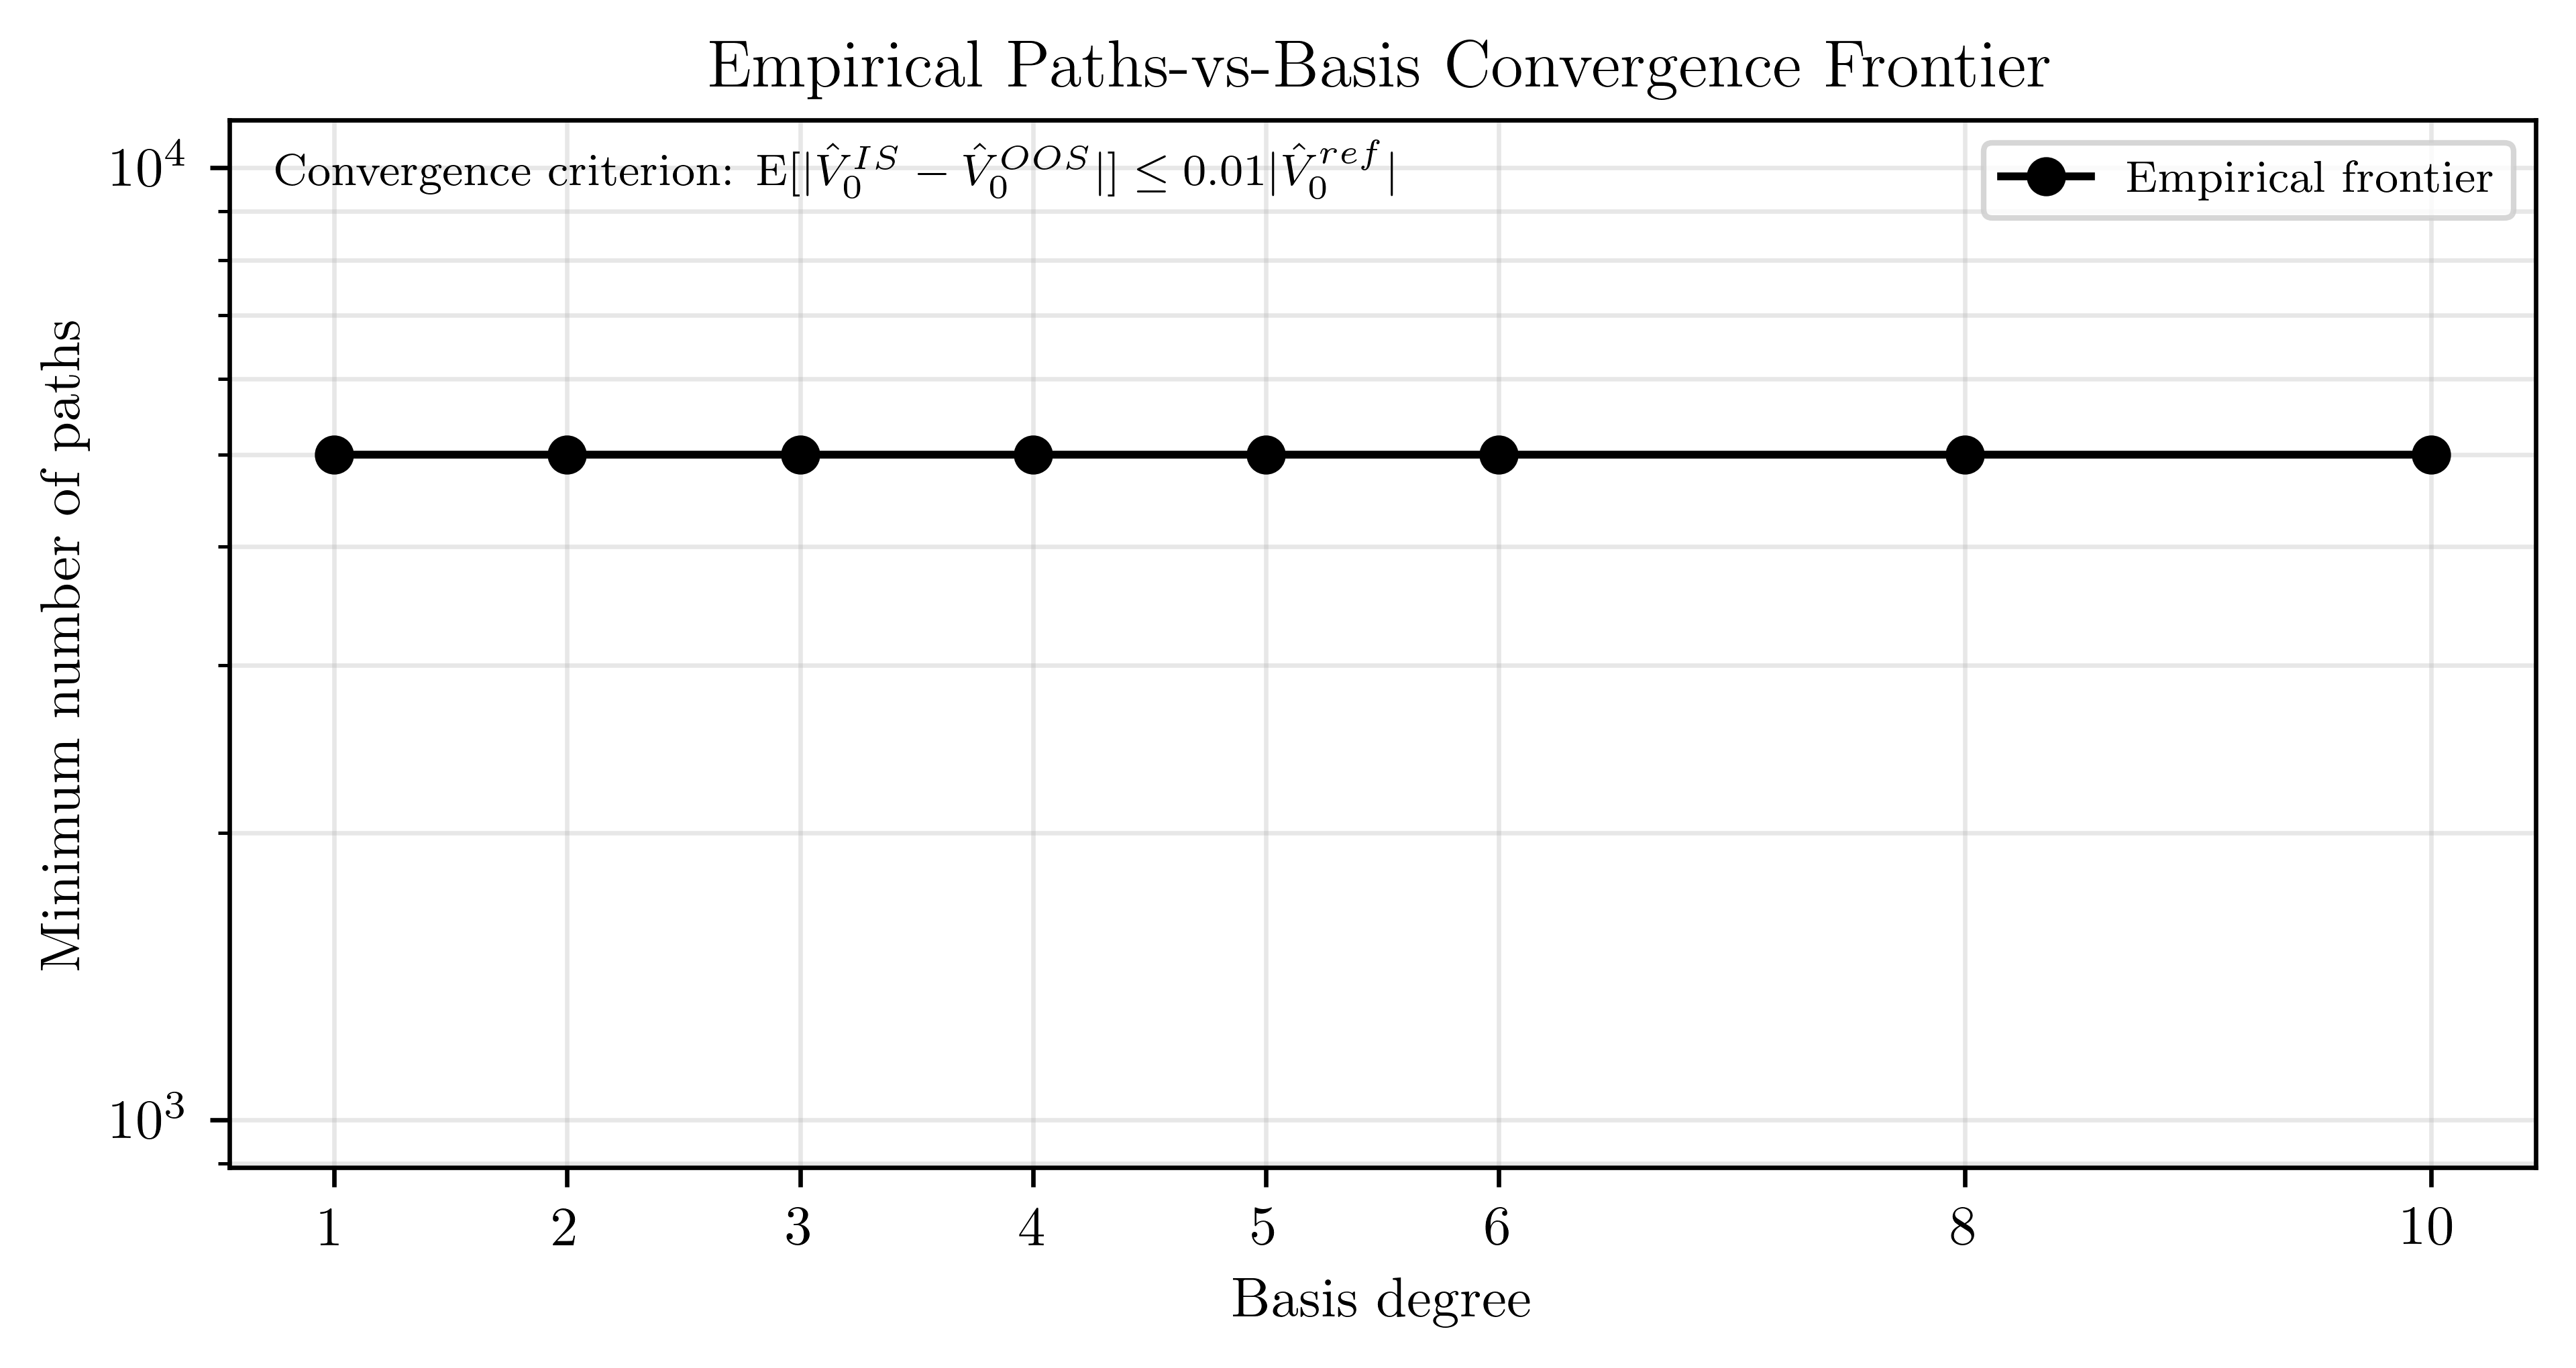

Frontier is weakly monotone across tested basis degrees.
Reference out-of-sample value (degree 3, N=100,000) = 3,164,107.29 EUR
Gap threshold = 31,641.07 EUR (1% of reference value)


,basis_degree,required_paths,plotting_paths,converged_in_range,reference_V0_hat,gap_threshold
0,1,5000.0,5000.0,True,3.164107e+06,31641.07288
1,2,5000.0,5000.0,True,3.164107e+06,31641.07288
2,3,5000.0,5000.0,True,3.164107e+06,31641.07288
3,4,5000.0,5000.0,True,3.164107e+06,31641.07288
4,5,5000.0,5000.0,True,3.164107e+06,31641.07288
5,6,5000.0,5000.0,True,3.164107e+06,31641.07288
6,8,5000.0,5000.0,True,3.164107e+06,31641.07288
7,10,5000.0,5000.0,True,3.164107e+06,31641.07288


,basis_degree,n_observations,mean_V0_hat_in_sample,std_V0_hat_in_sample,mean_V0_hat_out_of_sample,std_V0_hat_out_of_sample,mean_abs_gap,std_abs_gap,mean_runtime_total_seconds,std_runtime_total_seconds,reference_V0_hat_x,gap_threshold_x,meets_gap_threshold,relative_gap_pct_of_reference,required_paths,plotting_paths,converged_in_range,reference_V0_hat_y,gap_threshold_y
0,1,1000,3.122164e+06,53314.451364,3.084603e+06,25614.816345,44489.063106,43164.211344,1.027364,0.632294,3.164107e+06,31641.07288,False,1.406054,5000.0,5000.0,True,3.164107e+06,31641.07288
1,1,2000,3.117450e+06,34180.979310,3.087623e+06,24031.362580,39068.983726,35828.988057,1.335152,0.110468,3.164107e+06,31641.07288,False,1.234755,5000.0,5000.0,True,3.164107e+06,31641.07288
2,1,5000,3.111454e+06,19037.620301,3.104638e+06,12660.075340,16757.373639,18955.956702,3.352419,0.256711,3.164107e+06,31641.07288,True,0.529608,5000.0,5000.0,True,3.164107e+06,31641.07288
3,1,10000,3.109339e+06,13140.641144,3.109348e+06,6587.562195,11622.846993,8120.683295,6.595021,0.470705,3.164107e+06,31641.07288,True,0.367334,5000.0,5000.0,True,3.164107e+06,31641.07288
4,1,20000,3.106374e+06,7715.105133,3.112947e+06,6604.795987,9178.087455,7787.363704,13.698678,1.297184,3.164107e+06,31641.07288,True,0.290069,5000.0,5000.0,True,3.164107e+06,31641.07288
5,1,50000,3.105431e+06,4831.812209,3.109692e+06,2875.561087,5702.733071,4865.308738,32.134979,2.541009,3.164107e+06,31641.07288,True,0.180232,5000.0,5000.0,True,3.164107e+06,31641.07288
6,1,100000,3.108309e+06,2618.566678,3.108716e+06,2626.942028,1903.030500,1019.408523,69.479776,6.947664,3.164107e+06,31641.07288,True,0.060144,5000.0,5000.0,True,3.164107e+06,31641.07288
7,2,1000,3.167900e+06,54354.803658,3.108266e+06,27417.798658,59634.087596,53473.731602,0.842909,0.075427,3.164107e+06,31641.07288,False,1.884705,5000.0,5000.0,True,3.164107e+06,31641.07288
8,2,2000,3.157059e+06,34937.787423,3.119493e+06,24975.627446,43423.597283,42556.504903,1.430405,0.114993,3.164107e+06,31641.07288,False,1.372381,5000.0,5000.0,True,3.164107e+06,31641.07288
9,2,5000,3.150589e+06,20103.045574,3.140985e+06,14218.036412,16147.661357,23568.911973,3.601301,0.292125,3.164107e+06,31641.07288,True,0.510339,5000.0,5000.0,True,3.164107e+06,31641.07288


In [8]:
# Re-run only the post-processing / plotting part.
# This assumes the long frontier computation cell has already finished
# and the kernel still holds frontier_df, summary_df, etc.

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

frontier_plot_df = frontier_df.sort_values("basis_degree")
mask_converged = frontier_plot_df["converged_in_range"].to_numpy(dtype=bool)
mask_not_converged = ~mask_converged

if mask_converged.any():
    ax.plot(
        frontier_plot_df.loc[mask_converged, "basis_degree"],
        frontier_plot_df.loc[mask_converged, "required_paths"],
        color="black",
        linewidth=1.4,
        marker="o",
        label="Empirical frontier",
    )

if mask_not_converged.any():
    ax.scatter(
        frontier_plot_df.loc[mask_not_converged, "basis_degree"],
        frontier_plot_df.loc[mask_not_converged, "plotting_paths"],
        facecolors="white",
        edgecolors="black",
        s=42,
        linewidth=1.2,
        zorder=3,
        label="Not converged in tested range",
    )
    for _, row in frontier_plot_df.loc[mask_not_converged].iterrows():
        ax.annotate(
            "NC",
            (row["basis_degree"], row["plotting_paths"]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8,
        )

ax.set_title("Empirical Paths-vs-Basis Convergence Frontier")
ax.text(
    0.02,
    0.98,
    r"Convergence criterion: $\mathrm{E}[|\hat V_0^{IS} - \hat V_0^{OOS}|] \leq 0.01 |\hat V_0^{ref}|$",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=8,
)
ax.set_xlabel("Basis degree")
ax.set_ylabel("Minimum number of paths")
ax.set_yscale("log")
ax.set_xticks(frontier_plot_df["basis_degree"].to_list())
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", fontsize=8)

fig.tight_layout()
plt.savefig(fig_path)
plt.show()

frontier_diff = np.diff(frontier_plot_df["plotting_paths"].to_numpy(dtype=np.float64))
if np.any(frontier_diff < 0):
    print("Frontier is not weakly monotone across all basis degrees; retaining the empirical result without smoothing.")
else:
    print("Frontier is weakly monotone across tested basis degrees.")

print(f"Reference out-of-sample value (degree {reference_degree}, N={reference_n:,}) = {reference_V0_hat:,.2f} EUR")
print(f"Gap threshold = {gap_threshold:,.2f} EUR (1% of reference value)")

display(frontier_df)
display(summary_df)


Backward pass: 100%|██████████| 729/729 [00:06<00:00, 105.38it/s]


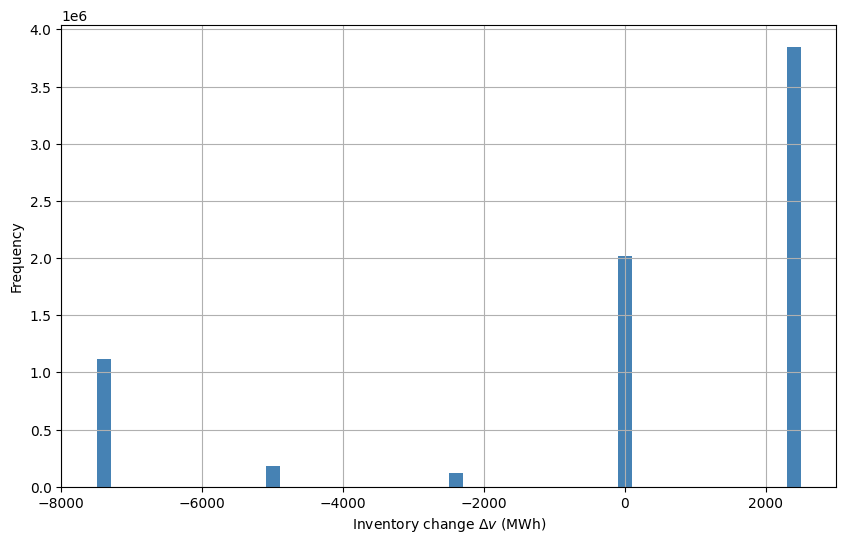

,bin_left,bin_right,count
0,-7500.0,-7300.0,1119915
1,-7300.0,-7100.0,0
2,-7100.0,-6900.0,0
3,-6900.0,-6700.0,0
4,-6700.0,-6500.0,0
5,-6500.0,-6300.0,0
6,-6300.0,-6100.0,0
7,-6100.0,-5900.0,0
8,-5900.0,-5700.0,0
9,-5700.0,-5500.0,0


In [19]:
# -------------------------------------------------
# Inventory change distribution histogram
# -------------------------------------------------

seed = 123

n_paths = 10_000

rng = np.random.default_rng(seed)
n_half = int(np.ceil(n_paths / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths]

S_sim = simulate_from_Z(Z, n_paths=n_paths, Tn=Tn, t_arr=t_arr,
                        kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

V0_hat, v_path, date_path = lsmc_value_and_paths_given_S(S_sim)
delta_v_path = np.diff(v_path, axis=0)

# Print a inventory change frequency histogram
plt.figure(figsize=(10, 6))
plt.hist(delta_v_path.flatten(), bins=50, alpha=1, color = "steelblue")
plt.xlabel("Inventory change $\\Delta v$ (MWh)")
plt.ylabel("Frequency")
plt.grid()
plt.savefig("../../fig/Plots/OLS_inventory_change_distribution.png")
plt.show()

# Print table of inventory changes with the bins used in the histogram
hist_counts, hist_bins = np.histogram(delta_v_path.flatten(), bins=50)
hist_table_df = pd.DataFrame({
    "bin_left": hist_bins[:-1],
    "bin_right": hist_bins[1:],
    "count": hist_counts,
})
display(hist_table_df)

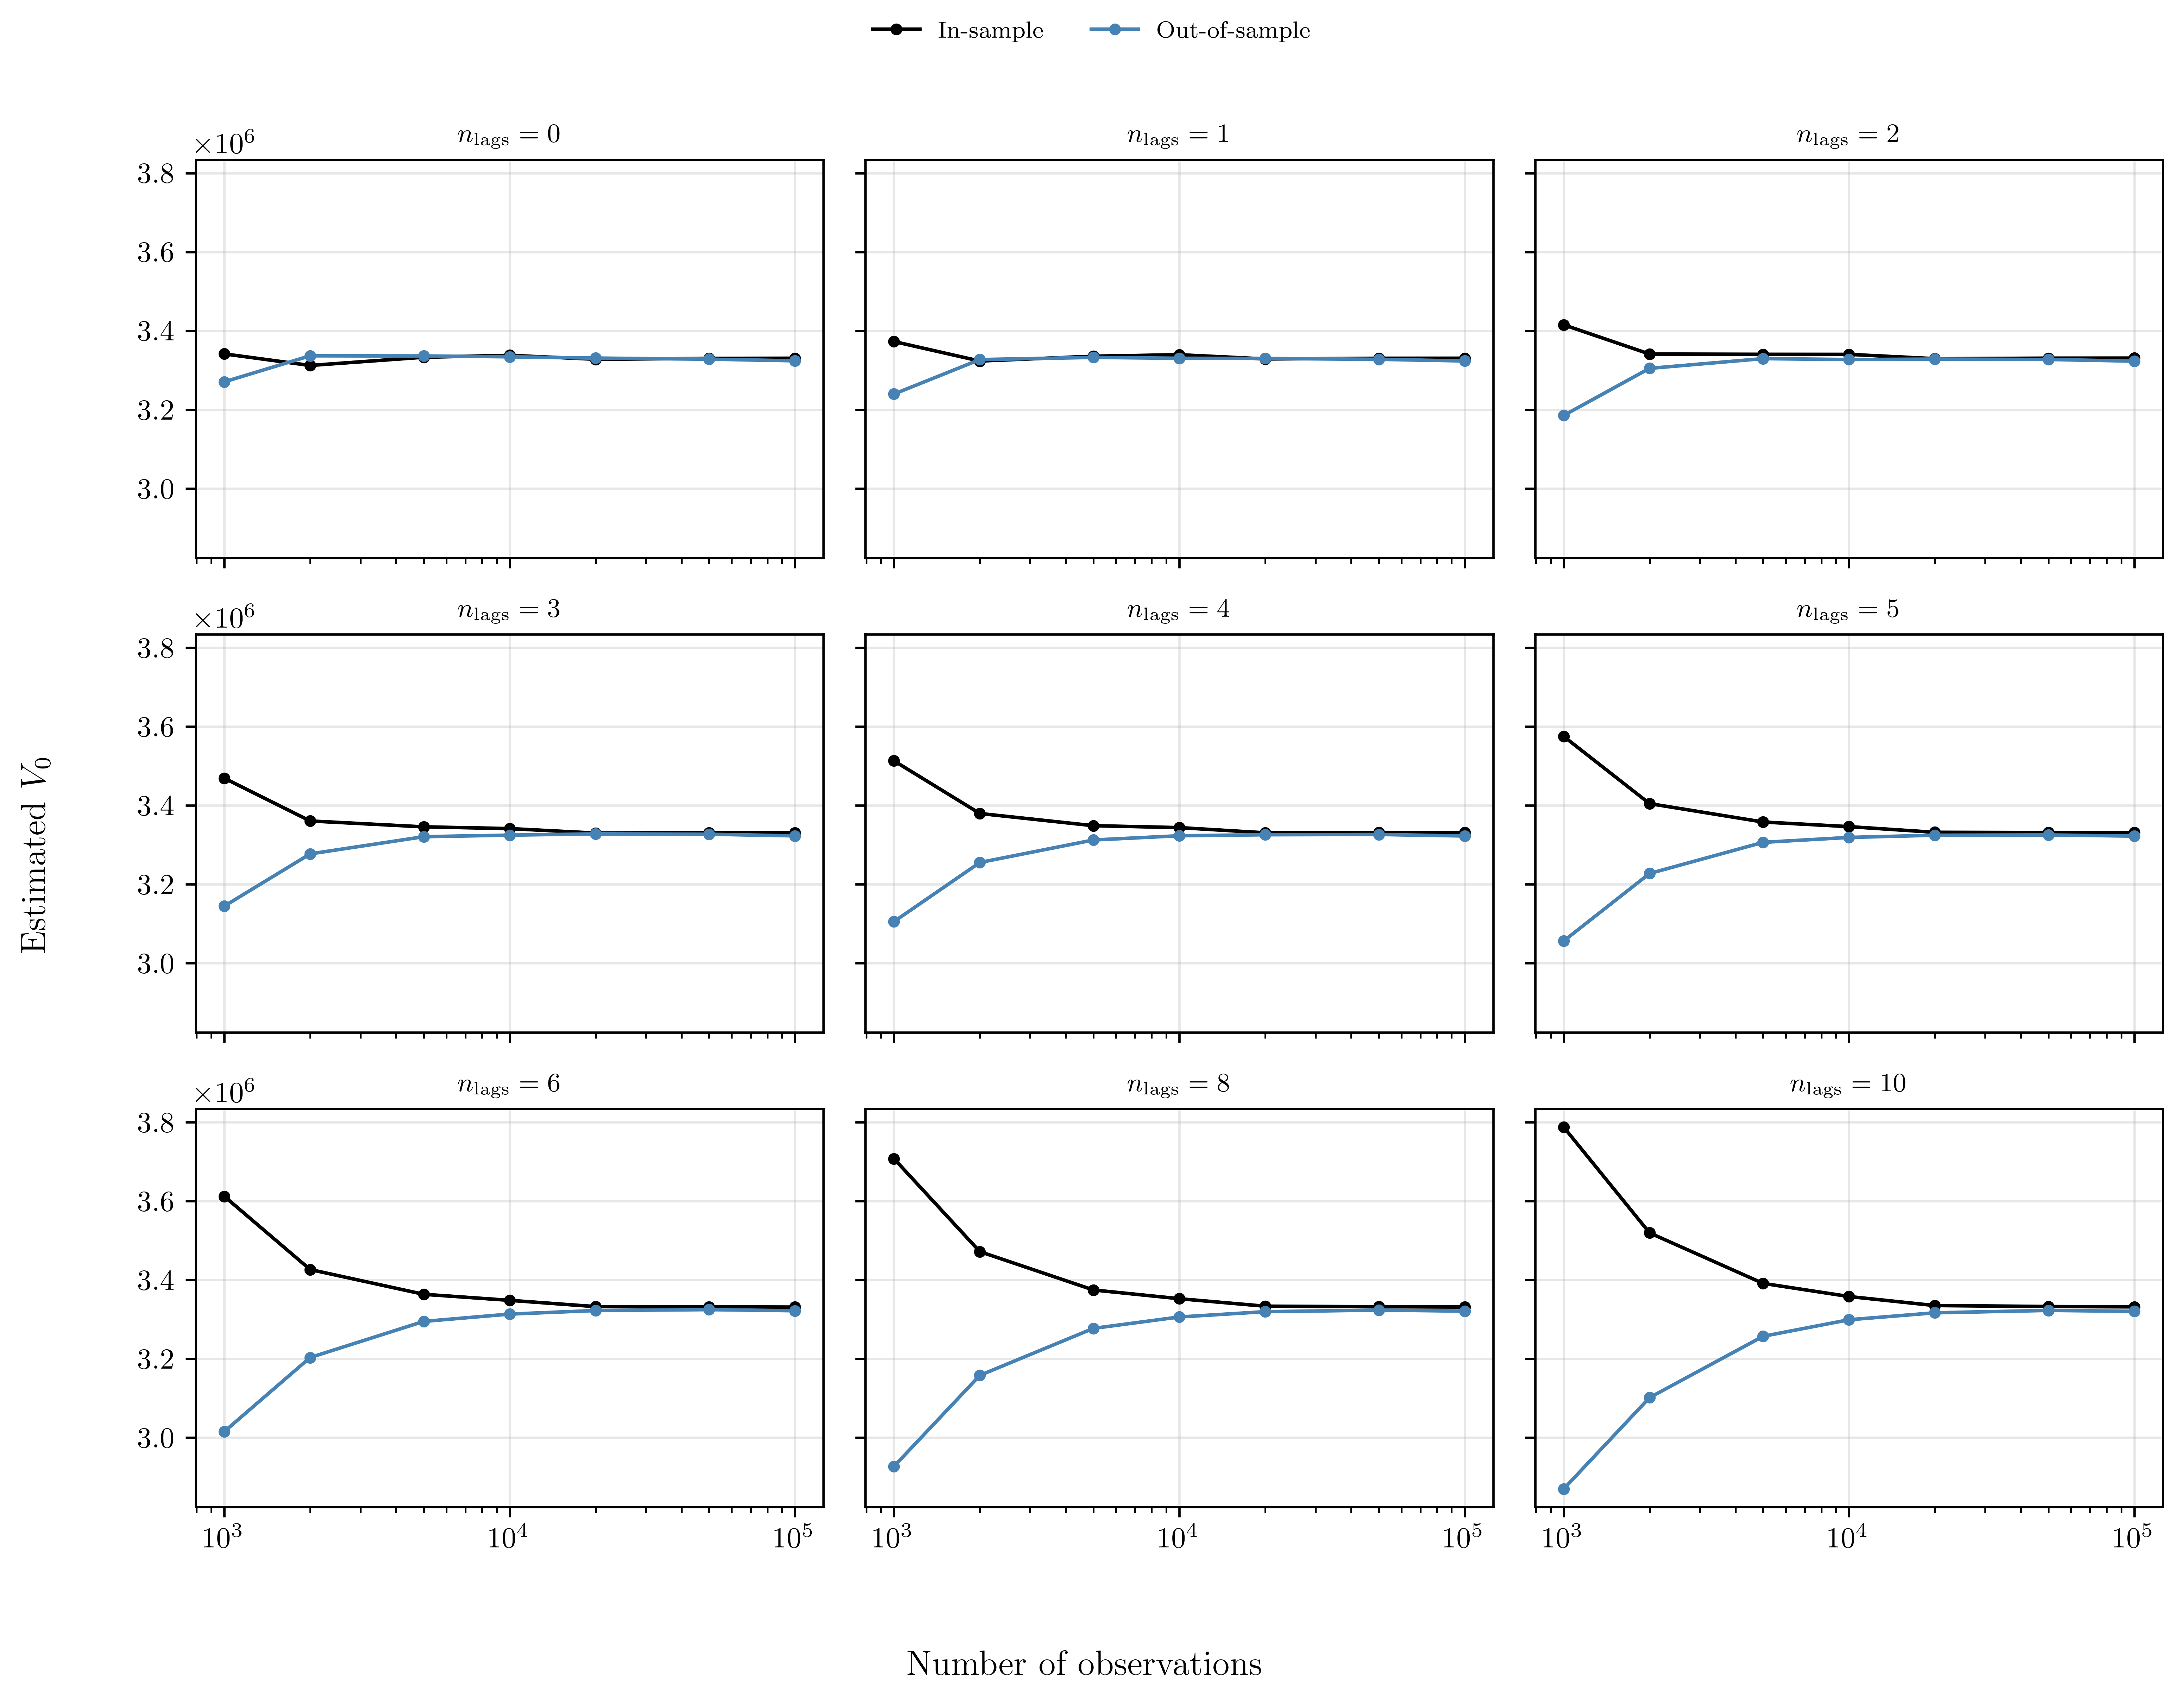

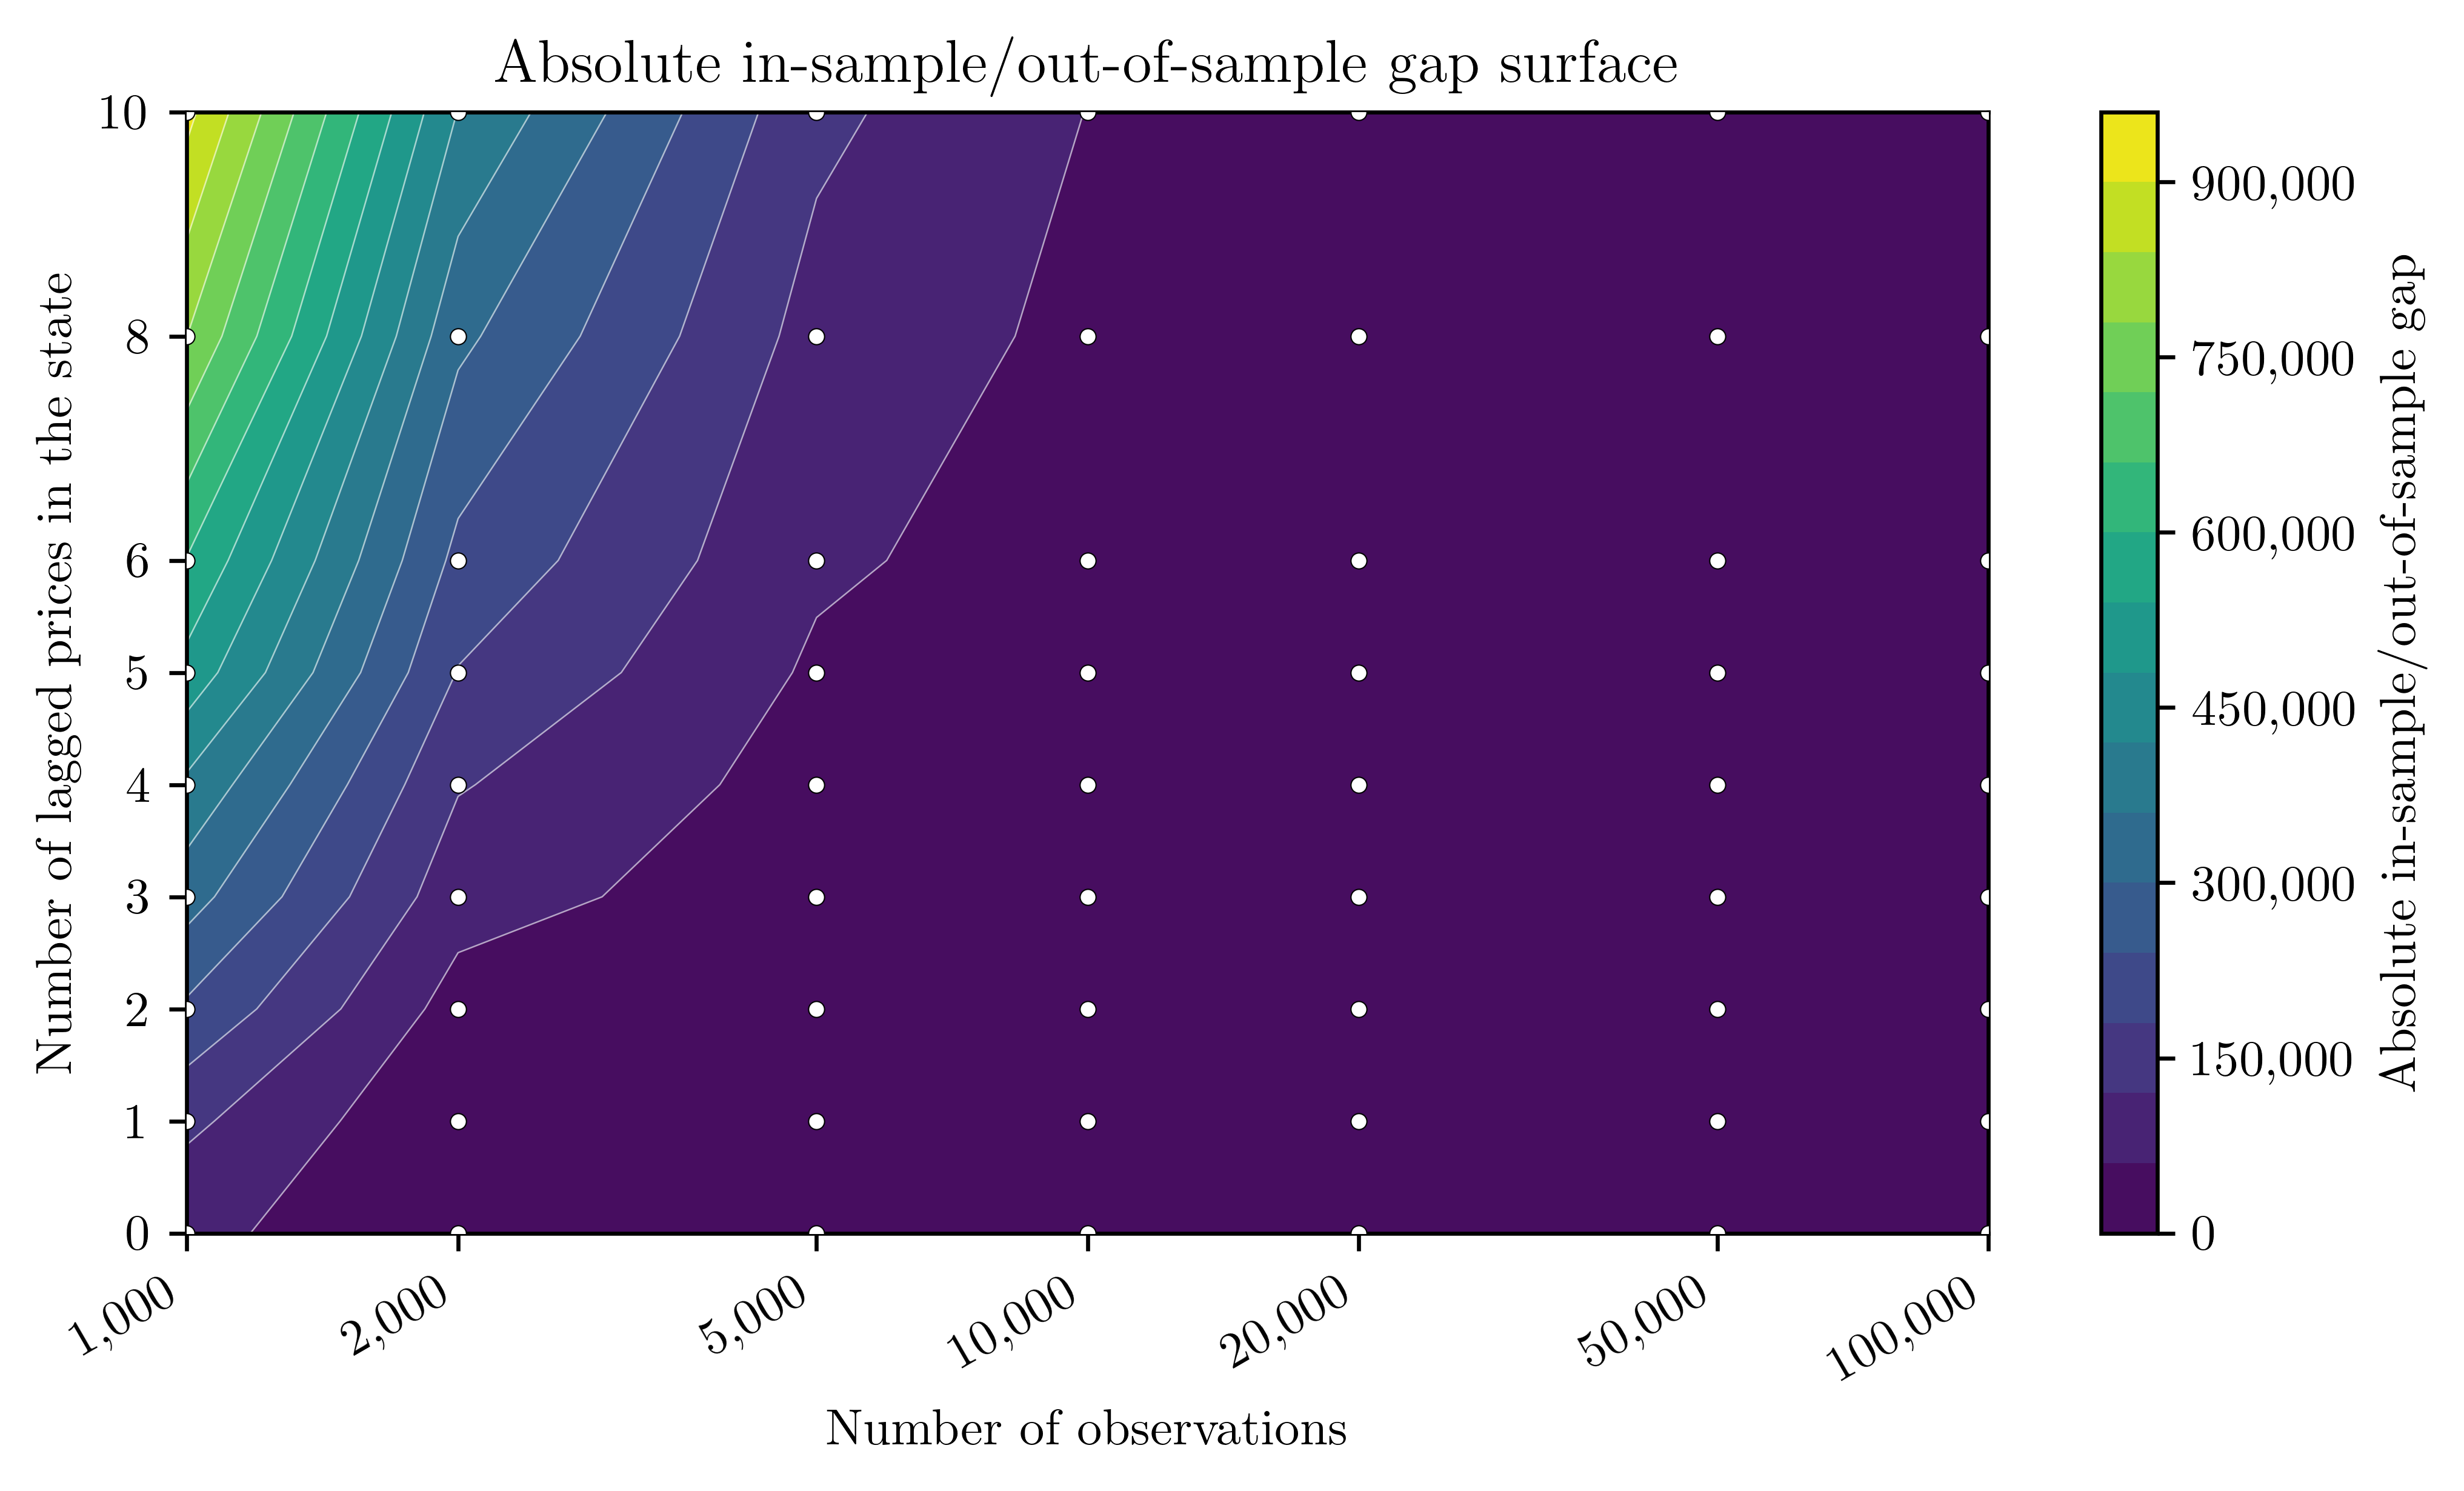

,seed_train,seed_test,n_lags,basis_degree_per_state,n_observations,V0_hat_in_sample,V0_hat_out_of_sample,abs_gap,runtime_in_sample_seconds,runtime_out_of_sample_seconds,runtime_total_seconds
0,234,10234,0,3,1000,3.341640e+06,3.270778e+06,70861.396948,3.971240,2.108972,6.080212
1,234,10234,0,3,2000,3.312297e+06,3.336829e+06,24532.419930,3.506043,3.859727,7.365771
2,234,10234,0,3,5000,3.333159e+06,3.336353e+06,3193.543053,7.884842,9.184548,17.069389
3,234,10234,0,3,10000,3.337948e+06,3.334248e+06,3700.055999,14.438391,16.383365,30.821756
4,234,10234,0,3,20000,3.328078e+06,3.330969e+06,2891.708793,27.398039,32.094425,59.492464
...,...,...,...,...,...,...,...,...,...,...,...
58,234,10234,10,3,5000,3.391387e+06,3.257217e+06,134170.279448,55.458732,7.170098,62.628830
59,234,10234,10,3,10000,3.358068e+06,3.299168e+06,58900.954155,114.964327,14.800240,129.764567
60,234,10234,10,3,20000,3.335176e+06,3.316794e+06,18381.263509,228.731862,28.205275,256.937137
61,234,10234,10,3,50000,3.332752e+06,3.322813e+06,9938.527169,436.168990,60.728345,496.897335


In [ ]:
# -------------------------------------------------
# Lagged-price state analysis
# -------------------------------------------------
import time

lag_degree = 3
n_lag_values = [0, 1, 2, 3, 4, 5, 6, 8, 10]
n_observations_values = [1000, 2000, 5000, 10000, 20000, 50000, 100000]
n_observations_max = max(n_observations_values)
seed = 234

csv_path = "../data/OLS_lagged_price_state_analysis.csv"
fig_path_facets = "../../fig/Plots/OLS_lagged_price_state_observation_facets.png"
fig_path_gap = "../../fig/Plots/OLS_lagged_price_state_observation_gap_surface.png"


def build_lagged_state_basis_matrix(S_paths: np.ndarray, t: int, n_lags: int,
                                    degree: int = 3) -> np.ndarray:
    if n_lags < 0:
        raise ValueError("n_lags must be non-negative")

    M = S_paths.shape[1]
    blocks = [np.ones((M, 1), dtype=np.float64)]

    for lag in range(n_lags + 1):
        s_lag = S_paths[t - lag] if lag <= t else S_paths[0]
        powers = np.empty((M, degree), dtype=np.float64)
        powers[:, 0] = s_lag
        for d in range(1, degree):
            powers[:, d] = powers[:, d - 1] * s_lag
        blocks.append(powers)

    return np.hstack(blocks)


def run_lsmc_backward_with_lags(S: np.ndarray, n_lags: int,
                                degree: int = 3) -> tuple[float, np.ndarray]:
    T = S.shape[0] - 1
    M = S.shape[1]
    p_dim = 1 + (n_lags + 1) * degree

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    tv = terminal_value(v_fine)
    Y_next = np.tile(tv, (M, 1))
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current = np.empty((M, Nf), dtype=np.float64)
    pi_dtype = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T, M), dtype=pi_dtype)
    n_curr = np.full(M, nT_f, dtype=np.int32)
    B_store = np.empty((T, p_dim, Nc), dtype=np.float64)

    for t in range(T - 1, -1, -1):
        X = build_lagged_state_basis_matrix(S, t, n_lags, degree)

        reach_next = all_can_reach[t + 1]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]

        B = np.zeros((p_dim, Nc), dtype=np.float64)
        for j in range(Nc):
            if not reach_next[coarse_fine_idx[j]]:
                continue

            col = Y_disc[:, j]
            mask = np.isfinite(col)
            if mask.sum() >= p_dim:
                B[:, j], *_ = np.linalg.lstsq(X[mask], col[mask], rcond=None)
        B_store[t] = B

        C_hat_coarse = X @ B
        interpolate_coarse_to_fine(
            C_hat_fine_buf,
            C_hat_coarse,
            coarse_fine_idx,
            refine_factor,
        )
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        bellman_update_numba(
            Y_current,
            Y_next,
            pi_next_idx[t],
            n_curr,
            S[t].astype(np.float64, copy=False),
            C_hat_fine_buf,
            all_next_idx[t],
            all_dv_mat[t],
            all_K_len[t],
            disc_arr[t],
            terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    return float(np.mean(Y_next[:, n0_f])), B_store


def lsmc_value_and_B_store_given_S_with_lags(S: np.ndarray, n_lags: int,
                                             degree: int = 3) -> tuple[float, np.ndarray]:
    return run_lsmc_backward_with_lags(S, n_lags=n_lags, degree=degree)


def lsmc_value_given_S_with_lags(S: np.ndarray, n_lags: int,
                                 degree: int = 3) -> float:
    V0_hat, _ = run_lsmc_backward_with_lags(S, n_lags=n_lags, degree=degree)
    return V0_hat


def oos_value_from_B_store_with_lags(S_test: np.ndarray, B_store: np.ndarray,
                                     n_lags: int, degree: int = 3) -> float:
    T = S_test.shape[0] - 1
    M = S_test.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    n_path_idx[0] = n0_f

    for t in range(T):
        X = build_lagged_state_basis_matrix(S_test, t, n_lags, degree)
        C_hat_coarse = X @ B_store[t]
        interpolate_coarse_to_fine(
            C_hat_fine_buf,
            C_hat_coarse,
            coarse_fine_idx,
            refine_factor,
        )
        clamp_infeasible(C_hat_fine_buf, all_can_reach[t + 1], terminal_penalty)

        next_idx = np.empty(M, dtype=np.int32)
        for i in range(M):
            n = n_path_idx[t, i]
            klen = all_K_len[t][n]
            s = S_test[t, i]
            best_val = terminal_penalty
            best_next = n

            for kk in range(klen):
                nxt = all_next_idx[t][n, kk]
                dv = all_dv_mat[t][n, kk]
                cand = (-s * dv) + C_hat_fine_buf[i, nxt]
                if cand > best_val:
                    best_val = cand
                    best_next = nxt

            next_idx[i] = best_next

        n_path_idx[t + 1] = next_idx

    dv_paths = v_fine[n_path_idx[1:]] - v_fine[n_path_idx[:-1]]
    cf = -S_test[:T] * dv_paths

    cum_disc = np.ones(T, dtype=np.float64)
    cum_disc[1:] = np.cumprod(disc_arr[:-1])
    pv = np.sum(cf * cum_disc[:, None], axis=0)

    at_target = (n_path_idx[T] == nT_f)
    n_failed = int(np.sum(~at_target))
    if n_failed > 0:
        print(f"  OOS with lags: {n_failed}/{M} paths did not reach terminal target.")
    pv[~at_target] = np.nan

    return float(np.nanmean(pv))


seed_train = int(seed)
seed_test = int(seed + 10_000)
n_jobs_lagged_state = min(len(n_lag_values), 4)

rng_train = np.random.default_rng(seed_train)
n_half_train = int(np.ceil(n_observations_max / 2))
Z_half_train = rng_train.standard_normal(size=(Tn - 1, n_half_train))
Z_train = np.concatenate([Z_half_train, -Z_half_train], axis=1)[:, :n_observations_max]

rng_test = np.random.default_rng(seed_test)
n_half_test = int(np.ceil(n_observations_max / 2))
Z_half_test = rng_test.standard_normal(size=(Tn - 1, n_half_test))
Z_test = np.concatenate([Z_half_test, -Z_half_test], axis=1)[:, :n_observations_max]

S_train_full = simulate_from_Z(
    Z_train,
    n_paths=n_observations_max,
    Tn=Tn,
    t_arr=t_arr,
    kappa_hat=kappa_hat,
    sigma_hat=sigma_hat,
    m_col=m_col,
)

S_test_full = simulate_from_Z(
    Z_test,
    n_paths=n_observations_max,
    Tn=Tn,
    t_arr=t_arr,
    kappa_hat=kappa_hat,
    sigma_hat=sigma_hat,
    m_col=m_col,
)

def evaluate_n_lags(n_lags: int) -> list[dict]:
    records_local = []

    for n_observations in n_observations_values:
        S_train = S_train_full[:, :n_observations]
        S_test = S_test_full[:, :n_observations]

        t0 = time.perf_counter()
        V0_hat_in_sample, B_store = lsmc_value_and_B_store_given_S_with_lags(
            S_train,
            n_lags=n_lags,
            degree=lag_degree,
        )
        runtime_in_sample_seconds = time.perf_counter() - t0

        t1 = time.perf_counter()
        V0_hat_out_of_sample = oos_value_from_B_store_with_lags(
            S_test,
            B_store,
            n_lags=n_lags,
            degree=lag_degree,
        )
        runtime_out_of_sample_seconds = time.perf_counter() - t1

        records_local.append({
            "seed_train": seed_train,
            "seed_test": seed_test,
            "n_lags": int(n_lags),
            "basis_degree_per_state": int(lag_degree),
            "n_observations": int(n_observations),
            "V0_hat_in_sample": V0_hat_in_sample,
            "V0_hat_out_of_sample": V0_hat_out_of_sample,
            "abs_gap": abs(V0_hat_in_sample - V0_hat_out_of_sample),
            "runtime_in_sample_seconds": runtime_in_sample_seconds,
            "runtime_out_of_sample_seconds": runtime_out_of_sample_seconds,
            "runtime_total_seconds": runtime_in_sample_seconds + runtime_out_of_sample_seconds,
        })

    return records_local

try:
    from joblib import Parallel, delayed

    records_nested = Parallel(n_jobs=n_jobs_lagged_state, backend="loky")(
        delayed(evaluate_n_lags)(n_lags)
        for n_lags in tqdm(n_lag_values, desc="Lagged-state analysis")
    )
    records = [record for lag_records in records_nested for record in lag_records]
    parallel_mode = f"joblib loky, n_jobs={n_jobs_lagged_state}"
except ImportError:
    print("joblib not available; running lagged-state analysis sequentially.")
    records_nested = [
        evaluate_n_lags(n_lags)
        for n_lags in tqdm(n_lag_values, desc="Lagged-state analysis")
    ]
    records = [record for lag_records in records_nested for record in lag_records]
    parallel_mode = "sequential fallback"

lagged_state_results_df = pd.DataFrame(records)
lagged_state_results_df = lagged_state_results_df.sort_values(["n_lags", "n_observations"]).reset_index(drop=True)
# lagged_state_results_df.to_csv(csv_path, index=False)
print(f"Parallel mode: {parallel_mode}")

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

n_cols = 3
n_rows = int(np.ceil(len(n_lag_values) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10.5, 8.0), dpi=600, sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, n_lags in zip(axes, n_lag_values):
    df_plot = lagged_state_results_df.loc[
        lagged_state_results_df["n_lags"] == n_lags
    ].sort_values("n_observations")

    ax.plot(
        df_plot["n_observations"].to_numpy(dtype=np.float64),
        df_plot["V0_hat_in_sample"].to_numpy(dtype=np.float64),
        linewidth=1.2,
        color="black",
        marker="o",
        markersize=3.0,
        label="In-sample",
    )
    ax.plot(
        df_plot["n_observations"].to_numpy(dtype=np.float64),
        df_plot["V0_hat_out_of_sample"].to_numpy(dtype=np.float64),
        linewidth=1.2,
        color="steelblue",
        marker="o",
        markersize=3.0,
        label="Out-of-sample",
    )
    ax.set_xscale("log")
    ax.set_title(rf"$n_{{\mathrm{{lags}}}}={n_lags}$", fontsize=9)
    ax.grid(True, alpha=0.3)

for ax in axes[len(n_lag_values):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, fontsize=8)
fig.supxlabel("Number of observations")
fig.supylabel(r"Estimated $V_0$")
fig.tight_layout(rect=(0.03, 0.03, 1.0, 0.95))
plt.savefig(fig_path_facets)
plt.show()

gap_surface_df = (
    lagged_state_results_df
    .pivot(index="n_lags", columns="n_observations", values="abs_gap")
    .reindex(index=n_lag_values, columns=n_observations_values)
)

x_log = np.log10(np.asarray(n_observations_values, dtype=np.float64))
y_lags = np.asarray(n_lag_values, dtype=np.float64)
X, Y = np.meshgrid(x_log, y_lags)
Z_gap = gap_surface_df.to_numpy(dtype=np.float64)

fig, ax = plt.subplots(figsize=(7.0, 4.2), dpi=600)
max_gap = float(np.nanmax(Z_gap))
contour_levels = mpl.ticker.MaxNLocator(nbins=16).tick_values(0.0, max_gap if max_gap > 0.0 else 1.0)
cbar_ticks = mpl.ticker.MaxNLocator(nbins=7).tick_values(0.0, max_gap if max_gap > 0.0 else 1.0)
contour = ax.contourf(X, Y, Z_gap, levels=contour_levels, cmap="viridis", vmin=0.0)
ax.contour(X, Y, Z_gap, levels=contour_levels, colors="white", linewidths=0.3, alpha=0.6)
ax.scatter(X.ravel(), Y.ravel(), color="white", edgecolor="black", s=10, linewidth=0.25, zorder=3)

cbar = fig.colorbar(contour, ax=ax, ticks=cbar_ticks)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
cbar.set_label(r"Absolute in-sample/out-of-sample gap")

ax.set_xticks(x_log)
ax.set_xticklabels([f"{n:,}" for n in n_observations_values], rotation=30, ha="right")
ax.set_yticks(n_lag_values)
ax.set_xlabel("Number of observations")
ax.set_ylabel("Number of lagged prices in the state")
ax.set_title("Absolute in-sample/out-of-sample gap surface")

fig.tight_layout()
plt.savefig(fig_path_gap)
plt.show()

display(lagged_state_results_df)


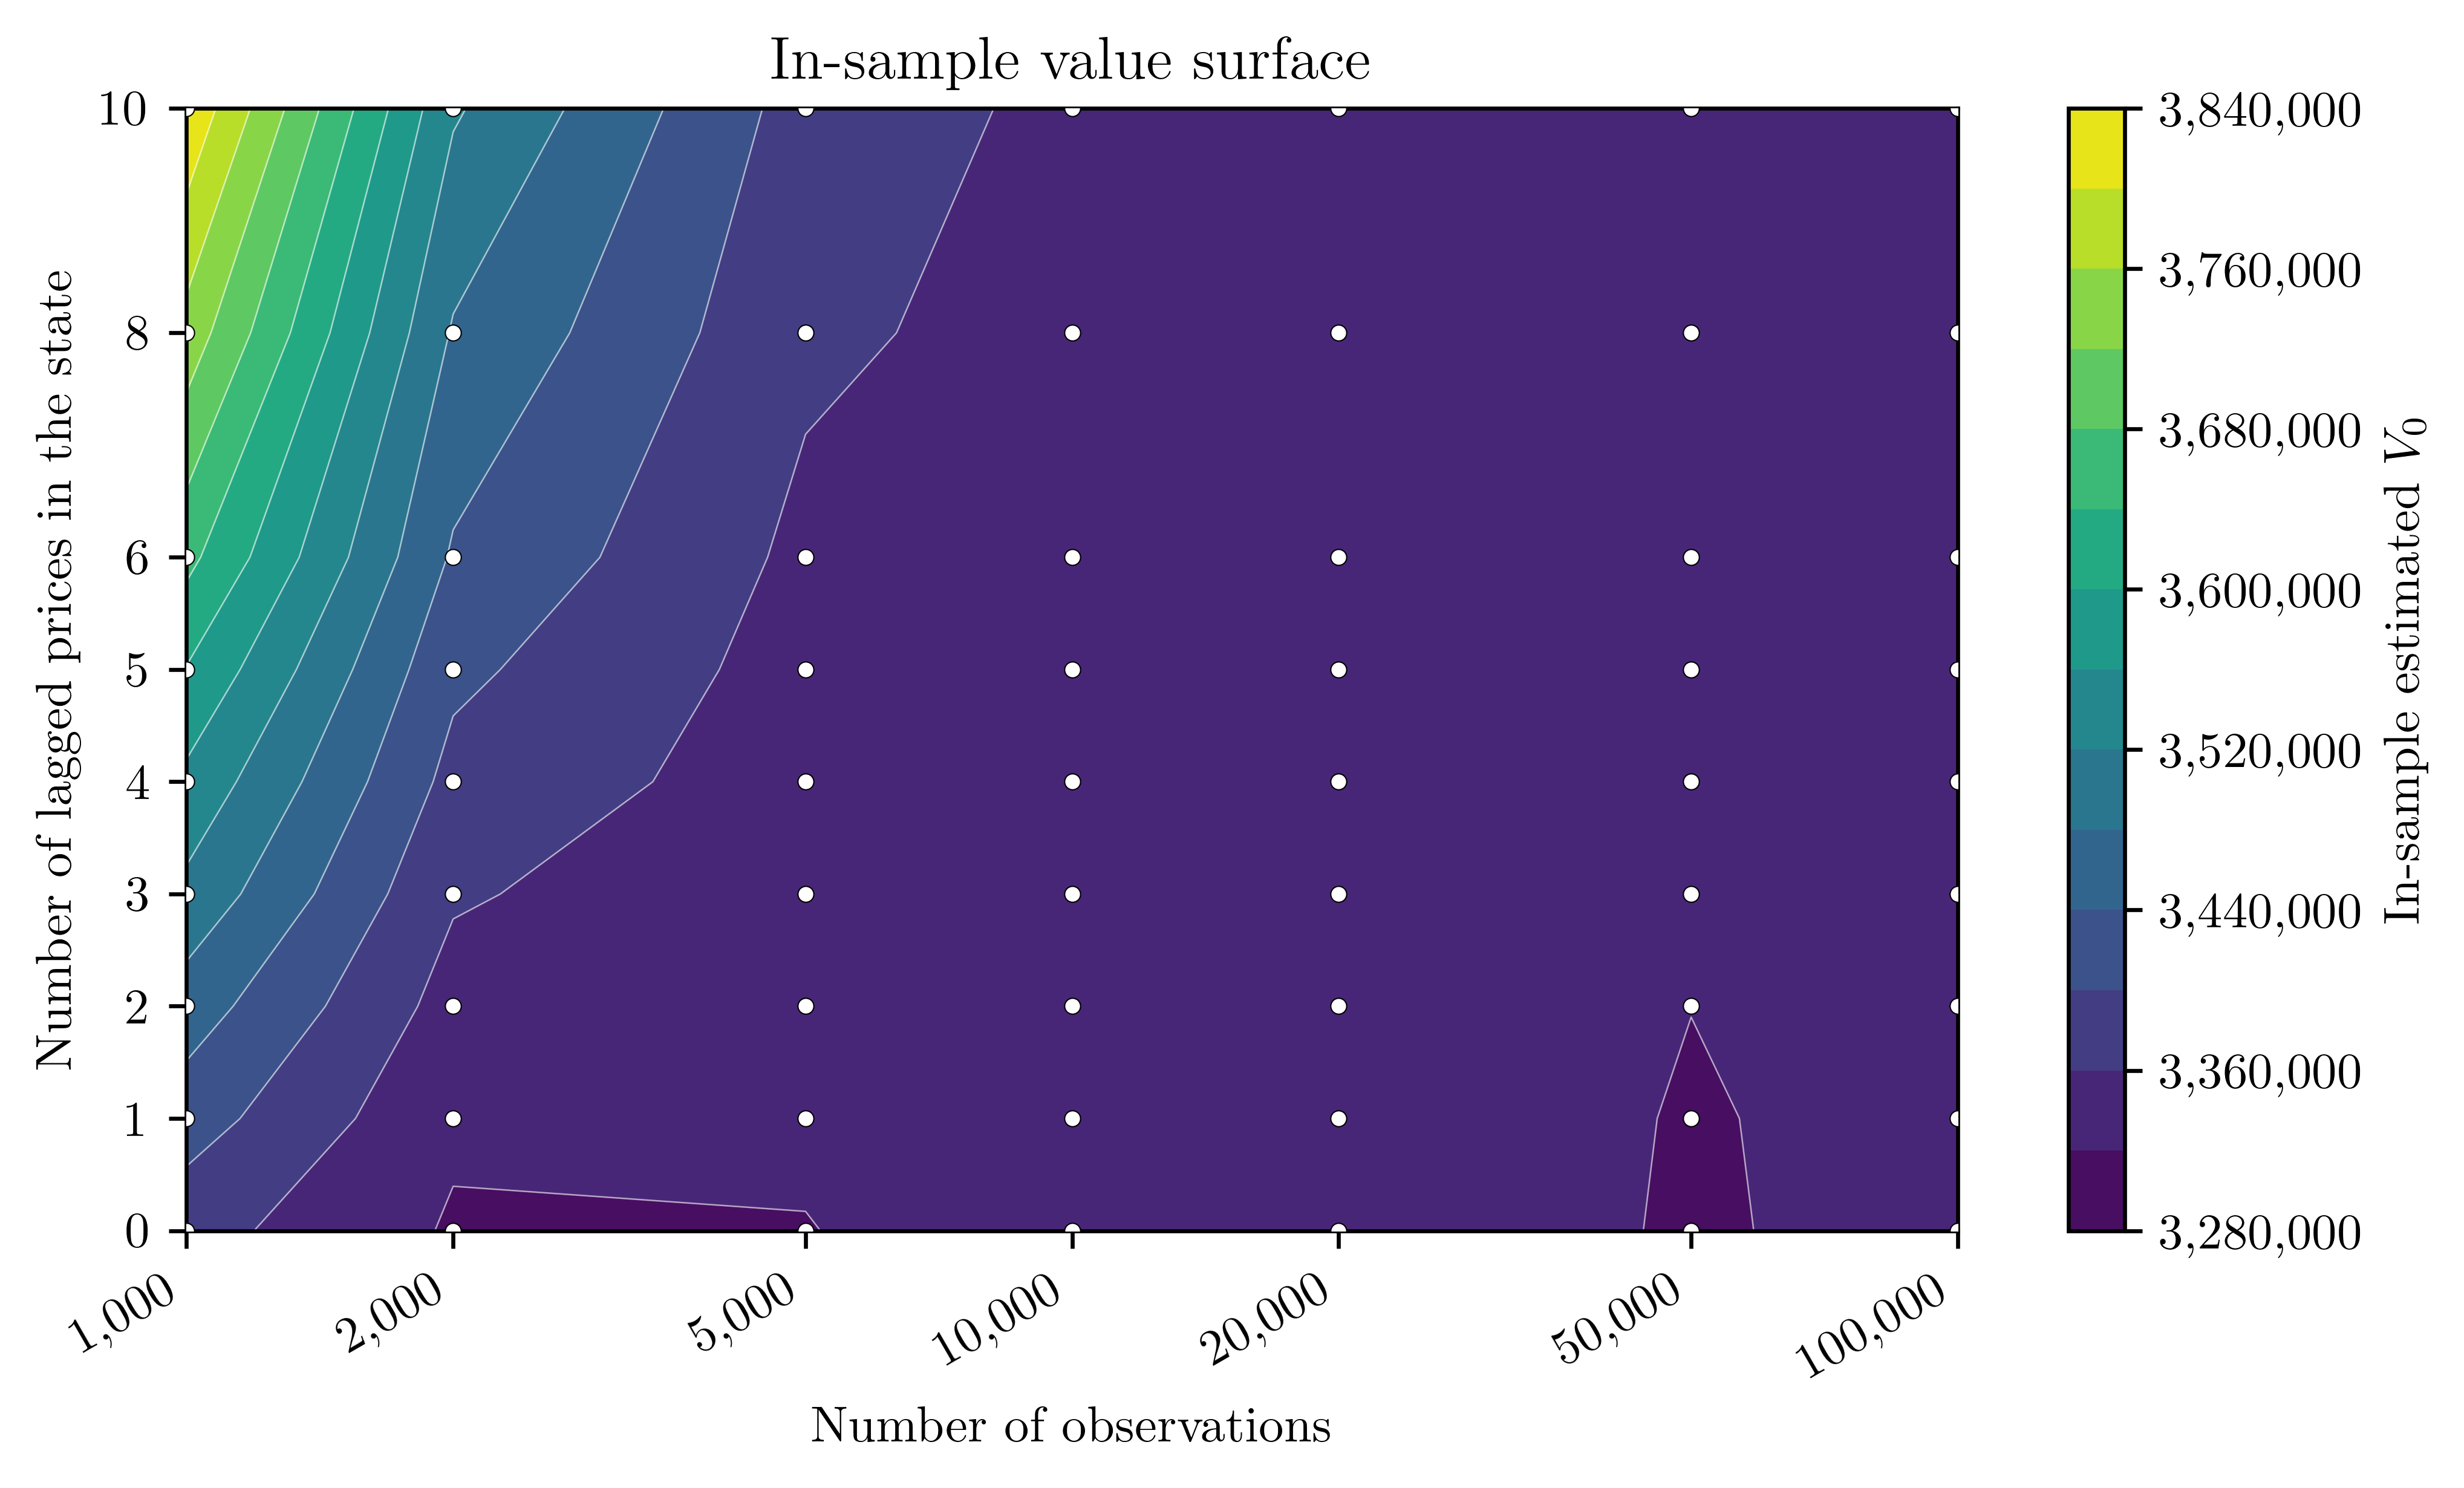

In [7]:
csv_path = "../data/OLS_lagged_price_state_analysis.csv"
fig_path_in_sample_surface = "../../fig/Plots/OLS_lagged_price_state_observation_in_sample_surface.png"

lagged_state_results_df = pd.read_csv(csv_path)
n_lag_values = sorted(lagged_state_results_df["n_lags"].unique().tolist())
n_observations_values = sorted(lagged_state_results_df["n_observations"].unique().tolist())

in_sample_surface_df = (
    lagged_state_results_df
    .pivot(index="n_lags", columns="n_observations", values="V0_hat_in_sample")
    .reindex(index=n_lag_values, columns=n_observations_values)
)

x_log = np.log10(np.asarray(n_observations_values, dtype=np.float64))
y_lags = np.asarray(n_lag_values, dtype=np.float64)
X, Y = np.meshgrid(x_log, y_lags)

Z_in_sample = in_sample_surface_df.to_numpy(dtype=np.float64)

fig, ax = plt.subplots(figsize=(7.0, 4.2), dpi=600)
vmin = float(np.nanmin(Z_in_sample))
vmax = float(np.nanmax(Z_in_sample))
if np.isclose(vmin, vmax):
    vmax = vmin + 1.0
contour_levels = mpl.ticker.MaxNLocator(nbins=16).tick_values(vmin, vmax)
cbar_ticks = mpl.ticker.MaxNLocator(nbins=7).tick_values(vmin, vmax)
contour = ax.contourf(X, Y, Z_in_sample, levels=contour_levels, cmap="viridis")
ax.contour(X, Y, Z_in_sample, levels=contour_levels, colors="white", linewidths=0.3, alpha=0.6)
ax.scatter(X.ravel(), Y.ravel(), color="white", edgecolor="black", s=10, linewidth=0.25, zorder=3)

cbar = fig.colorbar(contour, ax=ax, ticks=cbar_ticks)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
cbar.set_label(r"In-sample estimated $V_0$")

ax.set_xticks(x_log)
ax.set_xticklabels([f"{n:,}" for n in n_observations_values], rotation=30, ha="right")
ax.set_yticks(n_lag_values)
ax.set_xlabel("Number of observations")
ax.set_ylabel("Number of lagged prices in the state")
ax.set_title("In-sample value surface")

fig.tight_layout()
plt.savefig(fig_path_in_sample_surface)
plt.show()
